In [ ]:
%matplotlib inline

import os

import pandas as pd

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value

import scipy.stats as st
from scipy.optimize import minimize

### Read the light curve fitting and quasar parameters

In [149]:
import h5py
def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
    d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
    d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
    d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
    d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
    d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
    d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
    d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
    d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
    d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
    d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    return d

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'z': 9134,  # SDSS z-band
        'u': 3543,  # SDSS u-band
        'y': 9633,  # PS1 y-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['i']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

def split_field_by_band(q, keys):
    bands = q['filtered_bands']
    for key in keys:
        for i, b in enumerate(bands):
            q[f'{key}_{b}'] = q[key][i]

def split_field_by_band(q, keys):
    for key in keys:
        for i in range(len(q[key])):
            q[f'{key}_{i}'] = q[key][i]

#def split_field_by_band(q, keys):
#    bands = q['mags'].keys()
#    print(bands)
#    print('a')
#    for key in keys:
#        for i, b in enumerate(bands):
#            q[f'{key}_{b}'] = q[key][i]

#quasar_list = read_quasars_from_hdf5("data/s82_objects_ids_test_fitted.h5")
quasar_list = read_quasars_from_hdf5("data/s82/quasars_fit_test.h5")

print("Number of quasars loaded:", len(quasar_list))

for q in quasar_list:
    split_field_by_band(q, ['log_sigma_band', 'log_sigma_band_err', 'log_jitter', 'magerrs_mean'])
    populate_sdss_fields(q)
    calc_lam_RF(q)
    q['delta_time'] = q['times']['r'].max() - q['times']['r'].min()

df = pd.DataFrame(quasar_list)
df = df.set_index('object_id')
df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err', 'filtered_bands'])

df_all = df.copy()

# Remove infinite values from numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
#df = df.dropna()

#for i, band in enumerate(['g', 'r', 'i']):
#    df = df[(10**df[f'log_sigma_band_{band}']) > 1.*np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2)]


# data cuts
df = df[df['log_sigma_RF'] < 0]
df = df[df['log_tau_RF'] > 0.5]
df = df[df['log_lbol'] > 44]
df = df[df['beta'] > -1]
df = df[df['beta'] < 0]
#df = df[df['delta_time'] > 6000]

#df = df[df['delta_time']/(1+df['z']) < 3200]


print("Number of quasars after cuts:", len(df))

df.head()

Number of quasars loaded: 545
Number of quasars after cuts: 527


,beta,beta_err,dec,i,log_amp_delta,log_amp_delta_err,log_lbol,log_lbol_err,log_ledd_ratio,log_ledd_ratio_err,...,apparent_mag_g,apparent_mag_u,apparent_mag_z_err,apparent_mag_i_err,apparent_mag_r_err,apparent_mag_g_err,apparent_mag_u_err,color,log_lambda_RF,delta_time
object_id,,,,,,,,,,,,,,,,,,,,,
1429814,-0.666793,0.069982,0.206758,44,"[-0.0, -0.1982859095836773, -0.376446703692812...","[0.0, 0.020810647710949273, 0.0395091095930505...",45.795265,0.005025,-1.008643,0.109578,...,20.070103,20.152726,0.073611,0.025812,0.021827,0.020447,0.039750,0.402110,3.492954,8045.892259
1429839,-0.725624,0.057907,0.270032,43,"[-0.0, -0.21578058445534107, -0.40966042372689...","[0.0, 0.017219966776218676, 0.0326921854619814...",46.184609,0.006615,-0.542571,0.161958,...,19.745053,19.861239,0.075779,0.025275,0.017486,0.019136,0.038402,0.094634,3.492717,8045.892260
1429841,-0.593296,0.114153,-0.356900,42,"[-0.0, -0.17642982440934296, -0.33495282630746...","[0.0, 0.03394587215785455, 0.06444639311301767...",45.622645,0.006481,-0.964634,0.081577,...,20.990224,21.568502,0.089183,0.034194,0.035537,0.030127,0.087833,1.275408,3.523064,7713.972039
1429843,-0.698234,0.069002,-0.010110,41,"[-0.0, -0.20763556518504808, -0.39419706749419...","[0.0, 0.020519147180516867, 0.0389556945065404...",46.336920,0.002530,-0.800768,0.074422,...,19.393699,19.914188,0.042964,0.024822,0.013325,0.021380,0.033925,0.863050,3.476139,8045.892254
1429882,-0.386104,0.070849,0.238306,40,"[-0.0, -0.11481679676370793, -0.21798021231571...","[0.0, 0.02106861716074932, 0.03999886577005059...",45.683424,0.011856,-1.296608,0.052281,...,20.311635,20.440896,0.116096,0.032012,0.027582,0.026870,0.050612,0.375627,3.548906,8045.892259


### Fit the spectral index and interpolated mag_i

We end up not using this in the final analysis, because it didn't make much difference. The scatter on these terms do not contribute that much to the final scatter on the Hubble diagram. The code is here possible for future use, if it ever becomes important.

In [152]:
from scipy.stats import linregress
import numpy as np

import matplotlib.pyplot as plt

# Iterate over each source in the quasar list
for source_id, source in df.iterrows():

    u = 10**(-0.4 * source['apparent_mag_u'])
    g = 10**(-0.4 * source['apparent_mag_g'])  # Assuming 'fluxes' is a key in the source dictionary
    r = 10**(-0.4 * source['apparent_mag_r'])
    i = 10**(-0.4 * source['apparent_mag_i'])
    z = 10**(-0.4 * source['apparent_mag_z'])
    # Convert magnitudes to flux using the formula: flux = 10^(-0.4 * magnitude)
    fluxes = np.array([u, g, r, i, z])
    # Filter out NaN fluxes and corresponding wavelengths

    # Calculate the flux errors using the magnitude errors
    u_err = 0.4 * np.log(10) * source['apparent_mag_u_err'] * u
    g_err = 0.4 * np.log(10) * source['apparent_mag_g_err'] * g
    r_err = 0.4 * np.log(10) * source['apparent_mag_r_err'] * r
    i_err = 0.4 * np.log(10) * source['apparent_mag_i_err'] * i
    z_err = 0.4 * np.log(10) * source['apparent_mag_z_err'] * z

    # Define the wavelengths corresponding to the bands (in Angstroms)
    wavelengths = np.array([3543, 4770, 6231, 7625, 9134])  # u, g, r, i, z bands

    # Drop bands that cross the Lyman-alpha forest
    lyman_alpha_wavelength = 912.0  # Lyman-alpha wavelength in Angstroms
    valid_indices = (wavelengths - 500) / (1 + source['z']) > lyman_alpha_wavelength
    fluxes = fluxes[valid_indices]
    wavelengths = wavelengths[valid_indices]

    print(wavelengths)

    valid_indices = ~np.isnan(fluxes)
    fluxes = fluxes[valid_indices]
    wavelengths = wavelengths[valid_indices]

    if len(fluxes) < 2:
        print(f"Not enough valid fluxes for source {source_id}. Skipping.")
        continue

    # Combine the flux errors into an array
    flux_errors = np.array([u_err, g_err, r_err, i_err, z_err])

    # Fit a line to the fluxes vs log10 wavelengths
    slope, intercept, r_value, p_value, std_err = linregress(np.log10(wavelengths), np.log10(fluxes))

    # Interpolate the i band magnitude at the rest-frame wavelength
    rest_frame_wavelength = 7625  # Rest-frame wavelength for the i band
    interpolated_flux = 10**(slope * np.log10(rest_frame_wavelength) + intercept)
    interpolated_mag_i = -2.5 * np.log10(interpolated_flux)

    # Add the interpolated i band magnitude to the dataframe
    df.at[source_id, 'interpolated_mag_i'] = interpolated_mag_i
    df.at[source_id, 'alpha_nu'] = slope

    print(slope, intercept, r_value, p_value, std_err)

    # Plot the data and the fitted line
    """
    plt.figure(figsize=(8, 6))
    plt.errorbar(np.log10(wavelengths), np.log10(fluxes), yerr=0, label='Data', marker='o', color='blue', alpha=0.6, linestyle='None')
    plt.plot(np.log10(wavelengths), slope * np.log10(wavelengths) + intercept, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
    plt.xlabel(r'$\log_{10}(\mathrm{Wavelength})$')
    plt.ylabel('log Flux')
    plt.legend()
    plt.grid(True)
    plt.show()
    """

[3543 4770 6231 7625 9134]
0.40455803116162264 -9.503124900709757 0.9567529938873539 0.010725817867358736 0.07101766633539495
[3543 4770 6231 7625 9134]
0.07987473238489255 -8.21094784075138 0.6513387255888411 0.2337804697037941 0.05372319440474344
[3543 4770 6231 7625 9134]
1.3940661659677906 -13.53861501587405 0.9813181811284774 0.0030566226705045054 0.1577973136006412
[3543 4770 6231 7625 9134]
0.8315694596966304 -10.868919321308365 0.949887074092692 0.013364931530692263 0.15799579774592484
[3543 4770 6231 7625 9134]
0.296072796369937 -9.20914195466007 0.8041723417053609 0.1009154529883468 0.12634695267952614
[3543 4770 6231 7625 9134]
1.1891097820592909 -12.968383522933312 0.9738085811982736 0.0050682588788608825 0.16029491888936295
[4770 6231 7625 9134]
0.34332170748469687 -9.591850482658396 0.4863610702514571 0.5136389297485429 0.43613263737262564
[3543 4770 6231 7625 9134]
1.1169267818810746 -12.54542564649917 0.9016346967240738 0.036482353244265575 0.309327103888422
[4770 6231 

<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_29451/1123305705.py:62: SyntaxWarning: invalid escape sequence '\l'
  """


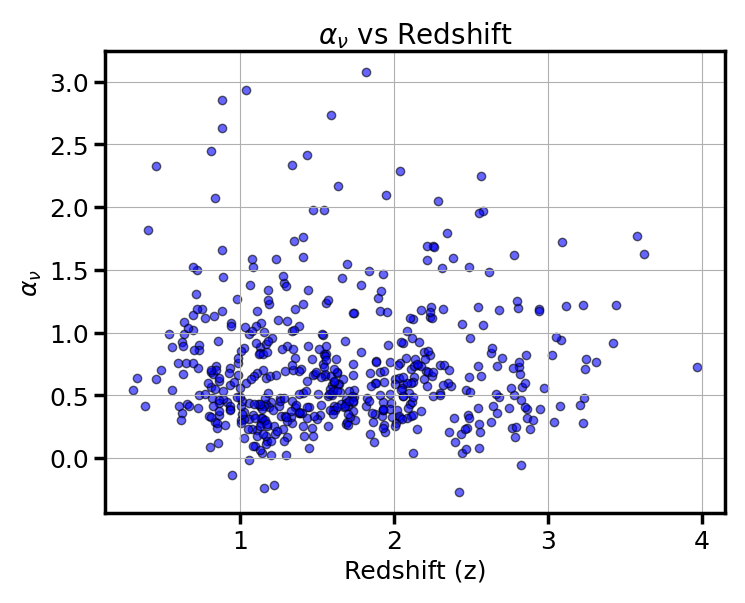

In [155]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['alpha_nu'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel(r'$\alpha_\nu$')
plt.title(r'$\alpha_\nu$ vs Redshift')
plt.grid(True)
plt.show()

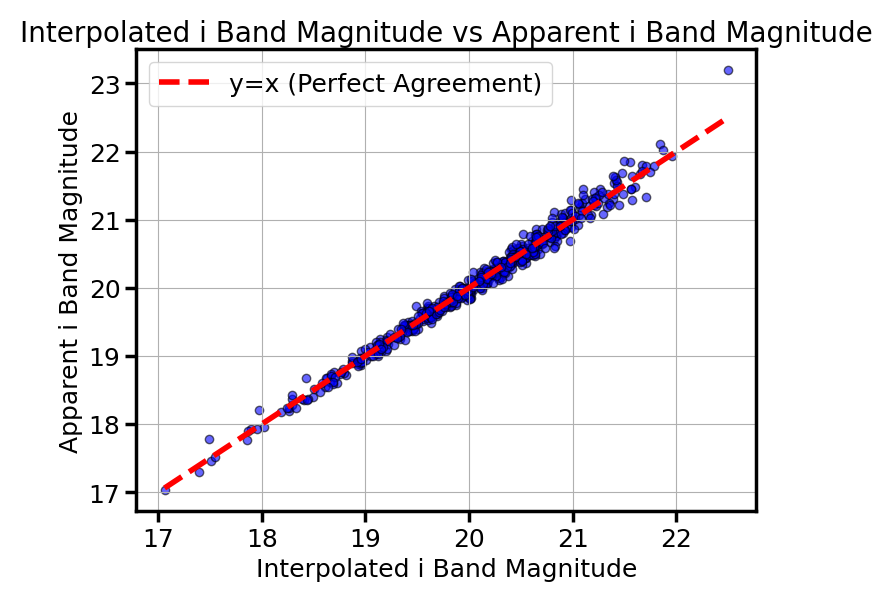

In [156]:
plt.figure(figsize=(8, 6))
plt.scatter(df['interpolated_mag_i'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Interpolated i Band Magnitude')
plt.ylabel('Apparent i Band Magnitude')
plt.title('Interpolated i Band Magnitude vs Apparent i Band Magnitude')
plt.plot([df['interpolated_mag_i'].min(), df['interpolated_mag_i'].max()],
         [df['interpolated_mag_i'].min(), df['interpolated_mag_i'].max()],
         'r--', label='y=x (Perfect Agreement)')
plt.legend()
plt.grid(True)
plt.show()

In [1146]:
#df['object_id'].to_csv('data/object_ids_test.csv', index=False)

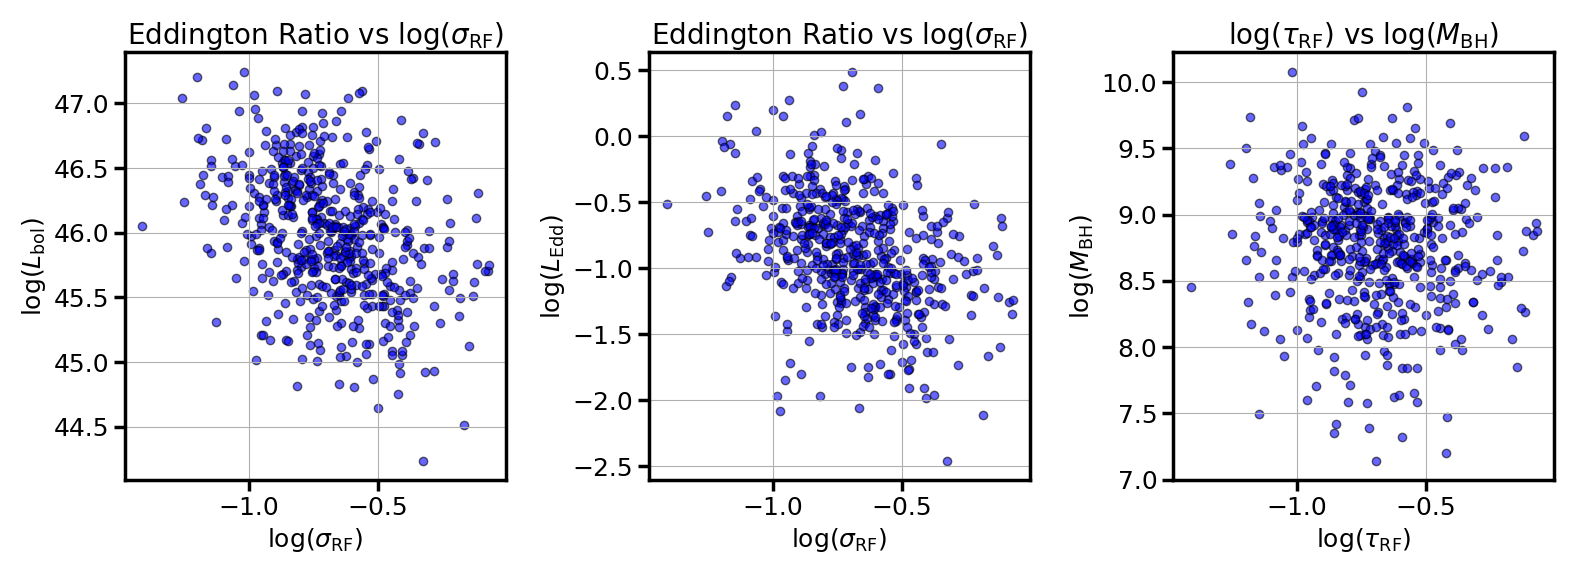

In [1147]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

# Define the redshift range
redshift_min, redshift_max = 0.8, 1.5

# Apply the mask to filter the dataframe

# Plot Eddington ratio vs sigma
axs[0].scatter(df['log_sigma_RF'], df['log_lbol'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[0].set_ylabel(r"$\log(L_\mathrm{bol})$")
axs[0].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[0].grid(True)

# Plot Eddington ratio vs sigma
axs[1].scatter(df['log_sigma_RF'], df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[1].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[1].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[1].grid(True)

# Plot tau vs BH mass
axs[2].scatter(df['log_sigma_RF'], df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[2].set_xlabel(r"$\log(\tau_\mathrm{RF})$")
axs[2].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[2].set_title(r"$\log(\tau_\mathrm{RF})$ vs $\log(M_\mathrm{BH})$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

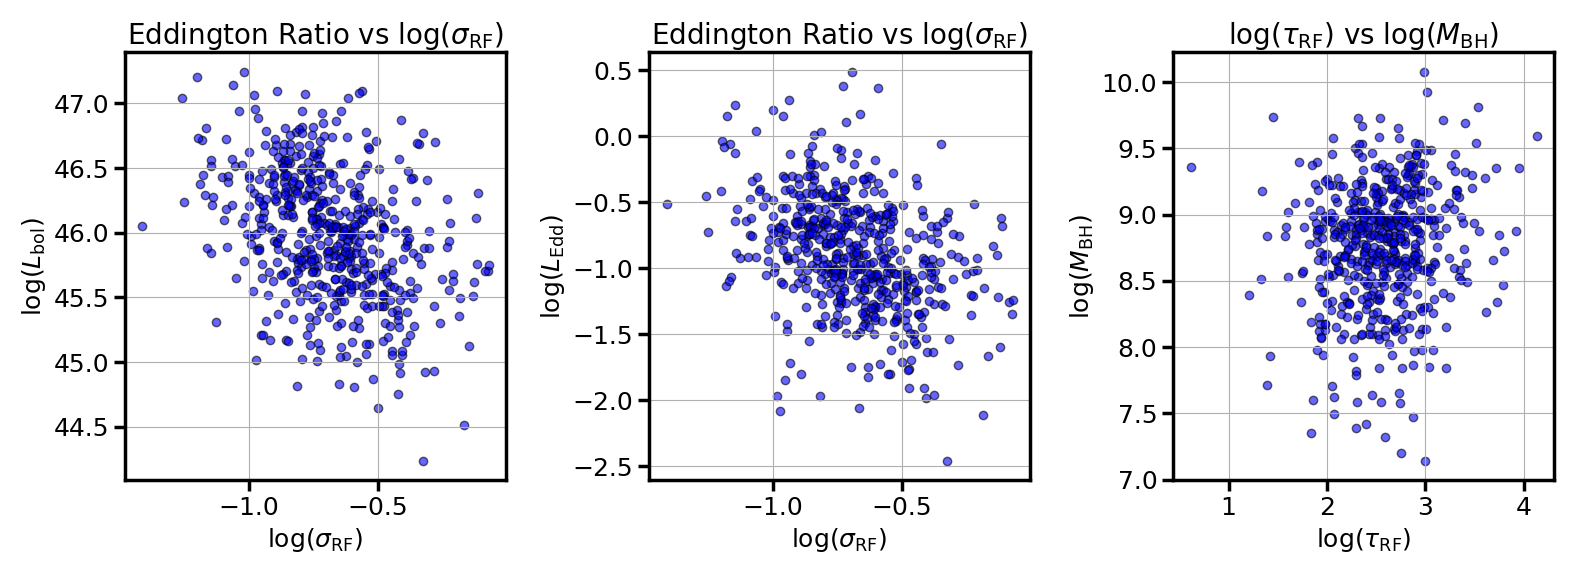

In [1149]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

# Define the redshift range
redshift_min, redshift_max = 0.8, 1.5

# Apply the mask to filter the dataframe
#mask = (df['z'] >= redshift_min) & (df['z'] <= redshift_max)
filtered_df = df #[mask]


# Plot Eddington ratio vs sigma
axs[0].scatter(filtered_df['log_sigma_RF'], filtered_df['log_lbol'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[0].set_ylabel(r"$\log(L_\mathrm{bol})$")
axs[0].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[0].grid(True)

# Plot Eddington ratio vs sigma
axs[1].scatter(filtered_df['log_sigma_RF'], filtered_df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[1].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[1].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[1].grid(True)

# Plot tau vs BH mass
axs[2].scatter(filtered_df['log_tau_RF'], filtered_df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[2].set_xlabel(r"$\log(\tau_\mathrm{RF})$")
axs[2].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[2].set_title(r"$\log(\tau_\mathrm{RF})$ vs $\log(M_\mathrm{BH})$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

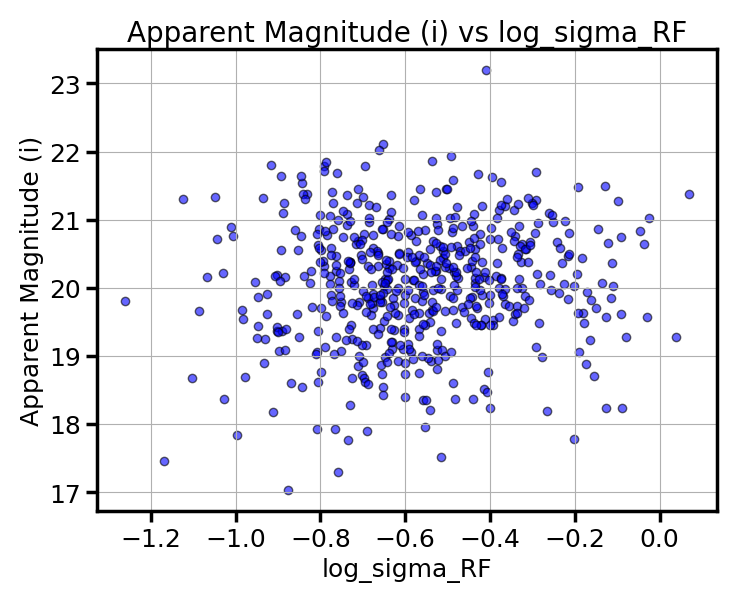

In [1150]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('Apparent Magnitude (i)')
plt.title('Apparent Magnitude (i) vs log_sigma_RF')
plt.grid(True)
plt.show()

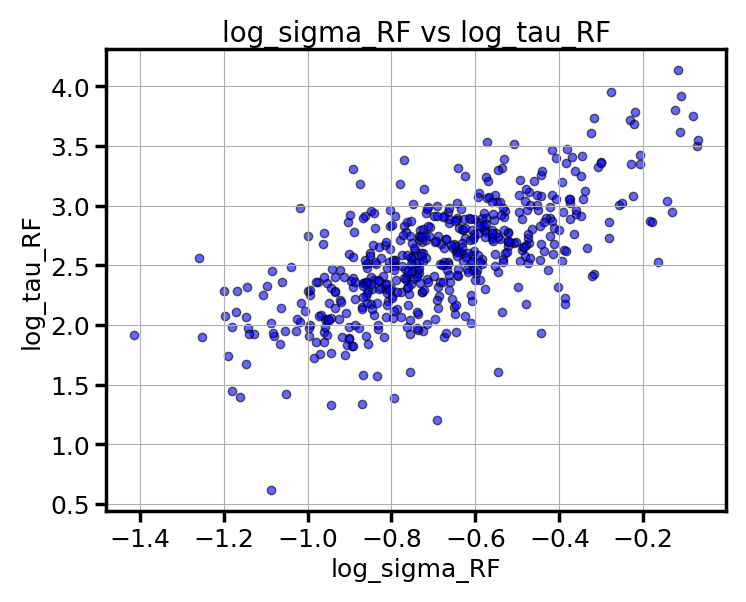

In [1155]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['log_tau_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('log_tau_RF')
plt.title('log_sigma_RF vs log_tau_RF')
plt.grid(True)
plt.show()

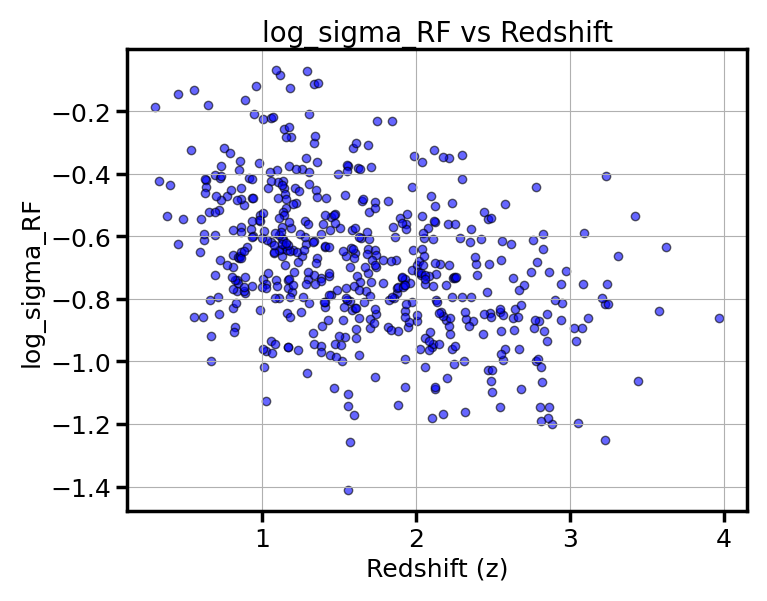

In [1156]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['log_sigma_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('log_sigma_RF')
plt.title('log_sigma_RF vs Redshift')
plt.grid(True)
plt.show()

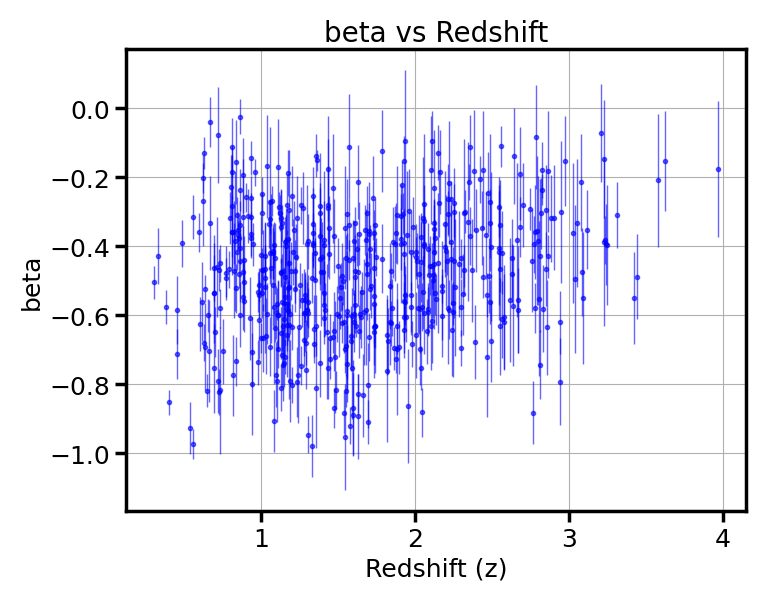

In [1160]:
plt.figure(figsize=(8, 6))
plt.errorbar(df['z'], df['beta'], yerr=df['beta_err'], c='blue', alpha=0.6, lw=1, marker='.', linestyle='none')
plt.xlabel('Redshift (z)')
plt.ylabel('beta')
plt.title('beta vs Redshift')
plt.grid(True)
plt.show()

### Completeness

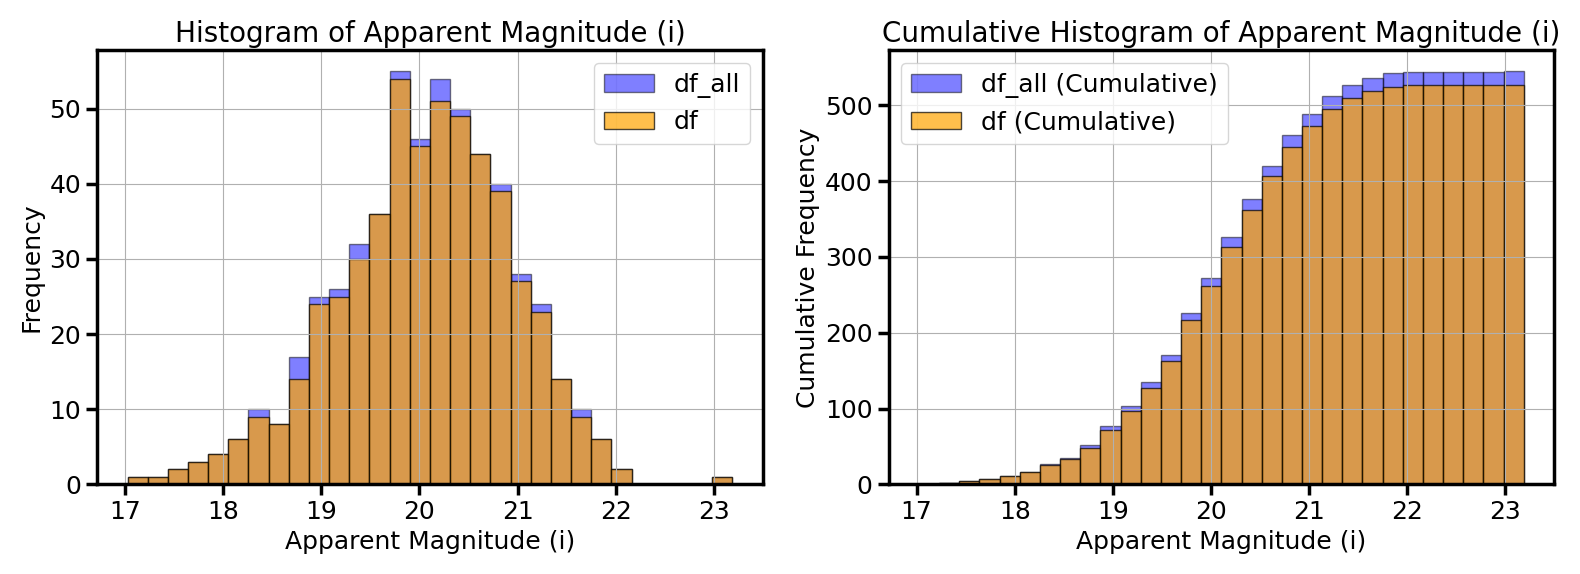

In [1164]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot histogram for df_all
ax1.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all', edgecolor='black')
ax1.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df', edgecolor='black')
ax1.set_xlabel('Apparent Magnitude (i)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Apparent Magnitude (i)')
ax1.legend()
ax1.grid(True)

# Plot cumulative histograms
ax2.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.set_xlabel('Apparent Magnitude (i)')
ax2.set_ylabel('Cumulative Frequency')
ax2.set_title('Cumulative Histogram of Apparent Magnitude (i)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

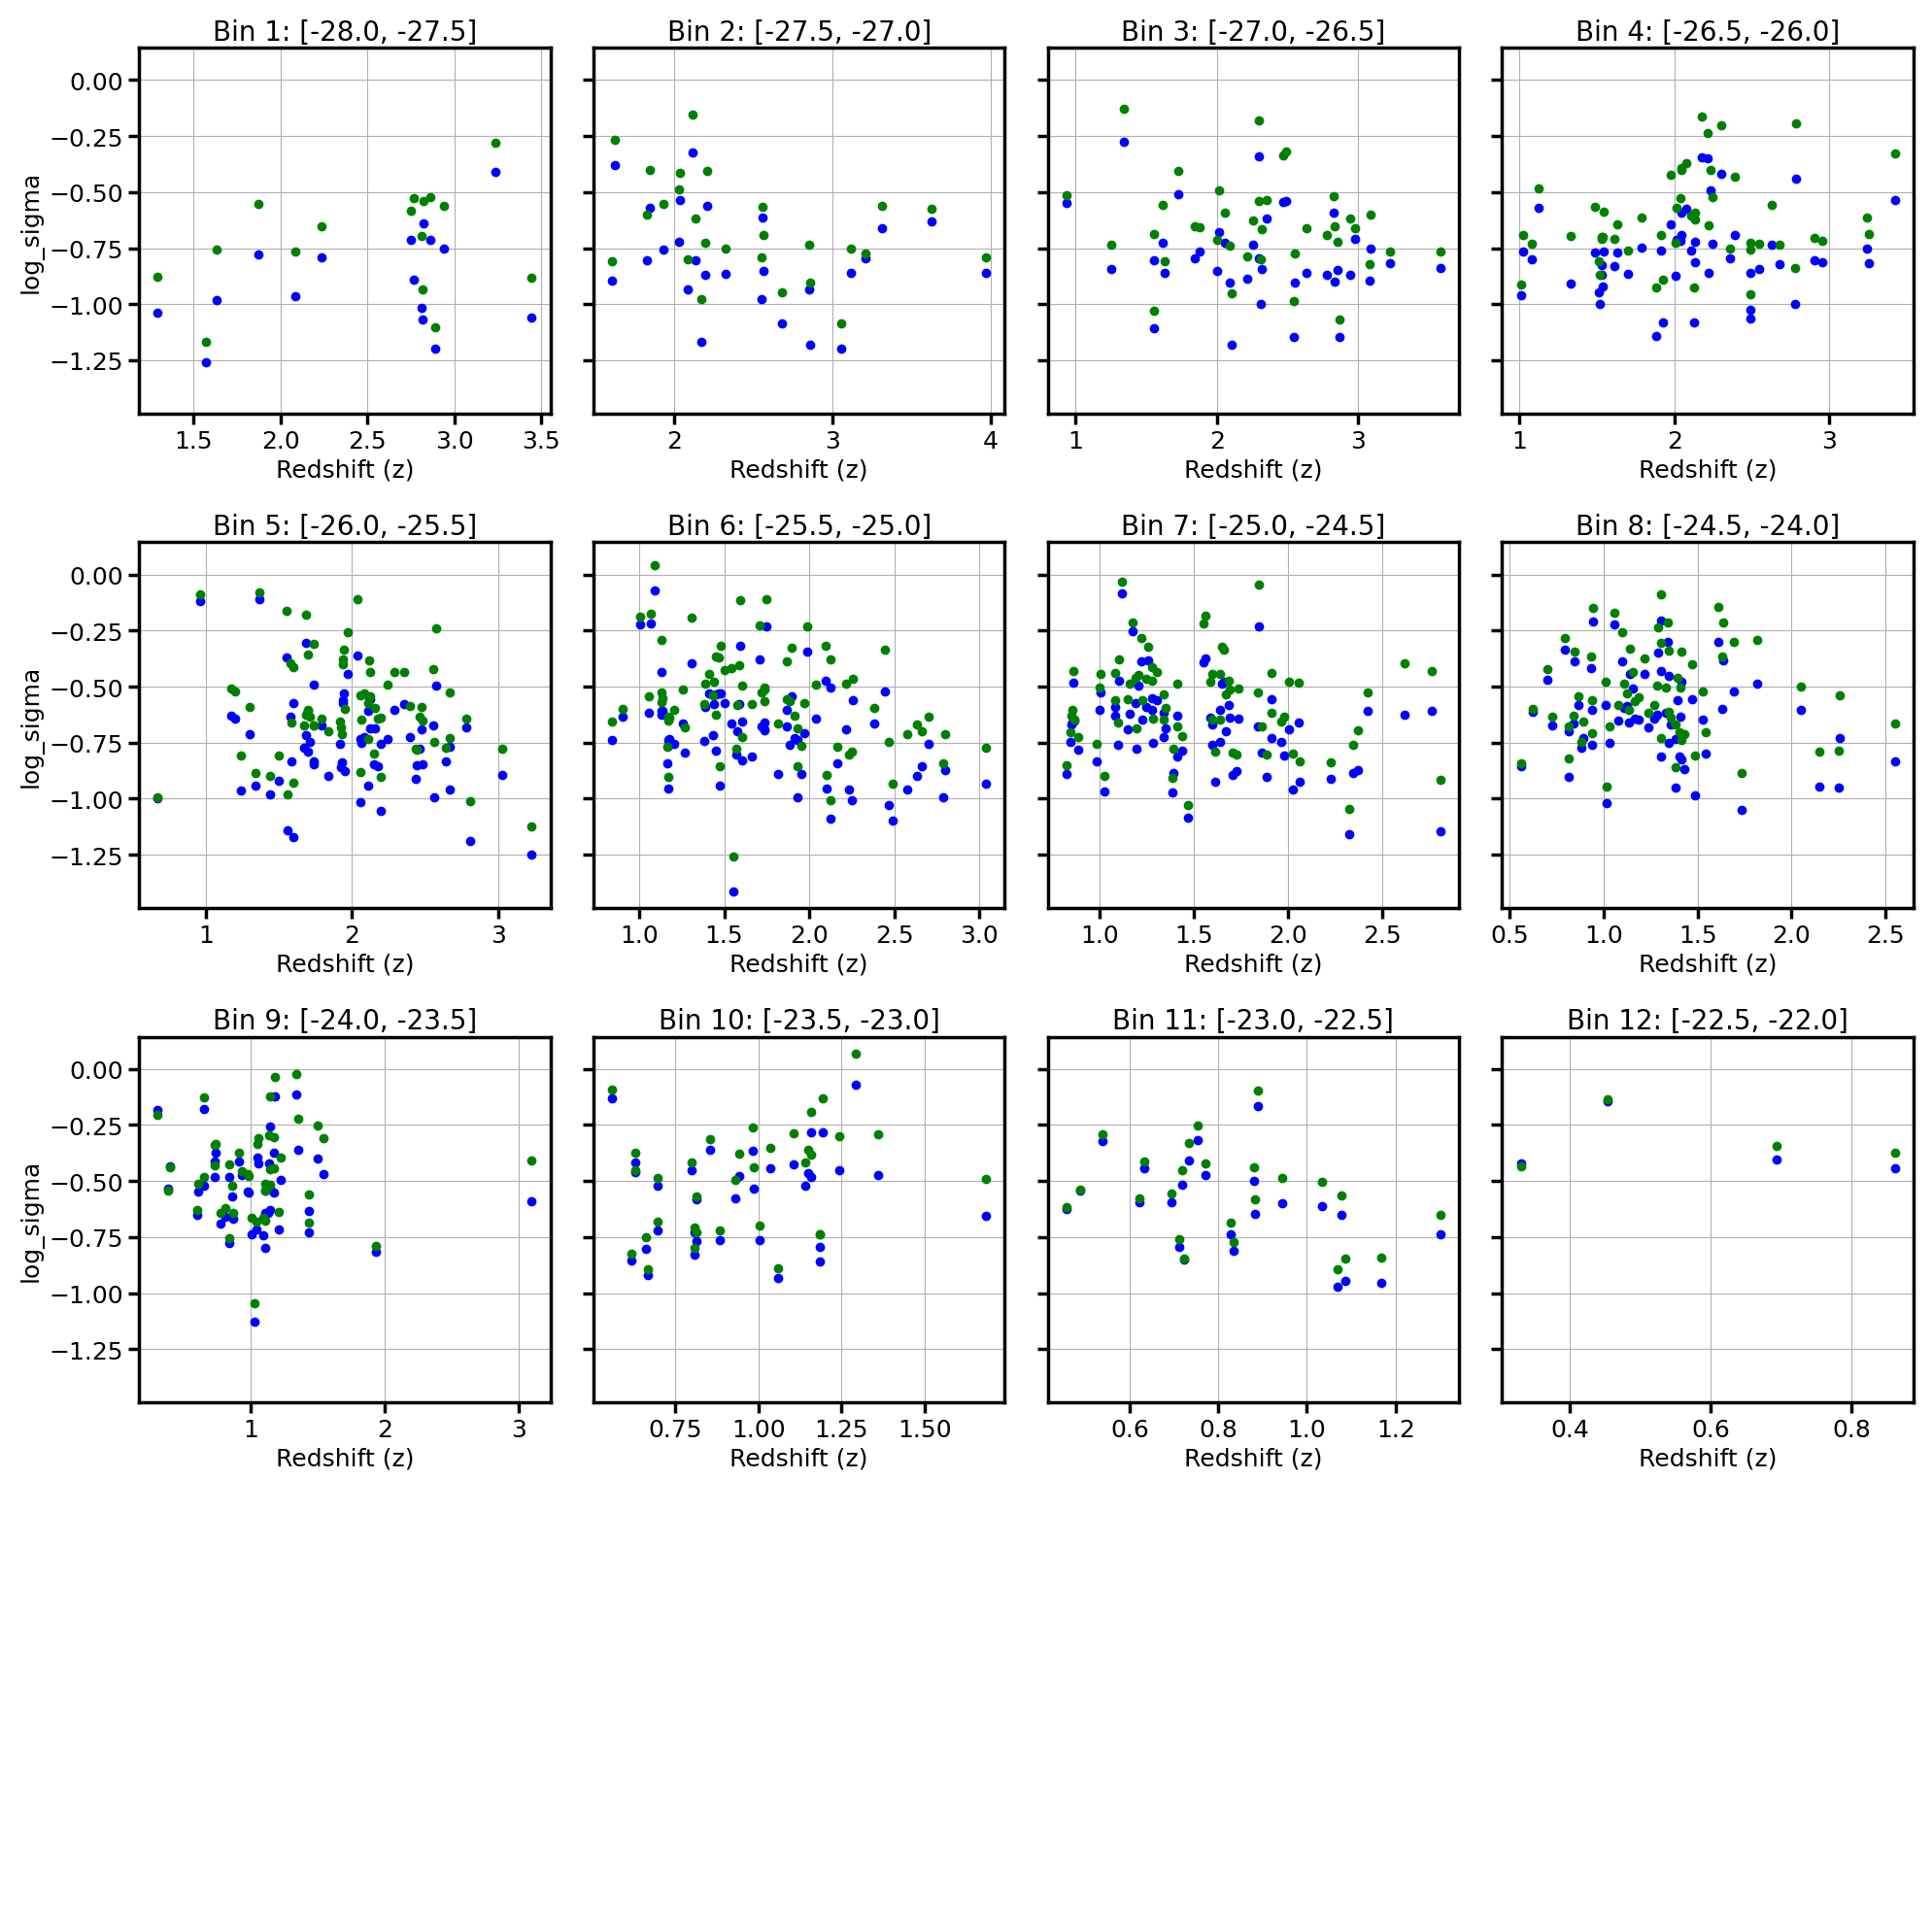

In [1165]:
from scipy.stats import linregress

# Define the bins for M_i

M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_sigma_RF'])
        y_vals = slope * np.linspace(1, 2) + intercept
        #axes[i].plot(np.linspace(1, 2), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_sigma_RF'], 'bo', label='Data')
        axes[i].plot(bin_data['z'], bin_data['log_sigma'], 'go', label='Data')
        #axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_sigma')
    axes[i].grid(True)
    #axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

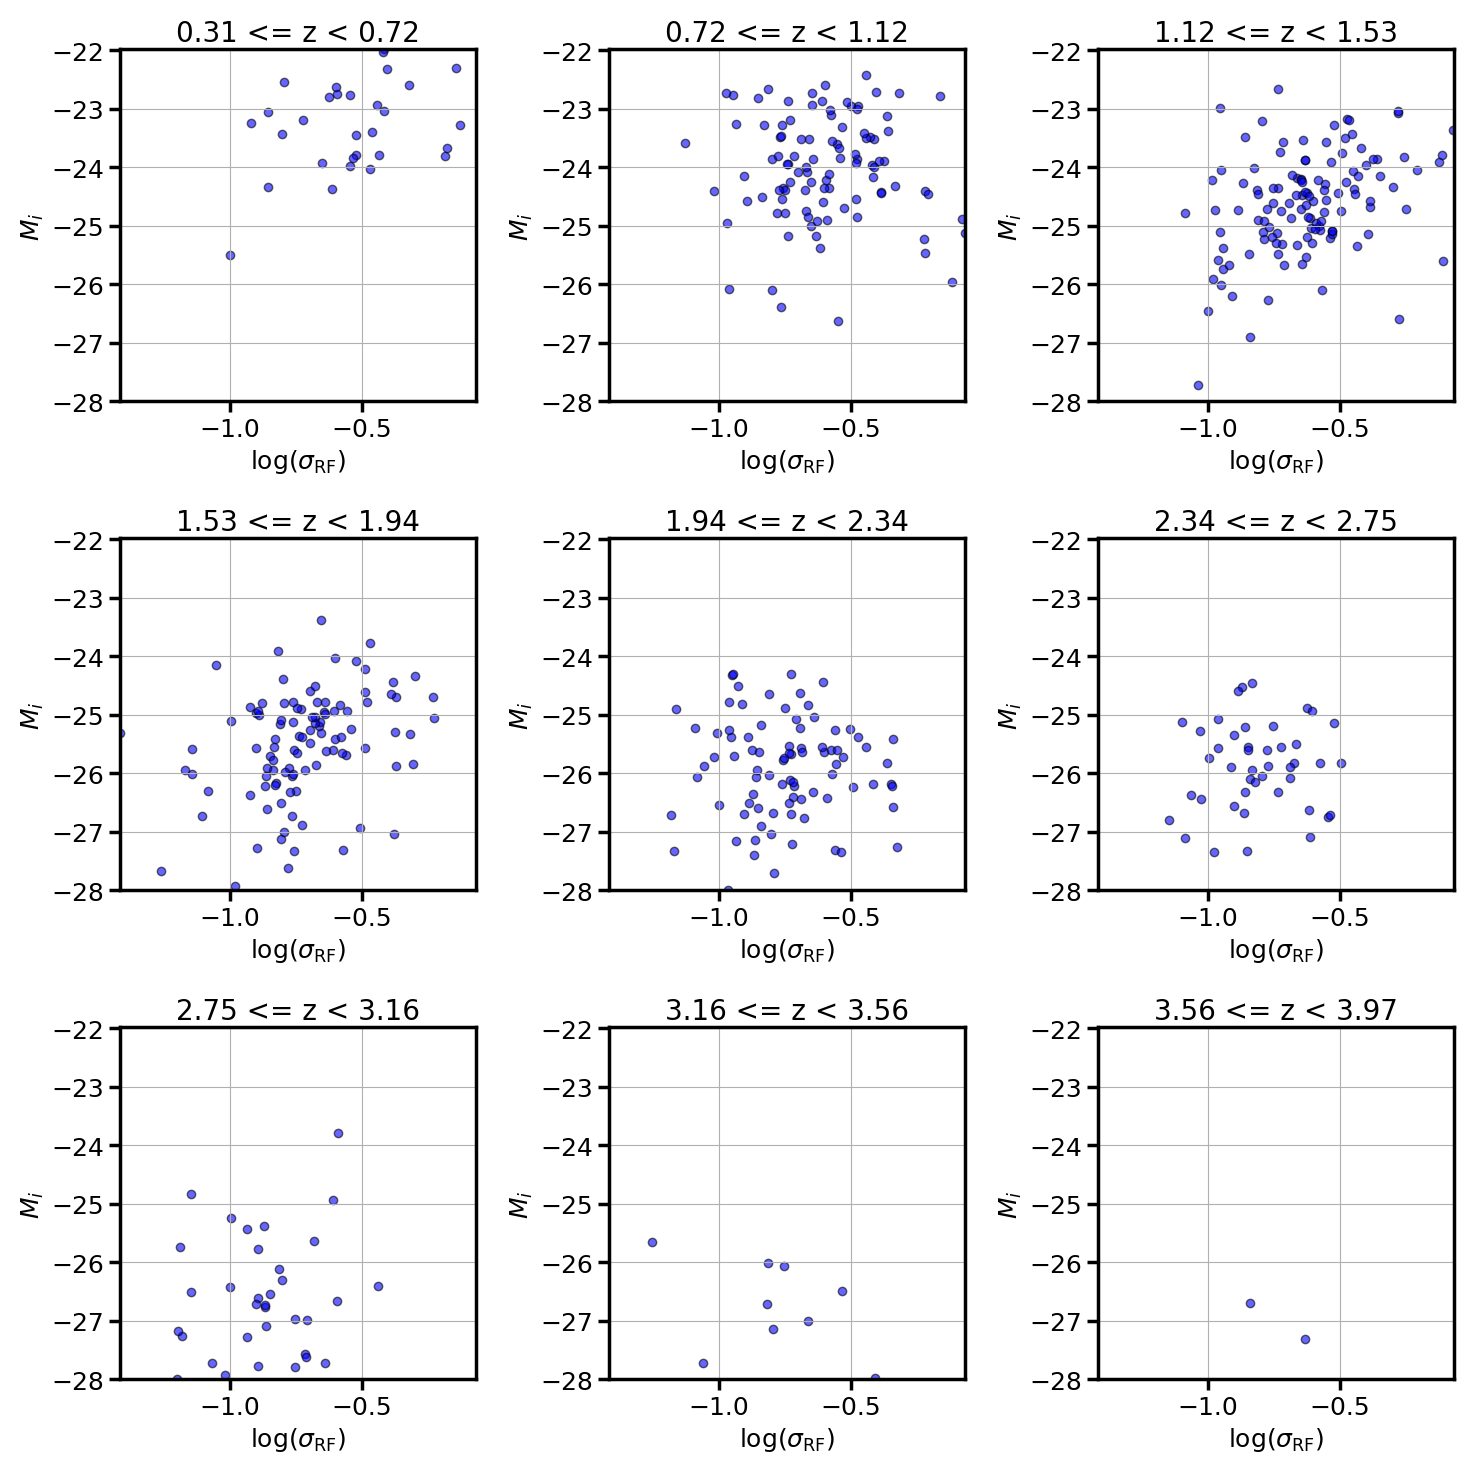

In [1166]:
# Determine the axis limits for all panels
x_min, x_max = df['log_sigma_RF'].min(), df['log_sigma_RF'].max()
y_min, y_max = df['M_i'].min(), df['M_i'].max()

# Define the redshift bins
redshift_bins = np.linspace(df['z'].min(), df['z'].max(), 10)  # Adjust the number of bins as needed

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust grid size based on the number of bins
axes = axes.flatten()

# Iterate over each redshift bin
for i in range(len(redshift_bins) - 1):
    # Filter the data for the current redshift bin
    bin_mask = (df['z'] >= redshift_bins[i]) & (df['z'] < redshift_bins[i + 1])
    bin_data = df[bin_mask]
    
    # Plot the data
    axes[i].scatter(bin_data['log_sigma_RF'], bin_data['M_i'], c='blue', alpha=0.6, edgecolor='black')
    axes[i].set_title(f"{redshift_bins[i]:.2f} <= z < {redshift_bins[i + 1]:.2f}")
    axes[i].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
    axes[i].set_ylabel(r"$M_i$")
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    axes[i].grid(True)

# Hide unused subplots
for j in range(len(redshift_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

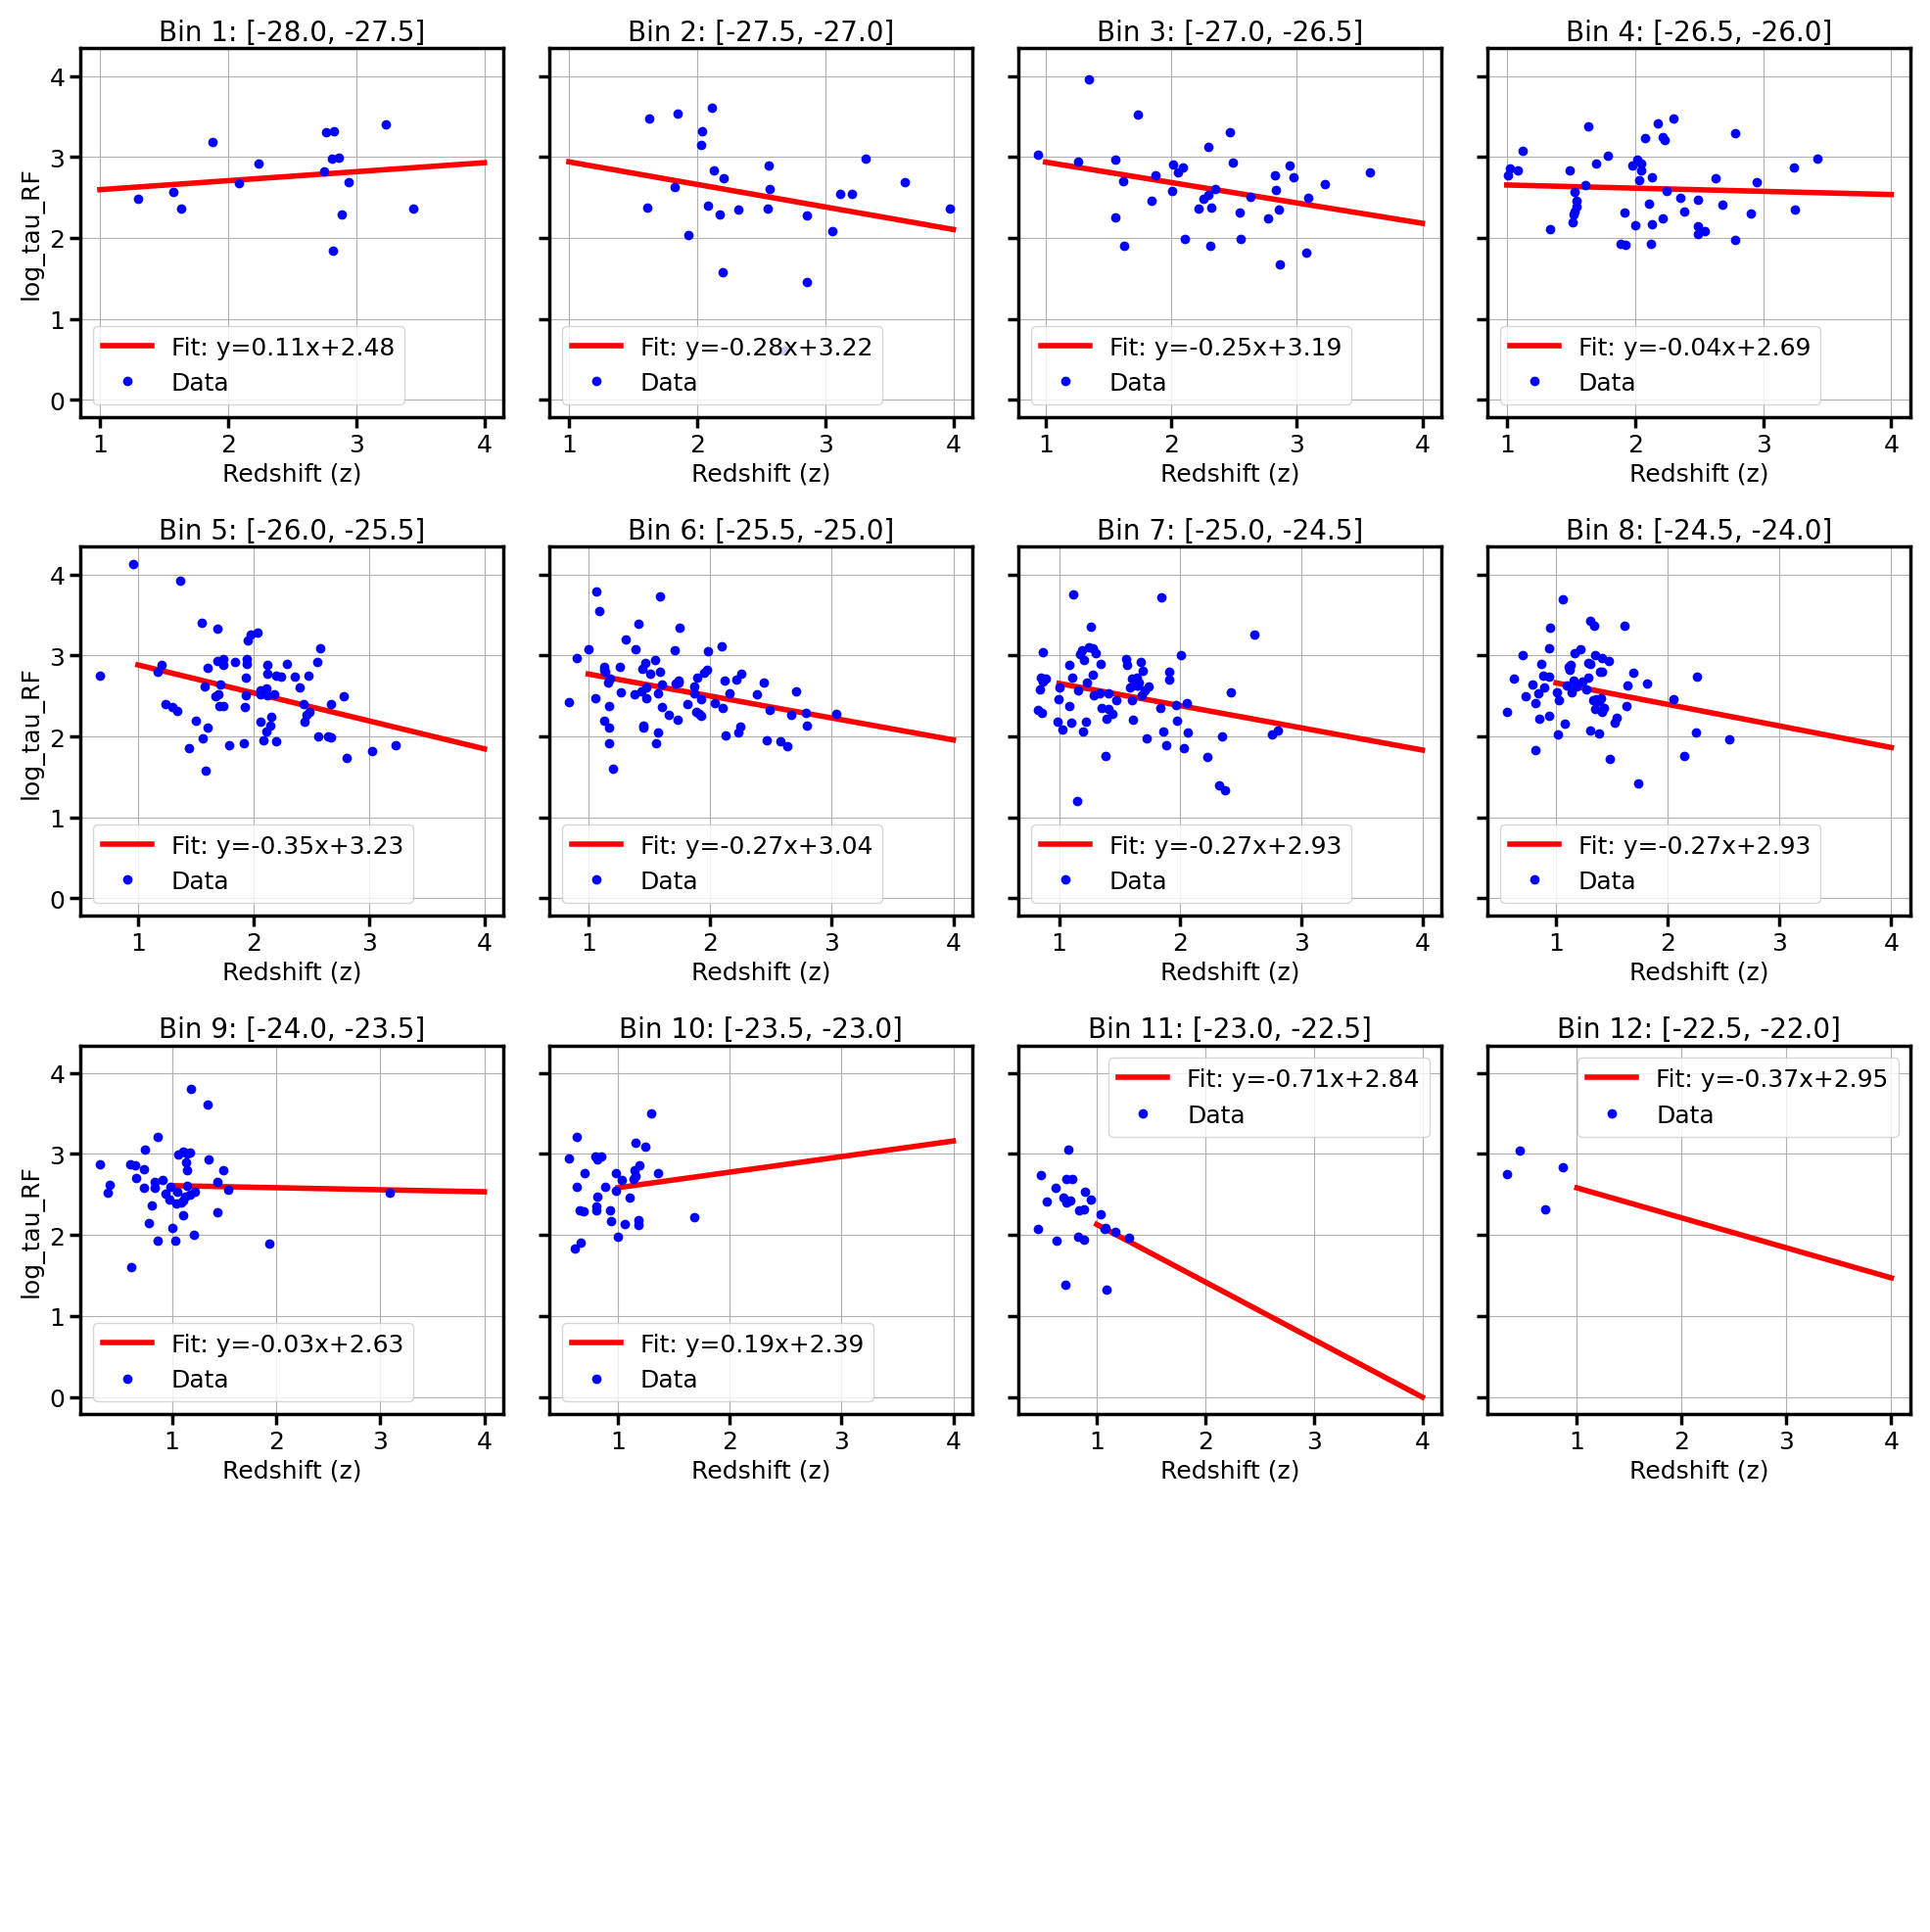

In [1167]:
from scipy.stats import linregress

# Define the bins for M_i
M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_tau_RF'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_tau_RF'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_tau_RF')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Load the SNIa data

In [233]:
import requests

# Define the URLs for the data and covariance files
data_file_url = "https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true"
covmat_file_url = "https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT+SYS.cov?raw=true"

def download_file(url):
    """Download a file from a given URL and return its content."""
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad status codes
    return response.text

# Download the data and covariance files
data_file_content = download_file(data_file_url)
covmat_file_content = download_file(covmat_file_url)

def build_covariance(data_content, covmat_content):
    """Build the covariance matrix for the data using the downloaded content."""
    print("Building covariance matrix from downloaded content")

    # Parse the data content
    data_lines = data_content.splitlines()
    zCMB = [float(line.split()[1]) for line in data_lines[1:]]  # Assuming zCMB is in the second column
    ww = [True] * len(zCMB)  # Placeholder for weights
    origlen = len(zCMB)

    # Parse the covariance content
    cov_lines = covmat_content.splitlines()
    n = len(zCMB)
    C = np.zeros((n, n))
    ii = -1
    jj = -1
    for i in range(origlen):
        jj = -1
        if ww[i]:
            ii += 1
        for j in range(origlen):
            if ww[j]:
                jj += 1
            val = float(cov_lines[i * origlen + j])
            if ww[i] and ww[j]:
                C[ii, jj] = val

    print("Covariance matrix built successfully")
    return C

# Build the covariance matrix
covariance_matrix = build_covariance(data_file_content, covmat_file_content)
covariance_matrix

Building covariance matrix from downloaded content
Covariance matrix built successfully


array([[ 1.701000e+03,  3.177108e-02,  5.754430e-03, ...,  2.088400e-04,
         2.945500e-04, -8.595000e-05],
       [-2.701100e-04,  5.754430e-03,  3.456656e-02, ..., -2.746800e-04,
        -2.863200e-04, -2.456300e-04],
       [-2.363400e-04,  3.100600e-04,  6.595500e-04, ..., -4.070400e-04,
         1.936450e-03,  3.214810e-03],
       ...,
       [ 7.426700e-04,  2.945500e-04, -2.863200e-04, ...,  2.093270e-03,
         4.157373e-02,  4.902260e-03],
       [ 5.887030e-03, -8.595000e-05, -2.456300e-04, ...,  1.096370e-03,
         4.902260e-03,  6.742823e-02],
       [ 8.751110e-03, -2.701100e-04, -2.363400e-04, ...,  7.426700e-04,
         5.887030e-03,  8.751110e-03]])

In [ ]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon.keys()

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_29451/3100491465.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')

### Likelihood function

100%|██████████| 1000/1000 [55:14<00:00,  3.31s/it]


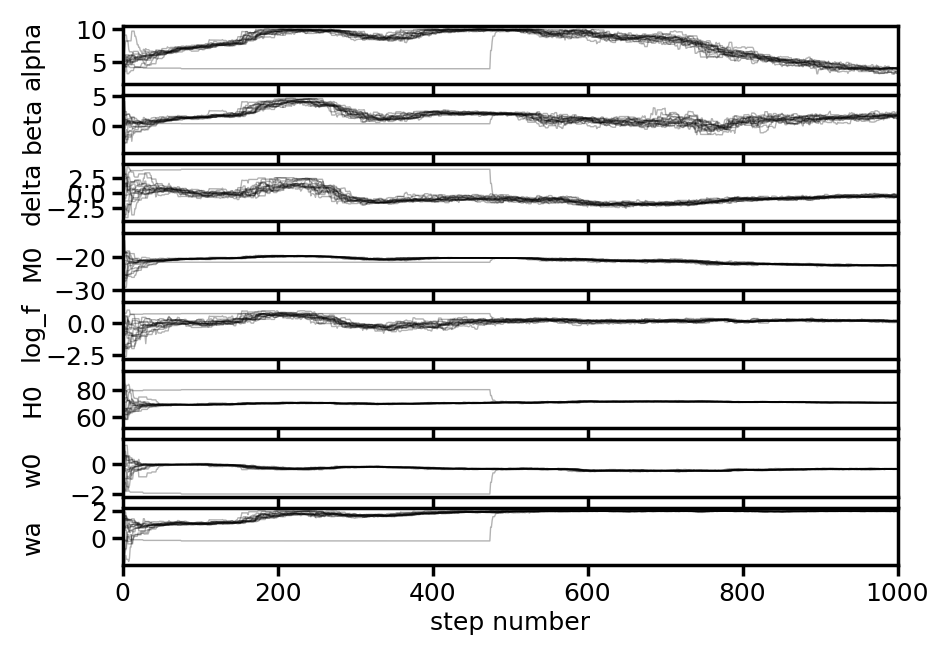

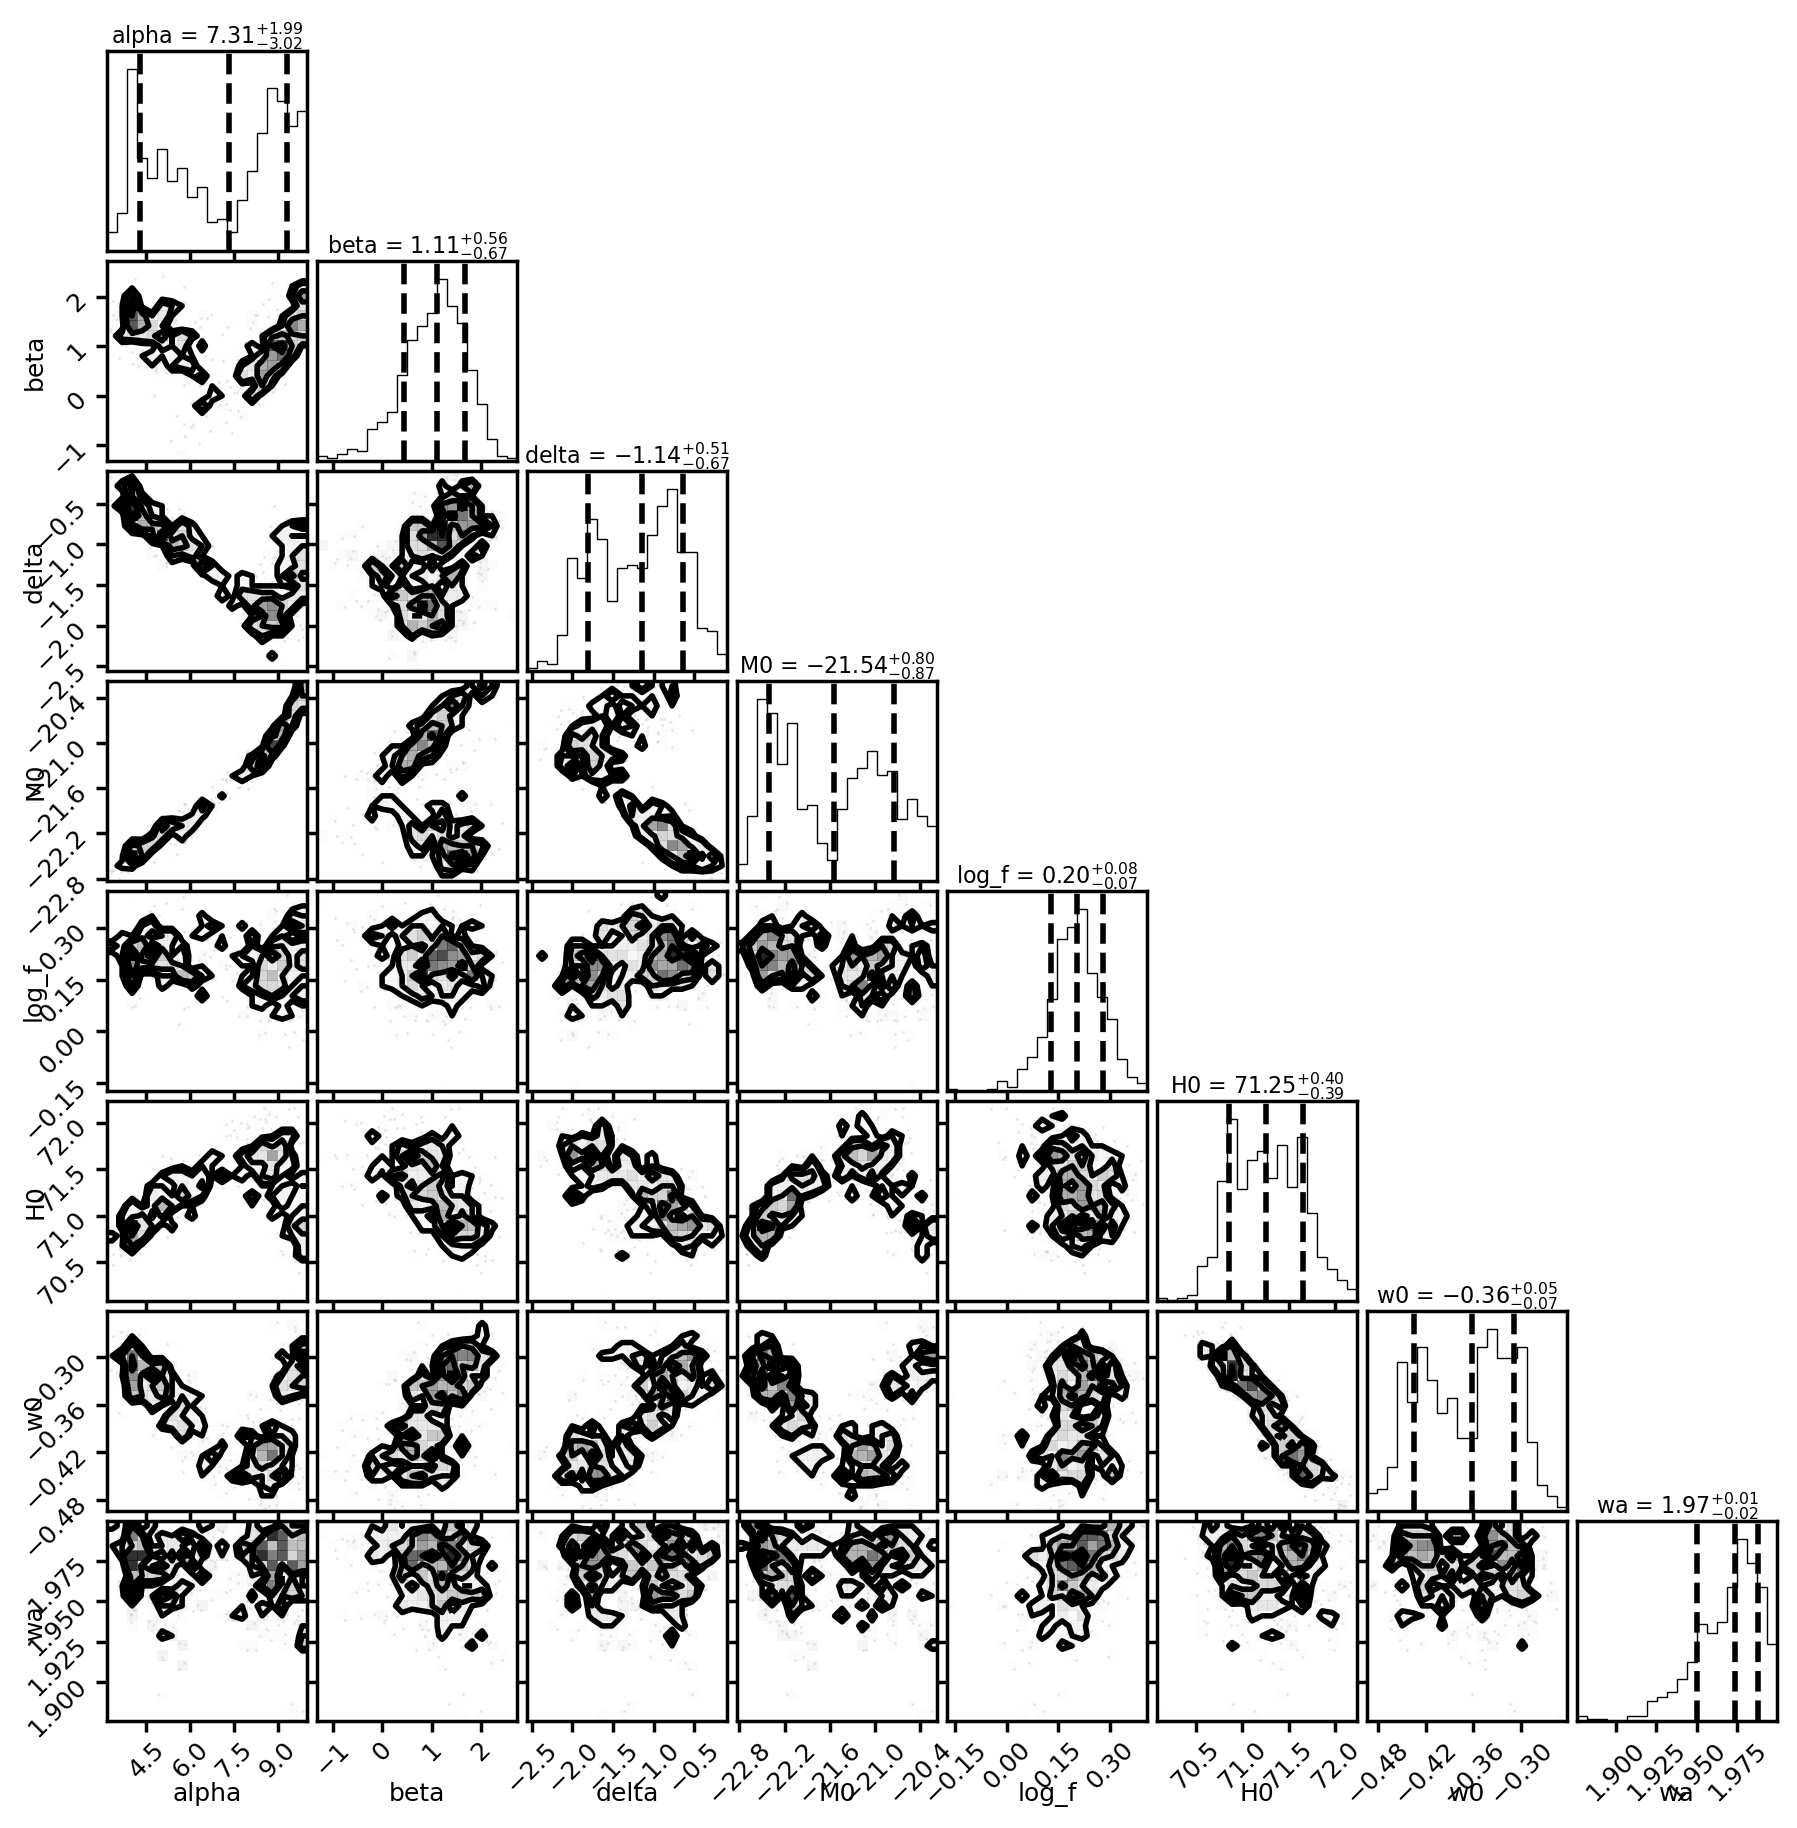

In [251]:
import emcee
import corner
import numpy as np
from astropy.cosmology import w0waCDM
import matplotlib.pyplot as plt

def M_model(M0, alpha, beta, delta):
    return M0 + alpha * (df["log_sigma_RF"]+0.3) + beta * (df["beta"]+0.5) + delta * (df["log_tau_RF"]-2.5)

def K_corr(z, alpha_nu=-0.5):
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# log_likelihood function
def log_likelihood(theta):

    alpha, beta, delta, M0, log_f, H0, w0, wa = theta

    cosmo = w0waCDM(H0=H0, Om0=0.3, Ode0=0.7, w0=w0, wa=wa)
    mu_model = cosmo.distmod(df['z']).value

    # Prior
    for i, (key, val) in enumerate(priors.items()):
        lower, upper = val
        if not (lower < theta[i] < upper):
            return -np.inf
    
    # Model distance modulus
    mu_pred_agn = df['apparent_mag_i'] - M_model(M0, alpha, beta, delta) - K_corr(df['z'])

    # Model error
    mu_pred_agn_err = np.sqrt(df['apparent_mag_i_err']**2 + 
                          (alpha * df["log_sigma_RF_err"])**2 + 
                          (beta * df["beta_err"])**2 + 
                          (delta * df["log_tau_RF_err"])**2 +
                          (-2.5 * 0.3 * np.log10(1 + df["z"]))**2 + # K-correction error
                          np.exp(2 * log_f))

    dmu_lim = 20.5 - M_model(M0, alpha, beta, delta) - K_corr(df['z']) - mu_model
    dmu_agn = mu_pred_agn - mu_model

    ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) + \
            np.sum(np.log(st.truncnorm.cdf(dmu_agn, scale=mu_pred_agn_err, a=-np.inf, b=dmu_lim)))

    # SNIa
    mu_model = cosmo.distmod(df_pantheon['zHD']).value
    mu_pred_snia = df_pantheon['MU_SH0ES']
    dmu_snia = mu_pred_snia - mu_model

    #ll_snia = np.sum(np.log(st.norm.pdf(dmu_snia, scale=df_pantheon['MU_SH0ES_ERR_DIAG'])))
    ll_snia = -0.5 * np.dot(dmu_snia, np.linalg.solve(covariance_matrix, dmu_snia)) # Slow

    return ll_snia + ll_agn

# Define a dictionary to hold model parameters
priors = {
    "alpha": (2, 10),
    "beta": (-5, 5),
    "delta": (-5, 5),
    "M0": (-30, -10),
    "log_f": (-3, 2),
    # cosmology parameters
    "H0": (50, 100),
    #"Om0": (0.1, 0.5),
    #"Ode0": (0.1, 0.9),
    "w0": (-2, 2),
    "wa": (-2, 2)
}

# Set up the sampler
ndim = len(priors)  # Number of parameters
nwalkers = 16  # Number of walkers
nsteps = 1000  # Number of steps

# Run the MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)

# Initial positions of the walkers
initial_pos = np.array([np.random.uniform(low, high, nwalkers) for low, high in priors.values()]).T

sampler.run_mcmc(initial_pos, nsteps, progress=True)

# Extract the samples
samples_by_chain = sampler.get_chain()
#tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

labels = list(priors.keys())

fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_by_chain[:, :, i], "k", alpha=0.3, lw=1)
    ax.set_xlim(0, len(samples_by_chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.show()

fig = corner.corner(flat_samples, show_titles=True, labels=labels, quantiles=[0.16, 0.5, 0.84],
                    label_kwargs=dict(fontsize=18), title_kwargs=dict(fontsize=16));
plt.show()

results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(priors.keys())}

In [199]:
print(f'scatter = {np.sqrt(np.exp(2 * results['log_f'][1]))}') 


scatter = 0.9608431834865712


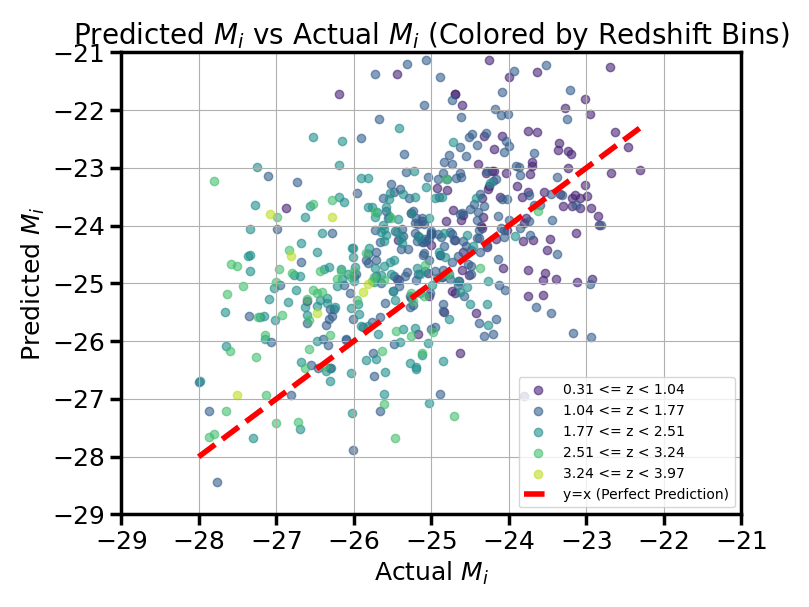

In [277]:

plt.figure(figsize=(8, 6))

# Assuming `predicted_M_i` contains the predicted M_i values
M_i_pred = M_model(
    results['M0'][1], 
    results['alpha'][1], 
    results['beta'][1],
    results['delta'][1]
)
# Extract actual M_i values from the dataframe

# Convert Mi(z=2) to Mi(z=zi)
actual_M_i = df['M_i'] - K_corr(df['z']) + K_corr(2.0)

# Define redshift bins
redshift_bins = np.linspace(df['z'].min(), df['z'].max(), 6)

# Use the viridis color scale for the scatter plot, coloring each redshift bin
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=redshift_bins.min(), vmax=redshift_bins.max())

for i in range(len(redshift_bins) - 1):
    bin_mask = (df['z'] >= redshift_bins[i]) & (df['z'] < redshift_bins[i + 1])
    plt.scatter(
        actual_M_i[bin_mask],
        M_i_pred[bin_mask],
        color=cmap(norm((redshift_bins[i] + redshift_bins[i + 1]) / 2)),
        label=f'{redshift_bins[i]:.2f} <= z < {redshift_bins[i + 1]:.2f}',
        alpha=0.6,
    )

# Add a colorbar for the redshift bins
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#plt.colorbar(sm, label='Redshift (z)')

# Add a perfect prediction line
plt.plot(
    [actual_M_i.min(), actual_M_i.max()],
    [actual_M_i.min(), actual_M_i.max()],
    'r--',
    label='y=x (Perfect Prediction)'
)

plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$ (Colored by Redshift Bins)')
plt.xlim(-29, -21)
plt.ylim(-29, -21)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

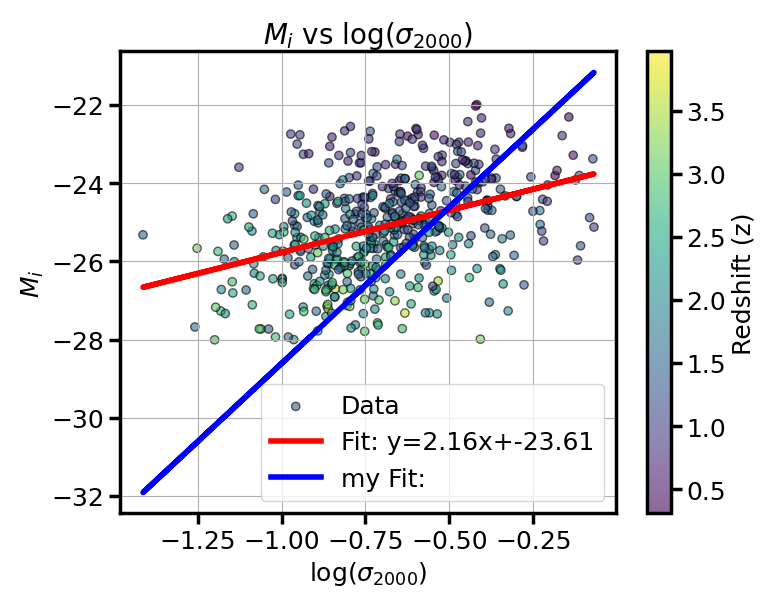

In [253]:
from scipy.stats import linregress

import matplotlib.pyplot as plt

# Extract the data
x = df['log_sigma_RF']
y = df['M_i']

# Fit a line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
y_fit = slope * x + intercept

# Plot the data and the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=df['z'], alpha=0.6, edgecolor='black', label='Data')
plt.plot(x, y_fit, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')

y_fit = 8 * x + intercept + 3
plt.plot(x, y_fit, 'b-', label=f'my Fit: ')

plt.xlabel(r"$\log(\sigma_{2000})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(\sigma_{2000})$")
plt.legend()
plt.grid(True)
plt.colorbar(label='Redshift (z)')
plt.show()

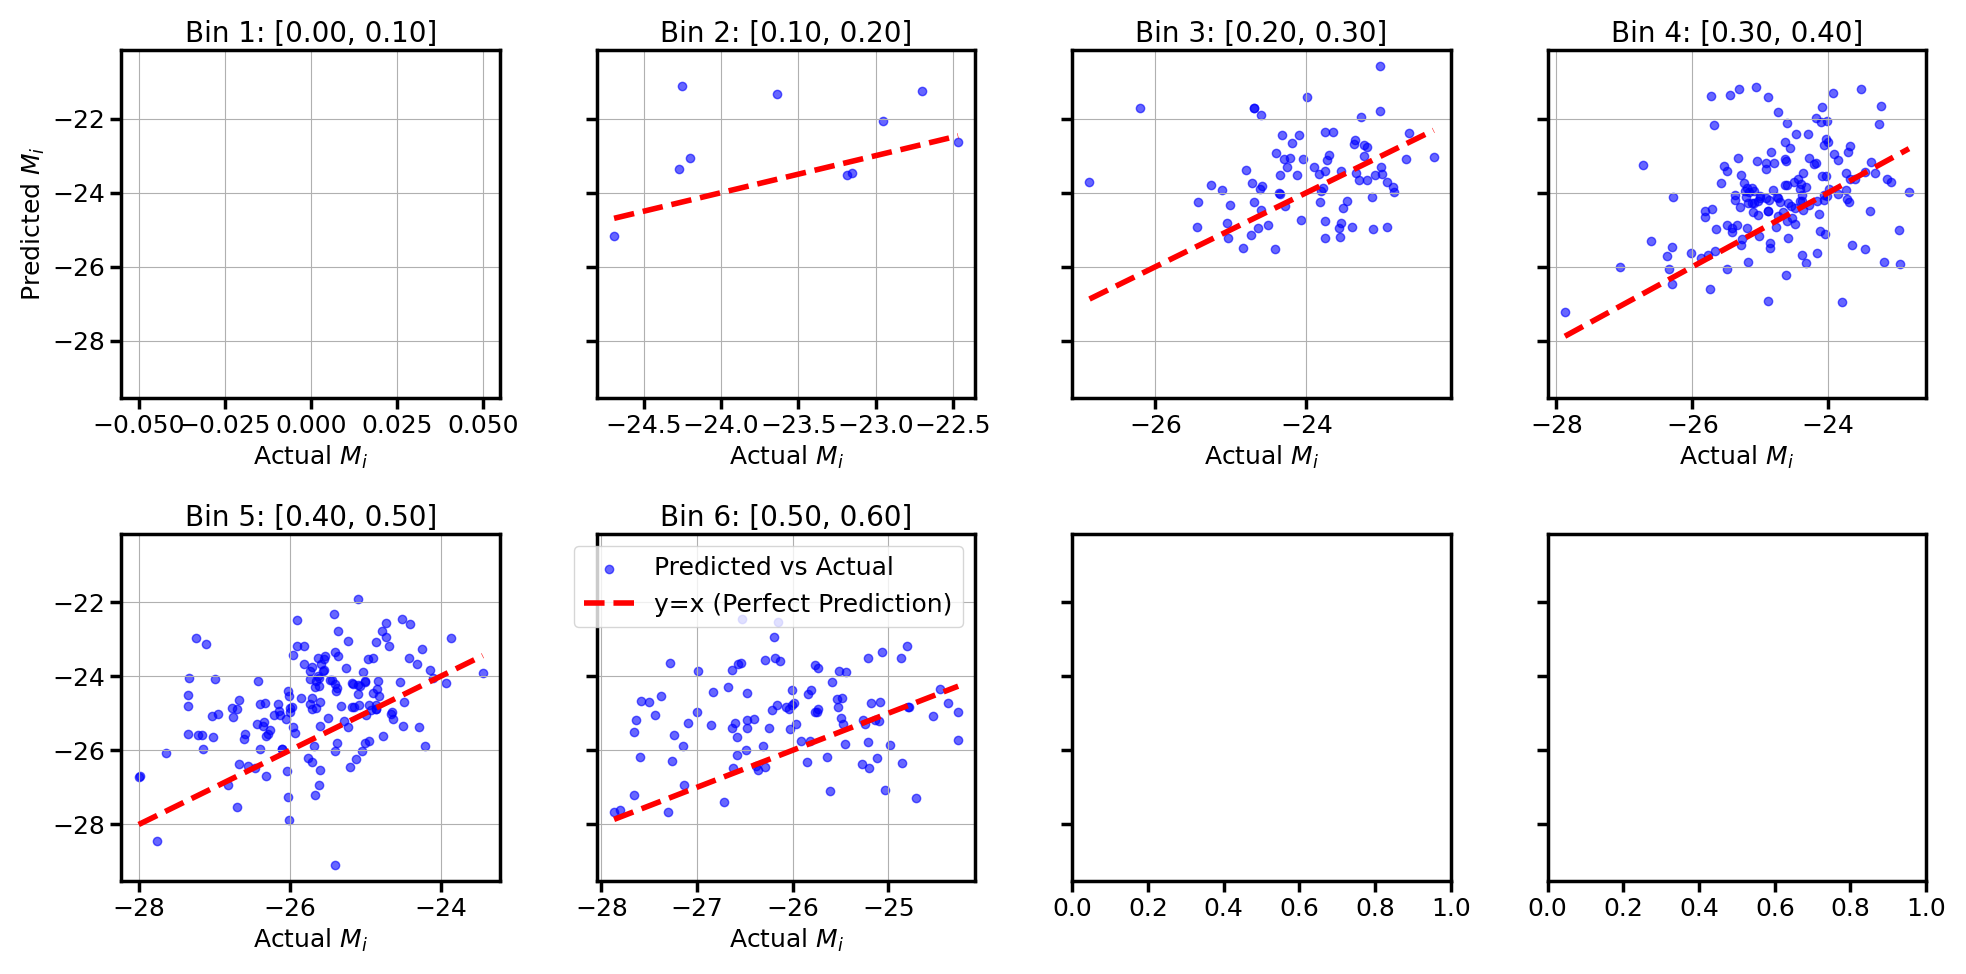

In [254]:
import matplotlib.pyplot as plt
# Define the bins for np.log10(1 + df['z'])
bins = np.arange(0, np.log10(1 + df['z']).max(), 0.1)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Iterate over each bin and plot
for i in range(len(bins) - 1):
    bin_mask = (np.log10(1 + df['z']) >= bins[i]) & (np.log10(1 + df['z']) < bins[i + 1])
    bin_data_actual = actual_M_i[bin_mask]
    bin_data_predicted = M_i_pred[bin_mask]
    
    axes[i].scatter(bin_data_actual, bin_data_predicted, c='blue', alpha=0.6, label='Predicted vs Actual')
    axes[i].plot([bin_data_actual.min(), bin_data_actual.max()], 
                 [bin_data_actual.min(), bin_data_actual.max()], 'r--', label='y=x (Perfect Prediction)')
    axes[i].set_title(f'Bin {i+1}: [{bins[i]:.2f}, {bins[i+1]:.2f}]')
    axes[i].set_xlabel('Actual $M_i$')
    if i == 0:
        axes[i].set_ylabel('Predicted $M_i$')
    axes[i].grid(True)
axes[i].legend()
    
plt.tight_layout()
plt.show()

### Hubble Diagram

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_29451/2636964468.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


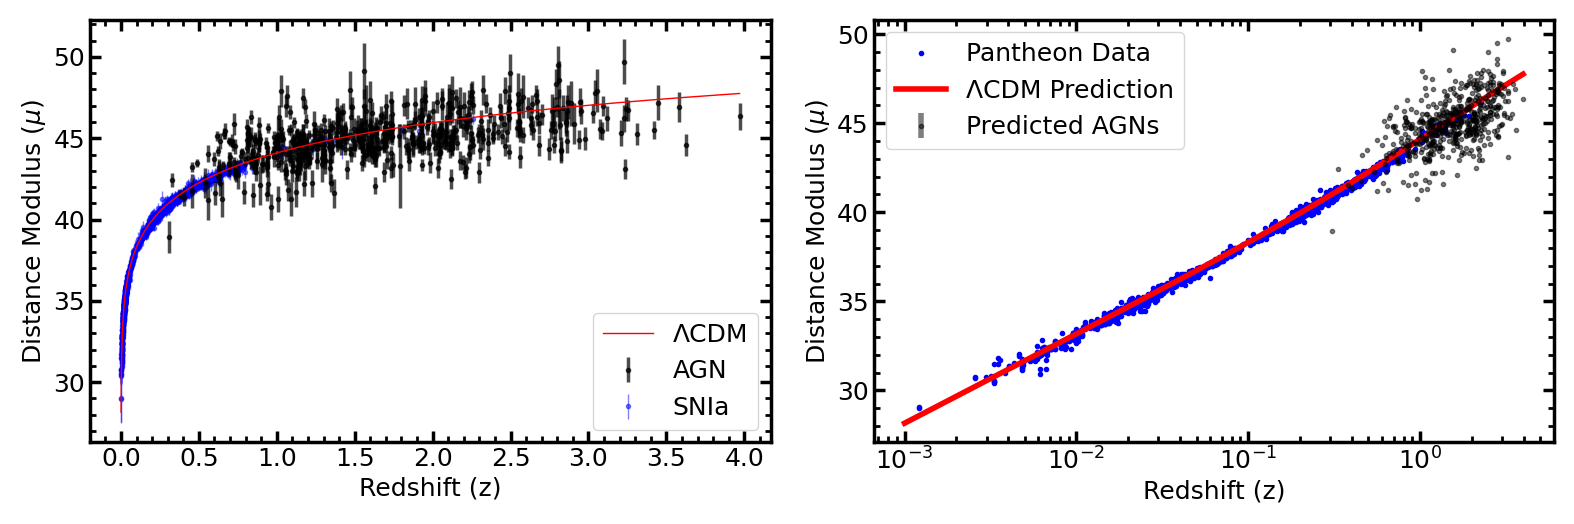

In [ ]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon



#mu_pred = d['apparent_mag_i'] - M_model(posterior_samples["alpha"], posterior_samples["beta"], posterior_samples["mu"], posterior_samples["nu"], d["color"], d["log_sigma_3"], d["log_tau_RF"], posterior_samples["M0"], d["z"]) - K_corr(d["z"])
#mu_pred_median = np.percentile(mu_pred, 50, axis=0)
mu_pred = np.array([df['interpolated_mag_i'] - M_model(s[3], s[0], s[1], s[2]) - K_corr(df["z"]) for s in flat_samples])

mu_pred_median = np.percentile(mu_pred, 50, axis=0)
mu_pred_16th = np.percentile(mu_pred, 16, axis=0)
mu_pred_84th = np.percentile(mu_pred, 84, axis=0)
mu_pred_std = np.sqrt(df['apparent_mag_i_err']**2 + np.abs(0.5 * (mu_pred_84th - mu_pred_16th))**2 + (-2.5 * 0.3 * np.log10(1 + df["z"]))**2)


residuals = mu_pred_median - cosmo.distmod(df['z']).value

fig, axs = plt.subplots(1, 2, figsize=(16, 5.5))



for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
    ax.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True)
    ax.tick_params(axis='both', direction='in', which='both')

# First subplot: AGN and SNIa distance modulus with ΛCDM model
axs[0].errorbar(df["z"], mu_pred_median, yerr=mu_pred_std, fmt='.', label="AGN", alpha=0.7, color="black", lw=2.5, zorder=-9)
axs[0].errorbar(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"], fmt='.', color="blue", linestyle='none', lw=1, label="SNIa", alpha=0.5, zorder=-10)
axs[0].plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM", color="red", lw=1.5)
axs[0].set_xlabel("Redshift (z)")
axs[0].set_ylabel(r"Distance Modulus ($\mu$)")
axs[0].legend()

# Second subplot: Predicted AGNs and Pantheon data with ΛCDM model
axs[1].errorbar(df["z"], mu_pred_median, yerr=0, fmt='.', label="Predicted AGNs", alpha=0.5, color="k")
axs[1].plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")
axs[1].semilogx(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
axs[1].set_xlabel("Redshift (z)")
axs[1].set_ylabel(r"Distance Modulus ($\mu$)")
axs[1].legend()

plt.tight_layout()
plt.show()

### Residuals Analysis

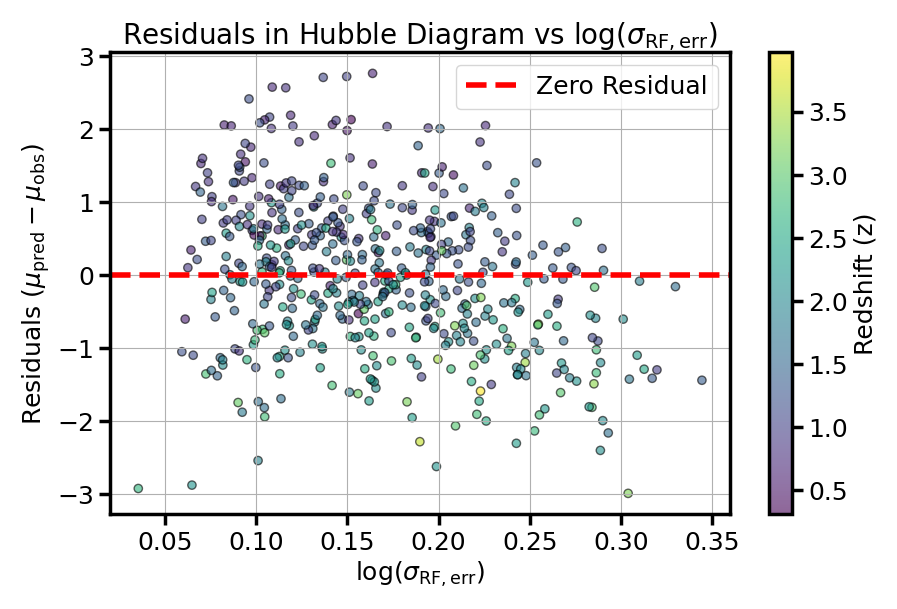

In [221]:
plt.figure(figsize=(10, 6))
plt.scatter(df['log_sigma_RF_err'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\sigma_\mathrm{RF, err})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\sigma_\mathrm{RF, err})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

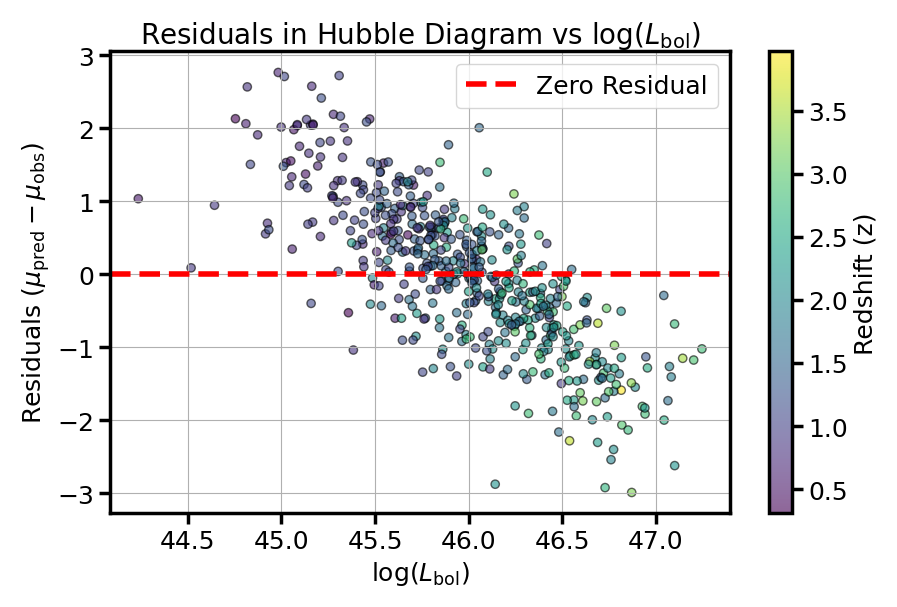

In [213]:
plt.figure(figsize=(10, 6))
plt.scatter(df['log_lbol'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(L_\mathrm{bol})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(L_\mathrm{bol})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

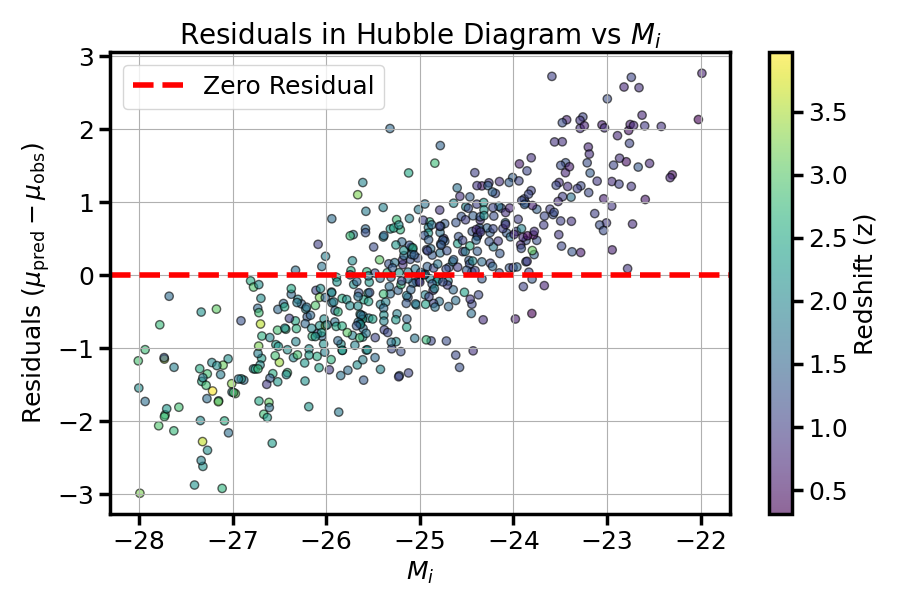

In [222]:
plt.figure(figsize=(10, 6))
plt.scatter(df['M_i'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r"$M_i$")
plt.ylabel(r"Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)")
plt.title(r"Residuals in Hubble Diagram vs $M_i$")
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

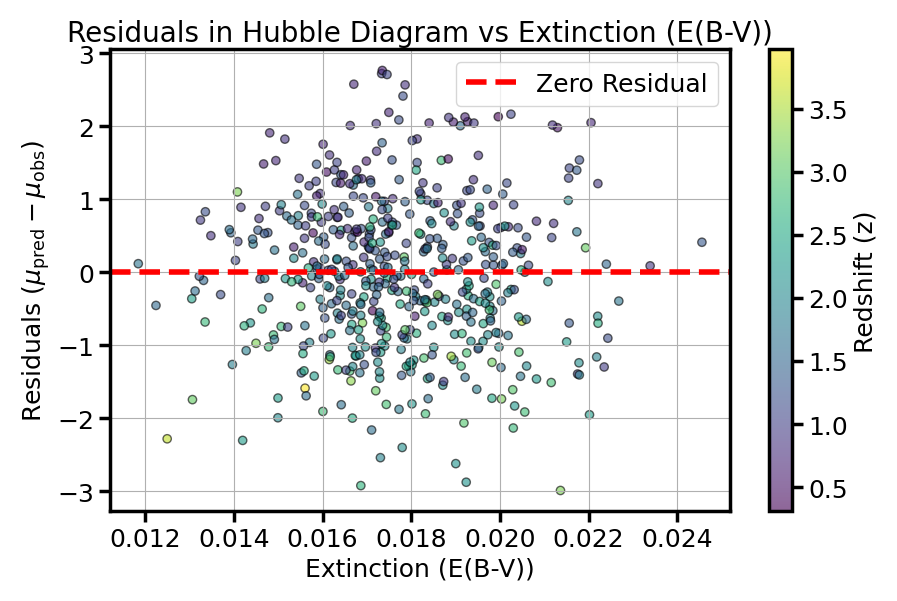

In [220]:
plt.figure(figsize=(10, 6))
plt.scatter(df['ebv'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Extinction (E(B-V))')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Extinction (E(B-V))')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_29451/1752906416.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')


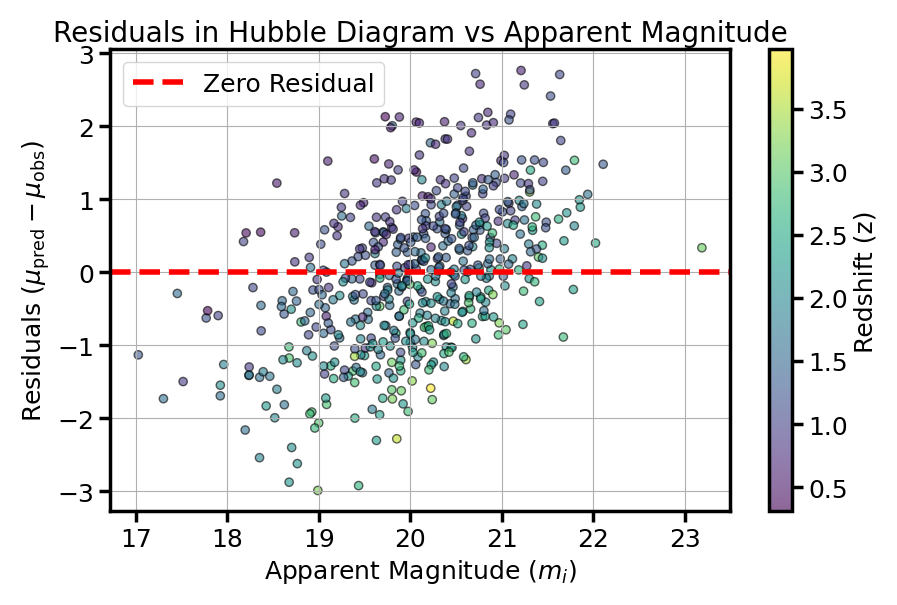

In [214]:
import matplotlib.pyplot as plt

# Calculate the observed distance modulus (mu_obs)
#mu_obs = df['apparent_mag_i'] - df['M_i']

# Calculate the residuals (difference between predicted and observed distance modulus)
#residuals = mu_pred_median - mu_obs

# Use d['z'] as the color for the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['apparent_mag_i'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Apparent Magnitude ($m_i$)')
plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Apparent Magnitude')
plt.colorbar(scatter, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_29451/87464218.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')


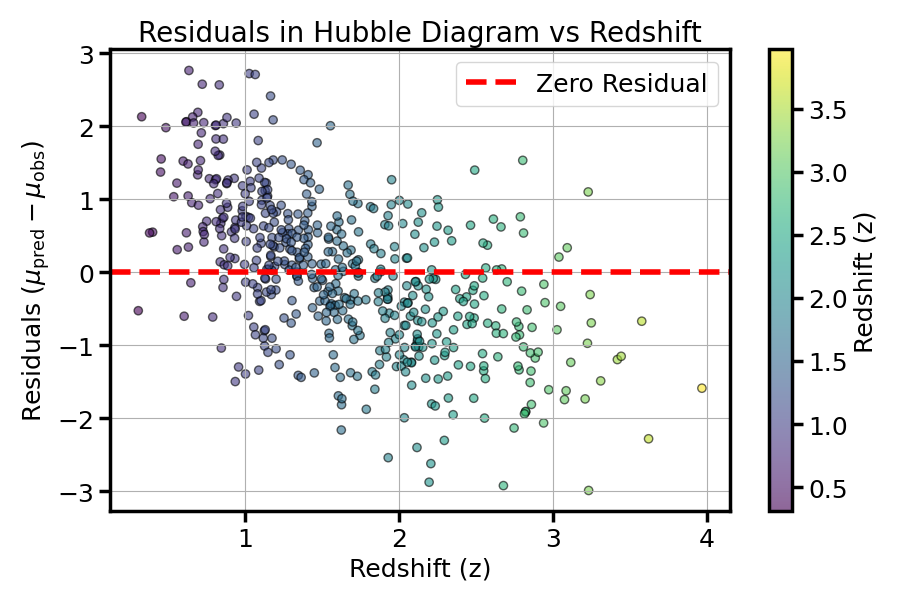

In [215]:
import matplotlib.pyplot as plt

# Plot residuals vs redshift
plt.figure(figsize=(10, 6))
plt.scatter(df['z'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Redshift (z)')
plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Redshift')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

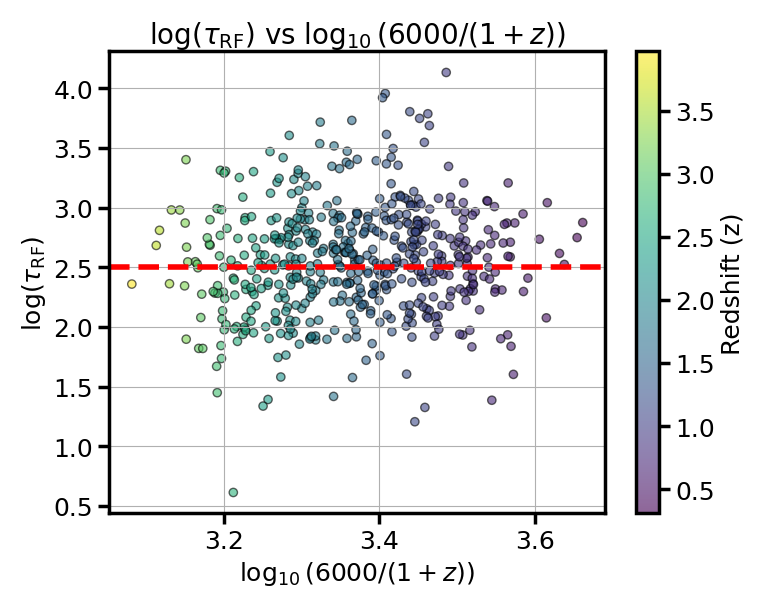

In [216]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log10(6000 / (1 + df['z'])), df['log_tau_RF'], c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(2.5, color='red', linestyle='--', label='y=2.5')
plt.xlabel(r'$\log_{10}(6000 / (1 + z))$')
plt.ylabel(r'$\log(\tau_\mathrm{RF})$')
plt.title(r'$\log(\tau_\mathrm{RF})$ vs $\log_{10}(6000 / (1 + z))$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.show()

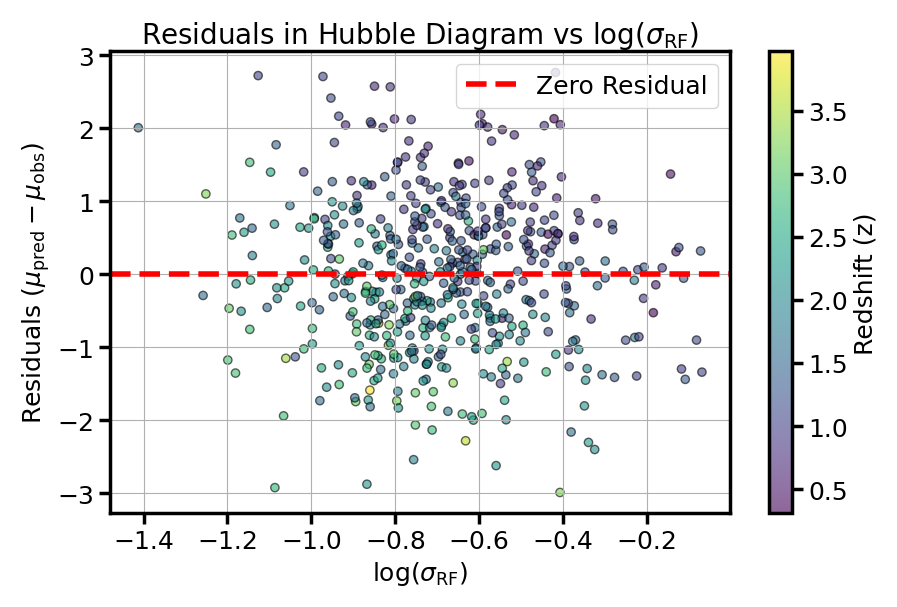

In [217]:
import matplotlib.pyplot as plt

# Plot residuals vs log_sigma_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['log_sigma_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\sigma_\mathrm{RF})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\sigma_\mathrm{RF})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

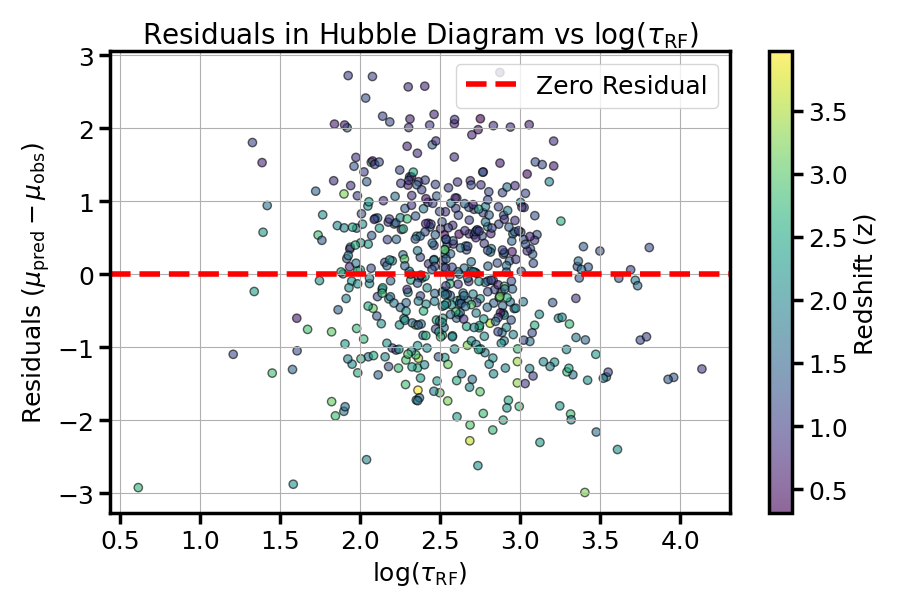

In [218]:
import matplotlib.pyplot as plt

# Plot residuals vs log_tau_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['log_tau_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\tau_\mathrm{RF})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\tau_\mathrm{RF})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

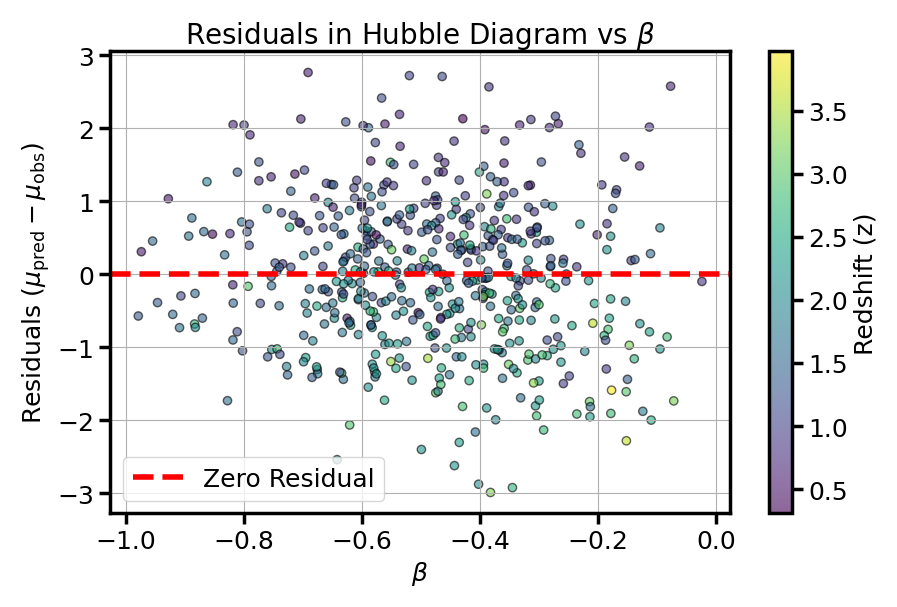

In [219]:

# Plot residuals vs log_tau_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['beta'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\beta$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\beta$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

In [1082]:
sources_with_z_less_than_06 = df[df['z'] < 0.6][['ra', 'dec','z']]
sources_with_z_less_than_06

,ra,dec,z
object_id,,,
1430391,11.569514,0.046980,0.453178
1431275,10.910578,-0.970732,0.559245
1431381,10.832262,0.854283,0.308437
1431568,10.710597,1.034973,0.599872
1431720,10.602207,-1.026508,0.457285
1432767,9.838880,-1.163893,0.487745
1433450,9.332688,1.187379,0.401598
1433727,9.112441,0.217707,0.561256
1433910,8.985889,0.179654,0.330466


In [1083]:
# 1431381	10.832262	0.854283

ValueError: x and y must be the same size

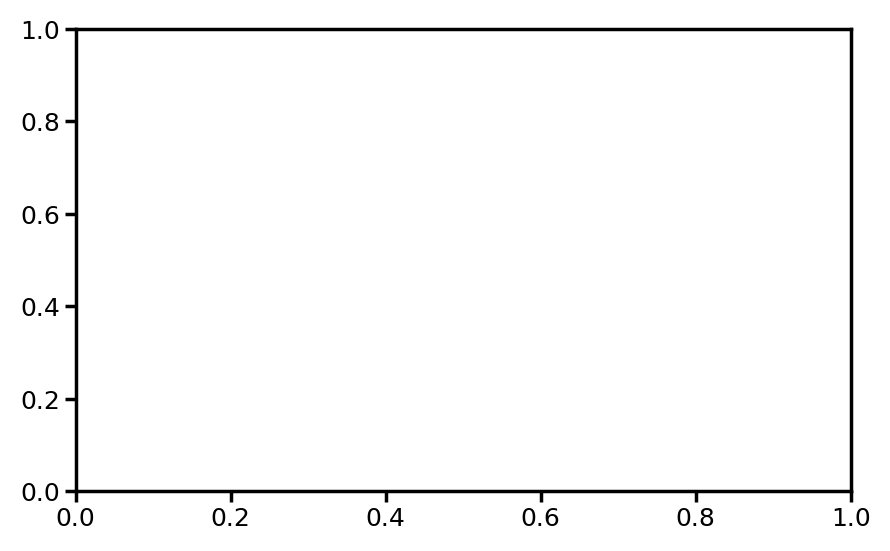

In [204]:
plt.figure(figsize=(10, 6))
plt.scatter(df['delta_time']/(1+df['z']), residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\Delta \mathrm{Time} RF$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\Delta \mathrm{Time}$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

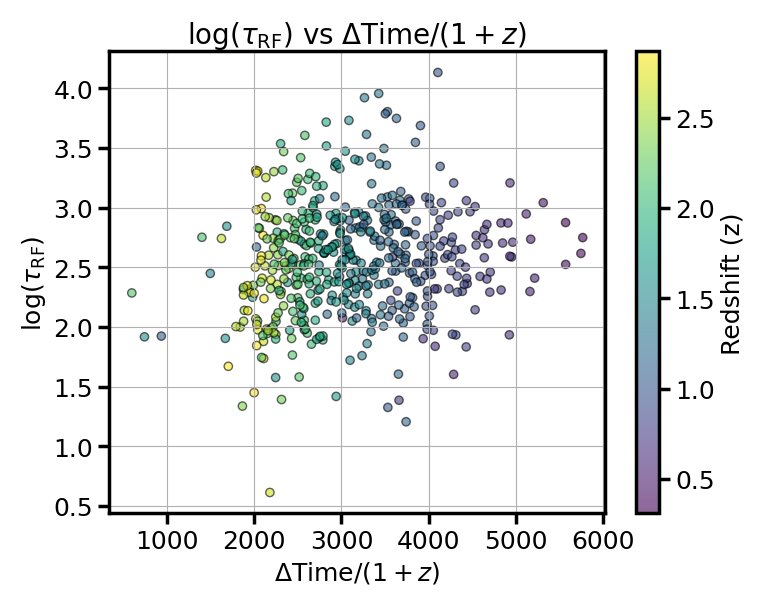

In [1085]:
plt.figure(figsize=(8, 6))
plt.scatter(df['delta_time'] / (1 + df['z']), df['log_tau_RF'], c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.xlabel(r'$\Delta \mathrm{Time} / (1+z)$')
plt.ylabel(r'$\log(\tau_\mathrm{RF})$')
plt.title(r'$\log(\tau_\mathrm{RF})$ vs $\Delta \mathrm{Time} / (1+z)$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.show()

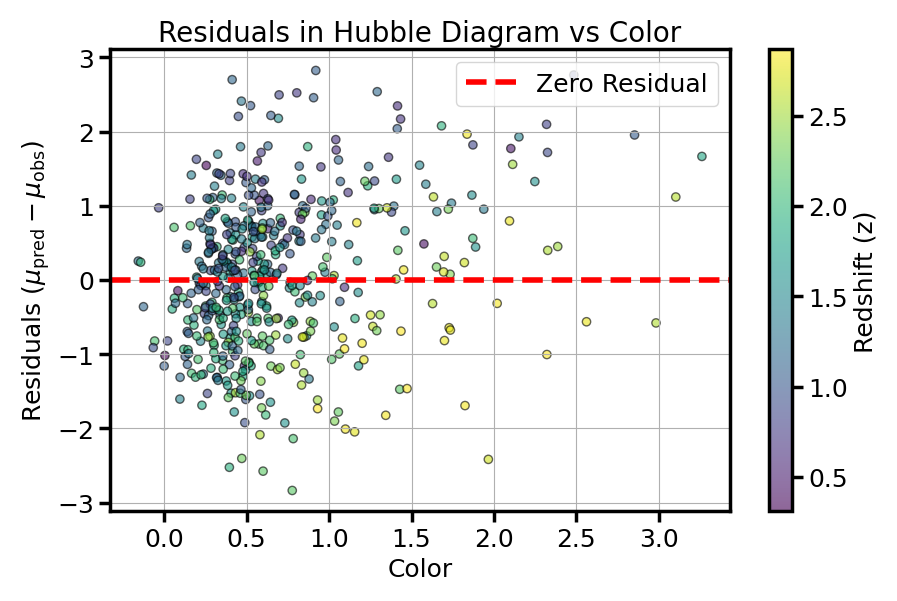

In [1086]:
plt.figure(figsize=(10, 6))
plt.scatter(df['color'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Color')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Color')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

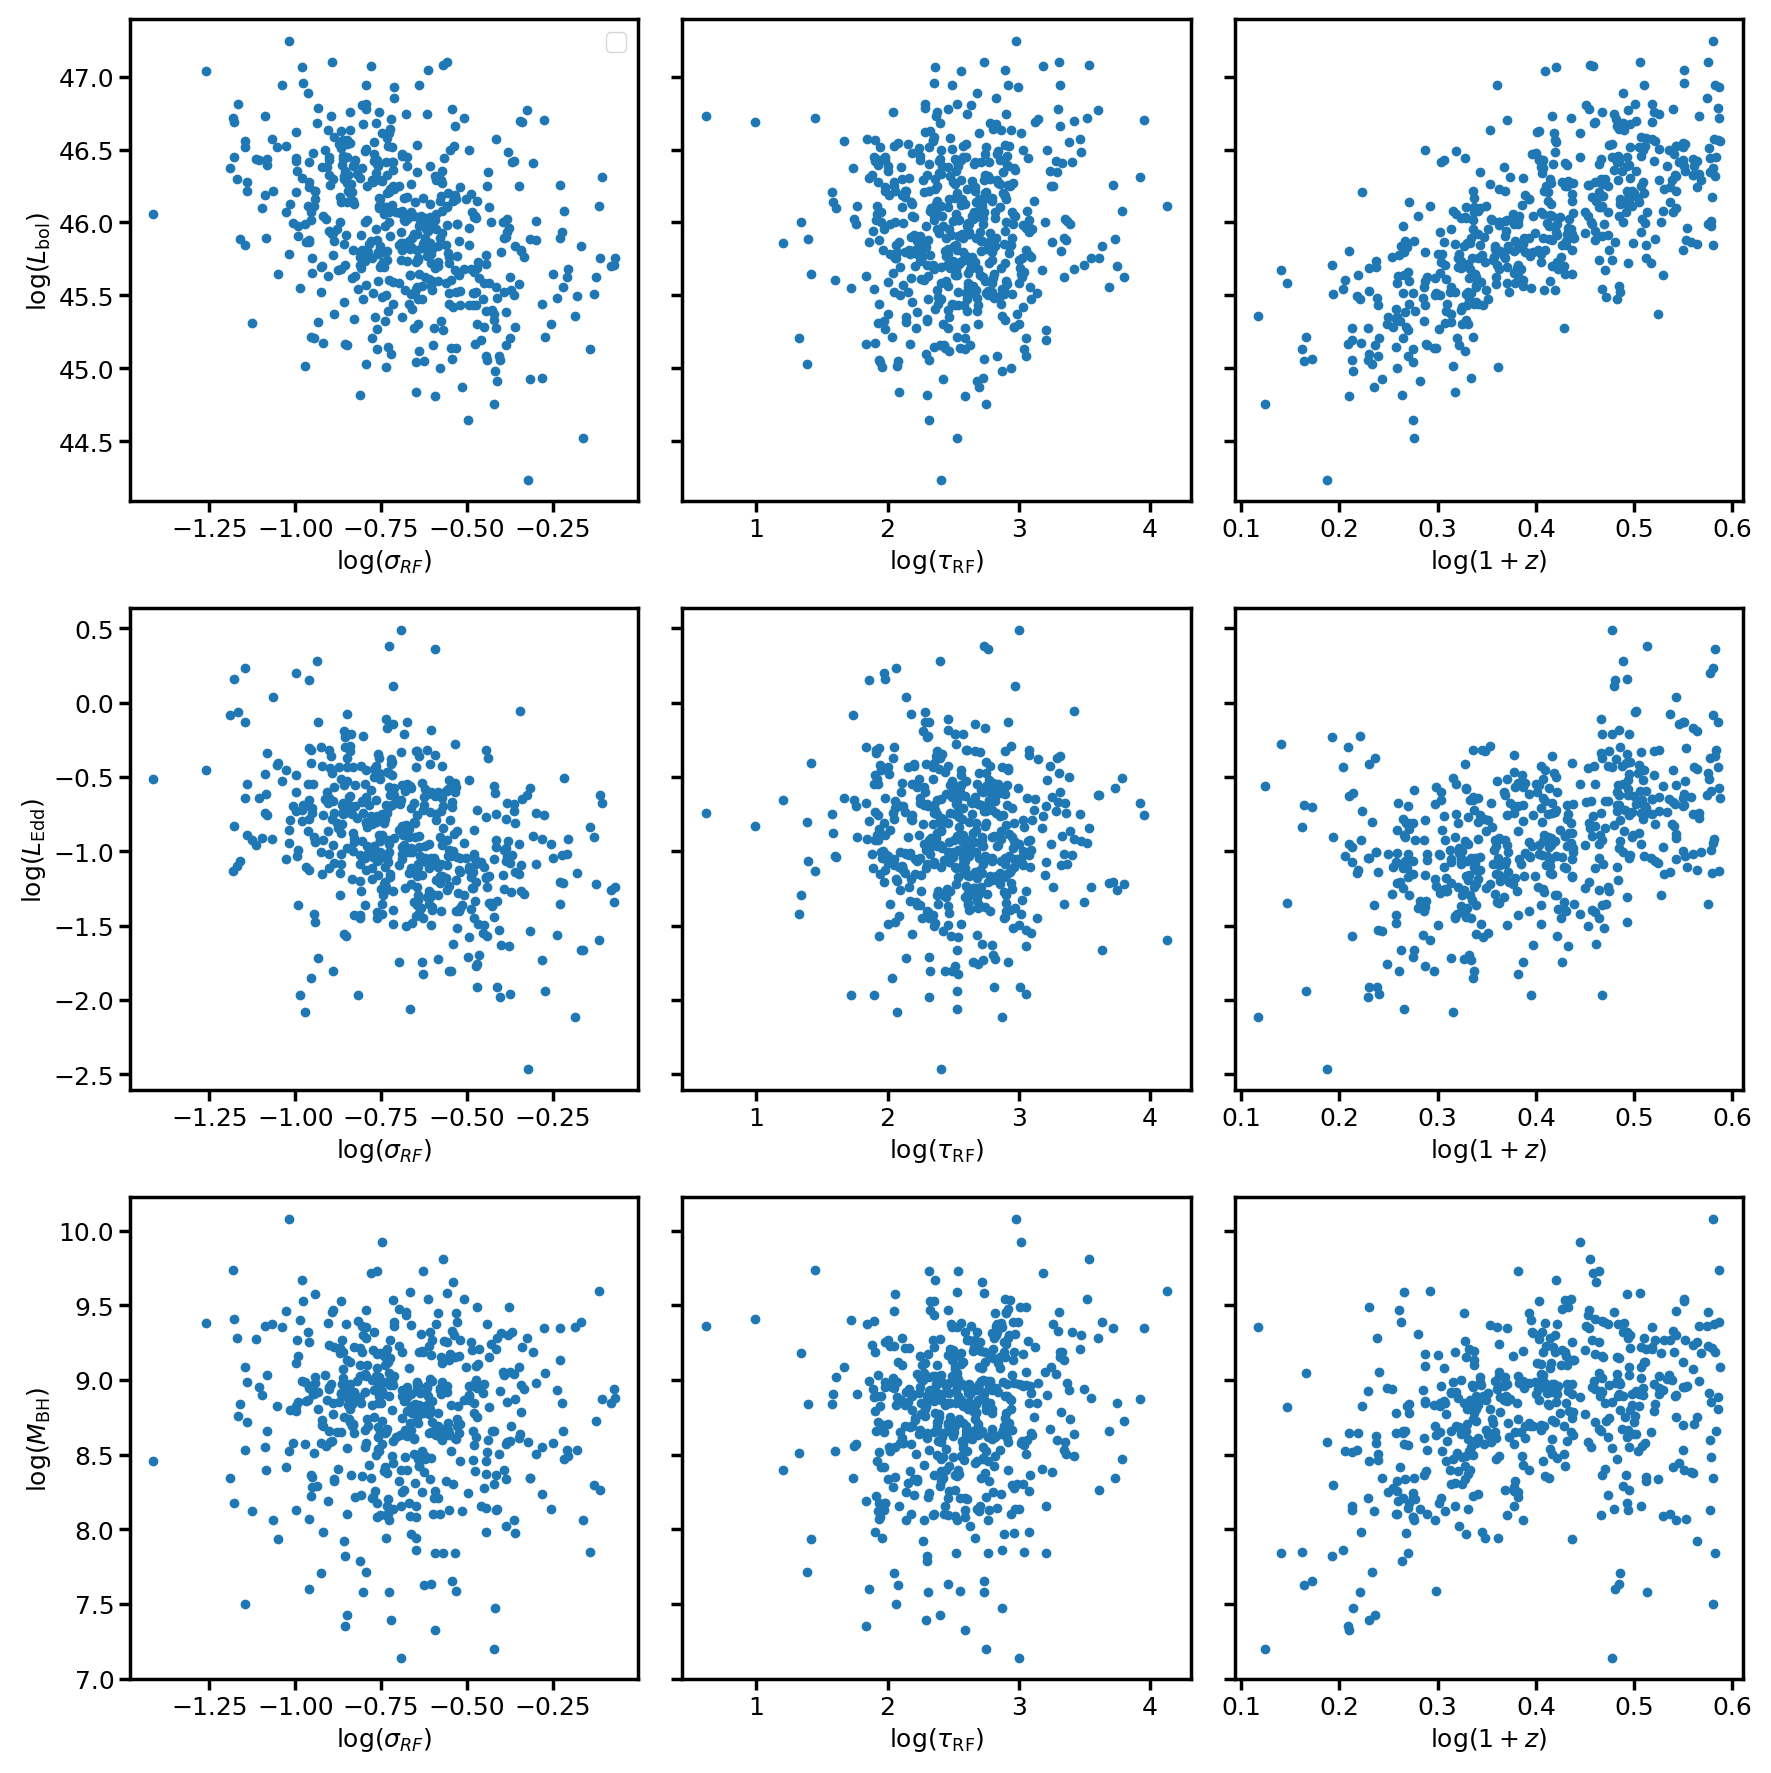

In [ ]:

fig, axs = plt.subplots(3, 3, figsize=(3*6, 3*6), sharey='row')

# First row
ax = axs[0, 0]
#ax.scatter(df['log_sigma'], df['log_lbol'], marker='.')
ax.scatter(df['log_sigma_RF'], df['log_lbol'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
ax.legend()

ax = axs[0, 1]
ax.scatter(df['log_tau_RF'], df['log_lbol'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[0, 2]
ax.scatter(np.log10(1+df['z']), df['log_lbol'])
ax.set_xlabel(r"$\log(1+z)$")

# Second row
ax = axs[1, 0]
ax.scatter(df['log_sigma_RF'], df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{Edd})$")

ax = axs[1, 1]
ax.scatter(df['log_tau_RF'], df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[1, 2]
ax.scatter(np.log10(1+df['z']), df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(1+z)$")

# Third row
ax = axs[2, 0]
ax.scatter(df['log_sigma_RF'], df['log_mbh'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(M_\mathrm{BH})$")

ax = axs[2, 1]
ax.scatter(df['log_tau_RF'], df['log_mbh'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[2, 2]
ax.scatter(np.log10(1+df['z']), df['log_mbh'])
ax.set_xlabel(r"$\log(1+z)$")

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
x

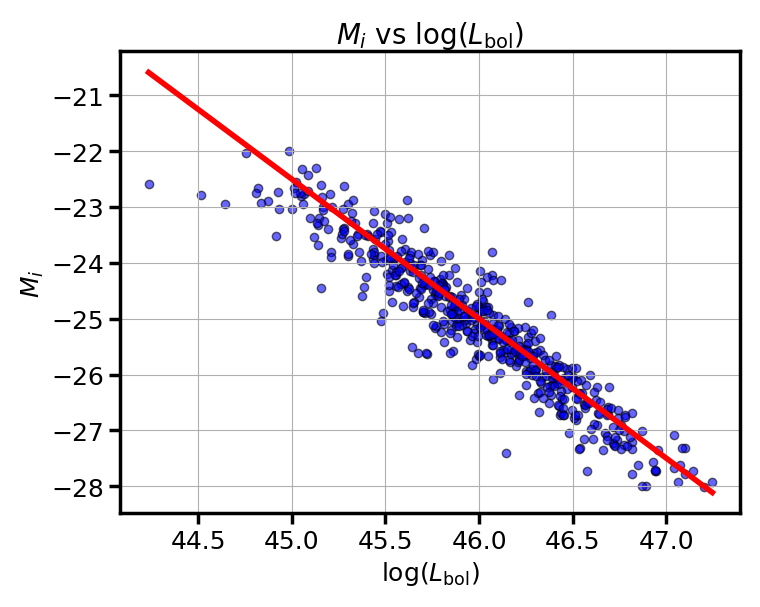

In [207]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_lbol'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
x = np.linspace(df['log_lbol'].min(), df['log_lbol'].max(), 100)
y = -2.5 * x + 90
plt.plot(x, y, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel(r"$\log(L_\mathrm{bol})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(L_\mathrm{bol})$")
plt.grid(True)
plt.show()

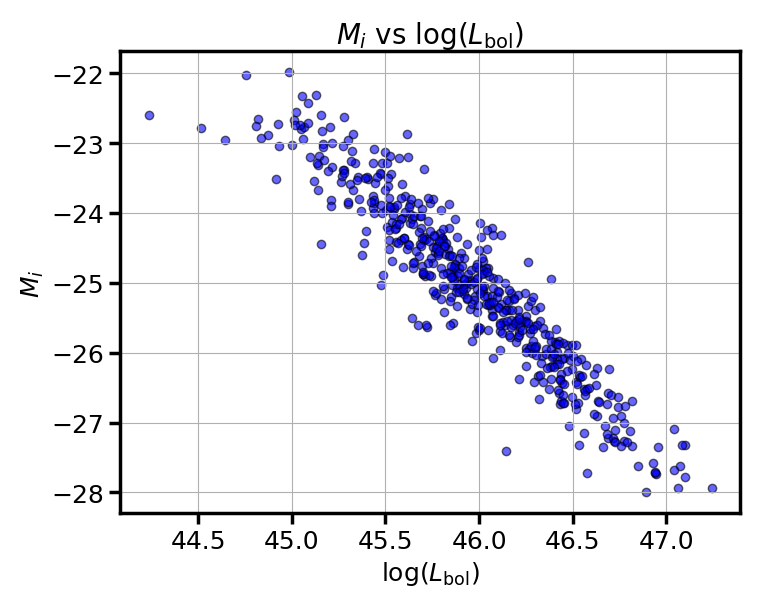

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_lbol'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
x = np.linspace(df['log_lbol'].min(), df['log_lbol'].max(), 100)
y = -2.5 * x - 90
plt.plot(x, y, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel(r"$\log(L_\mathrm{bol})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(L_\mathrm{bol})$")
plt.grid(True)
plt.show()

Plotting for range: 0.00 to 0.05


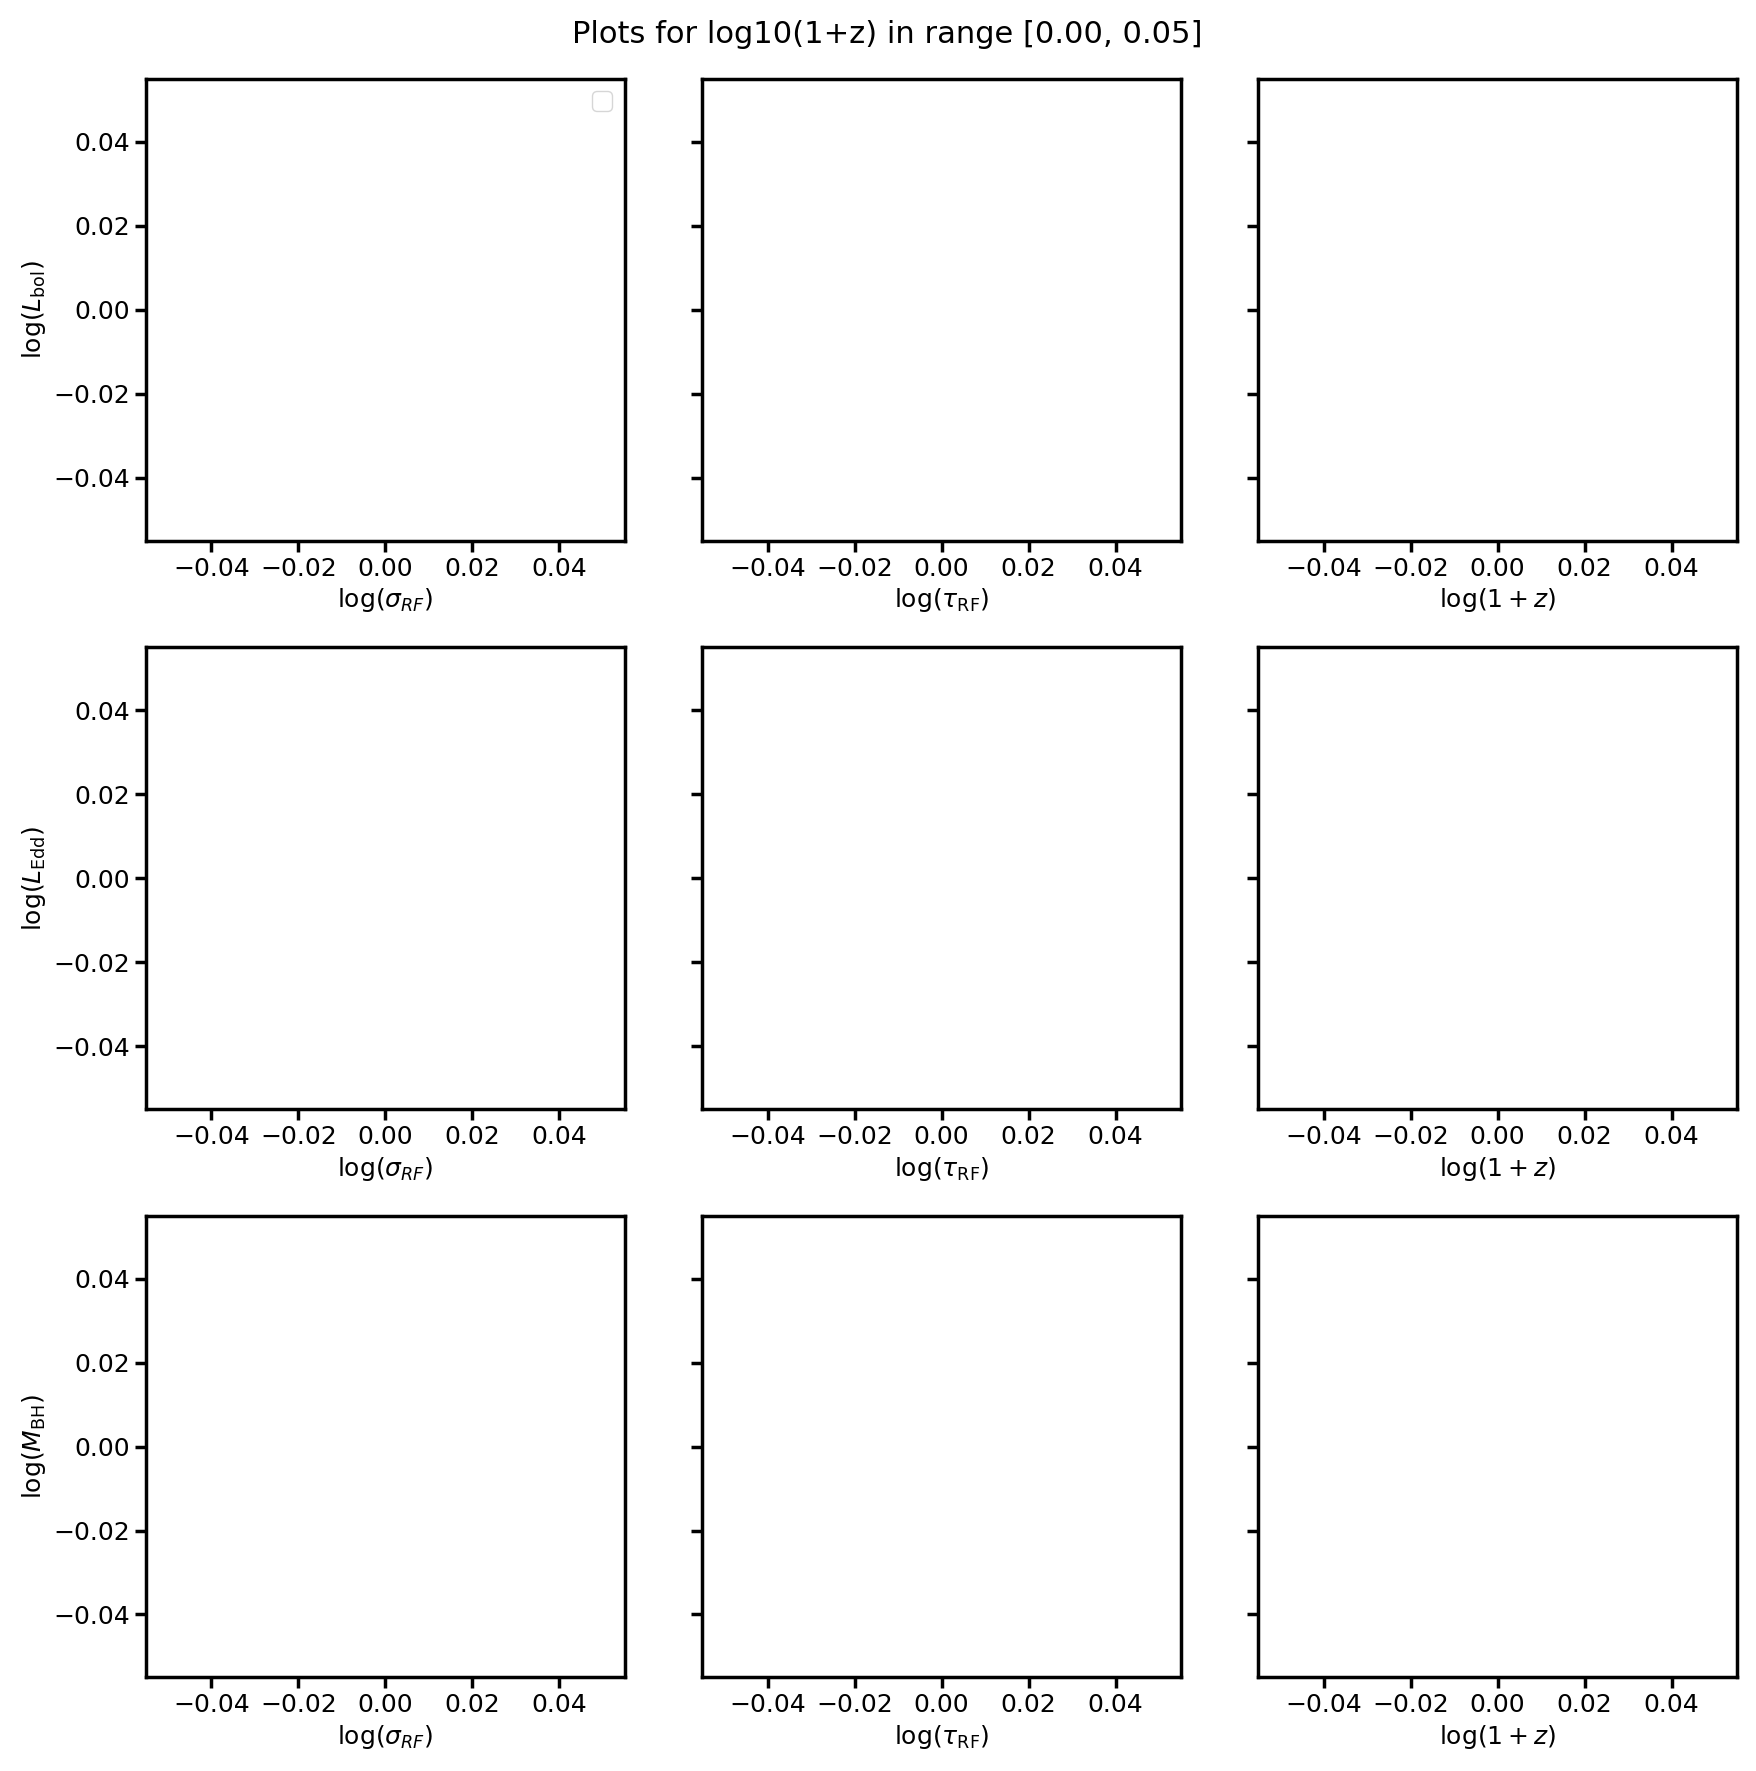

Plotting for range: 0.05 to 0.10


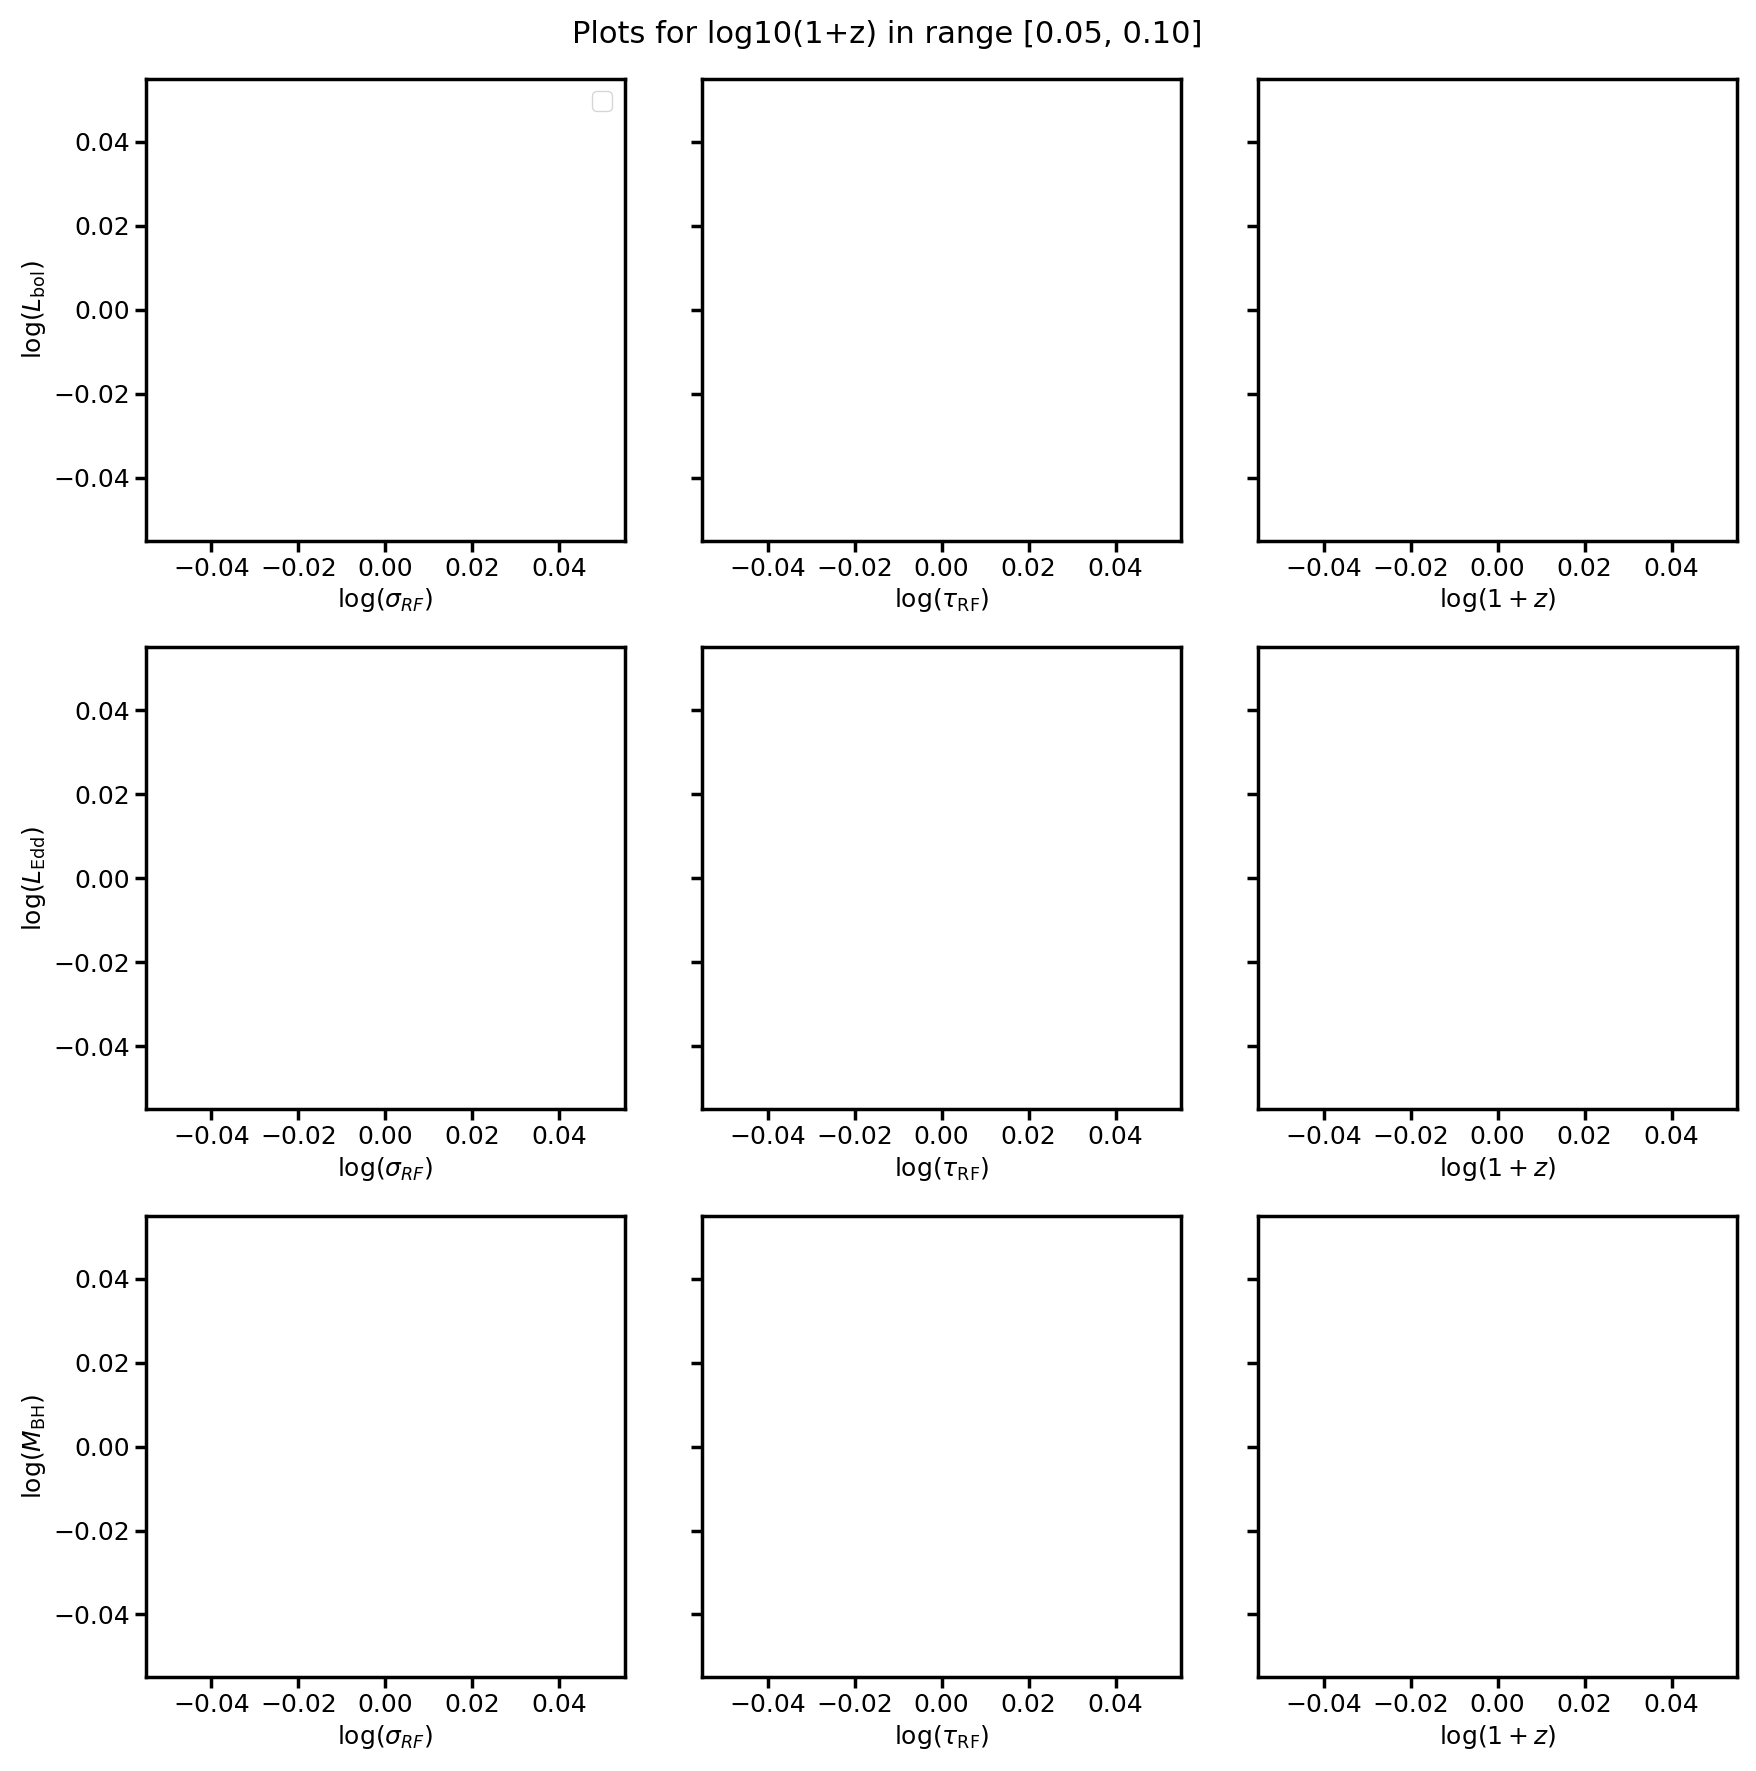

Plotting for range: 0.10 to 0.15


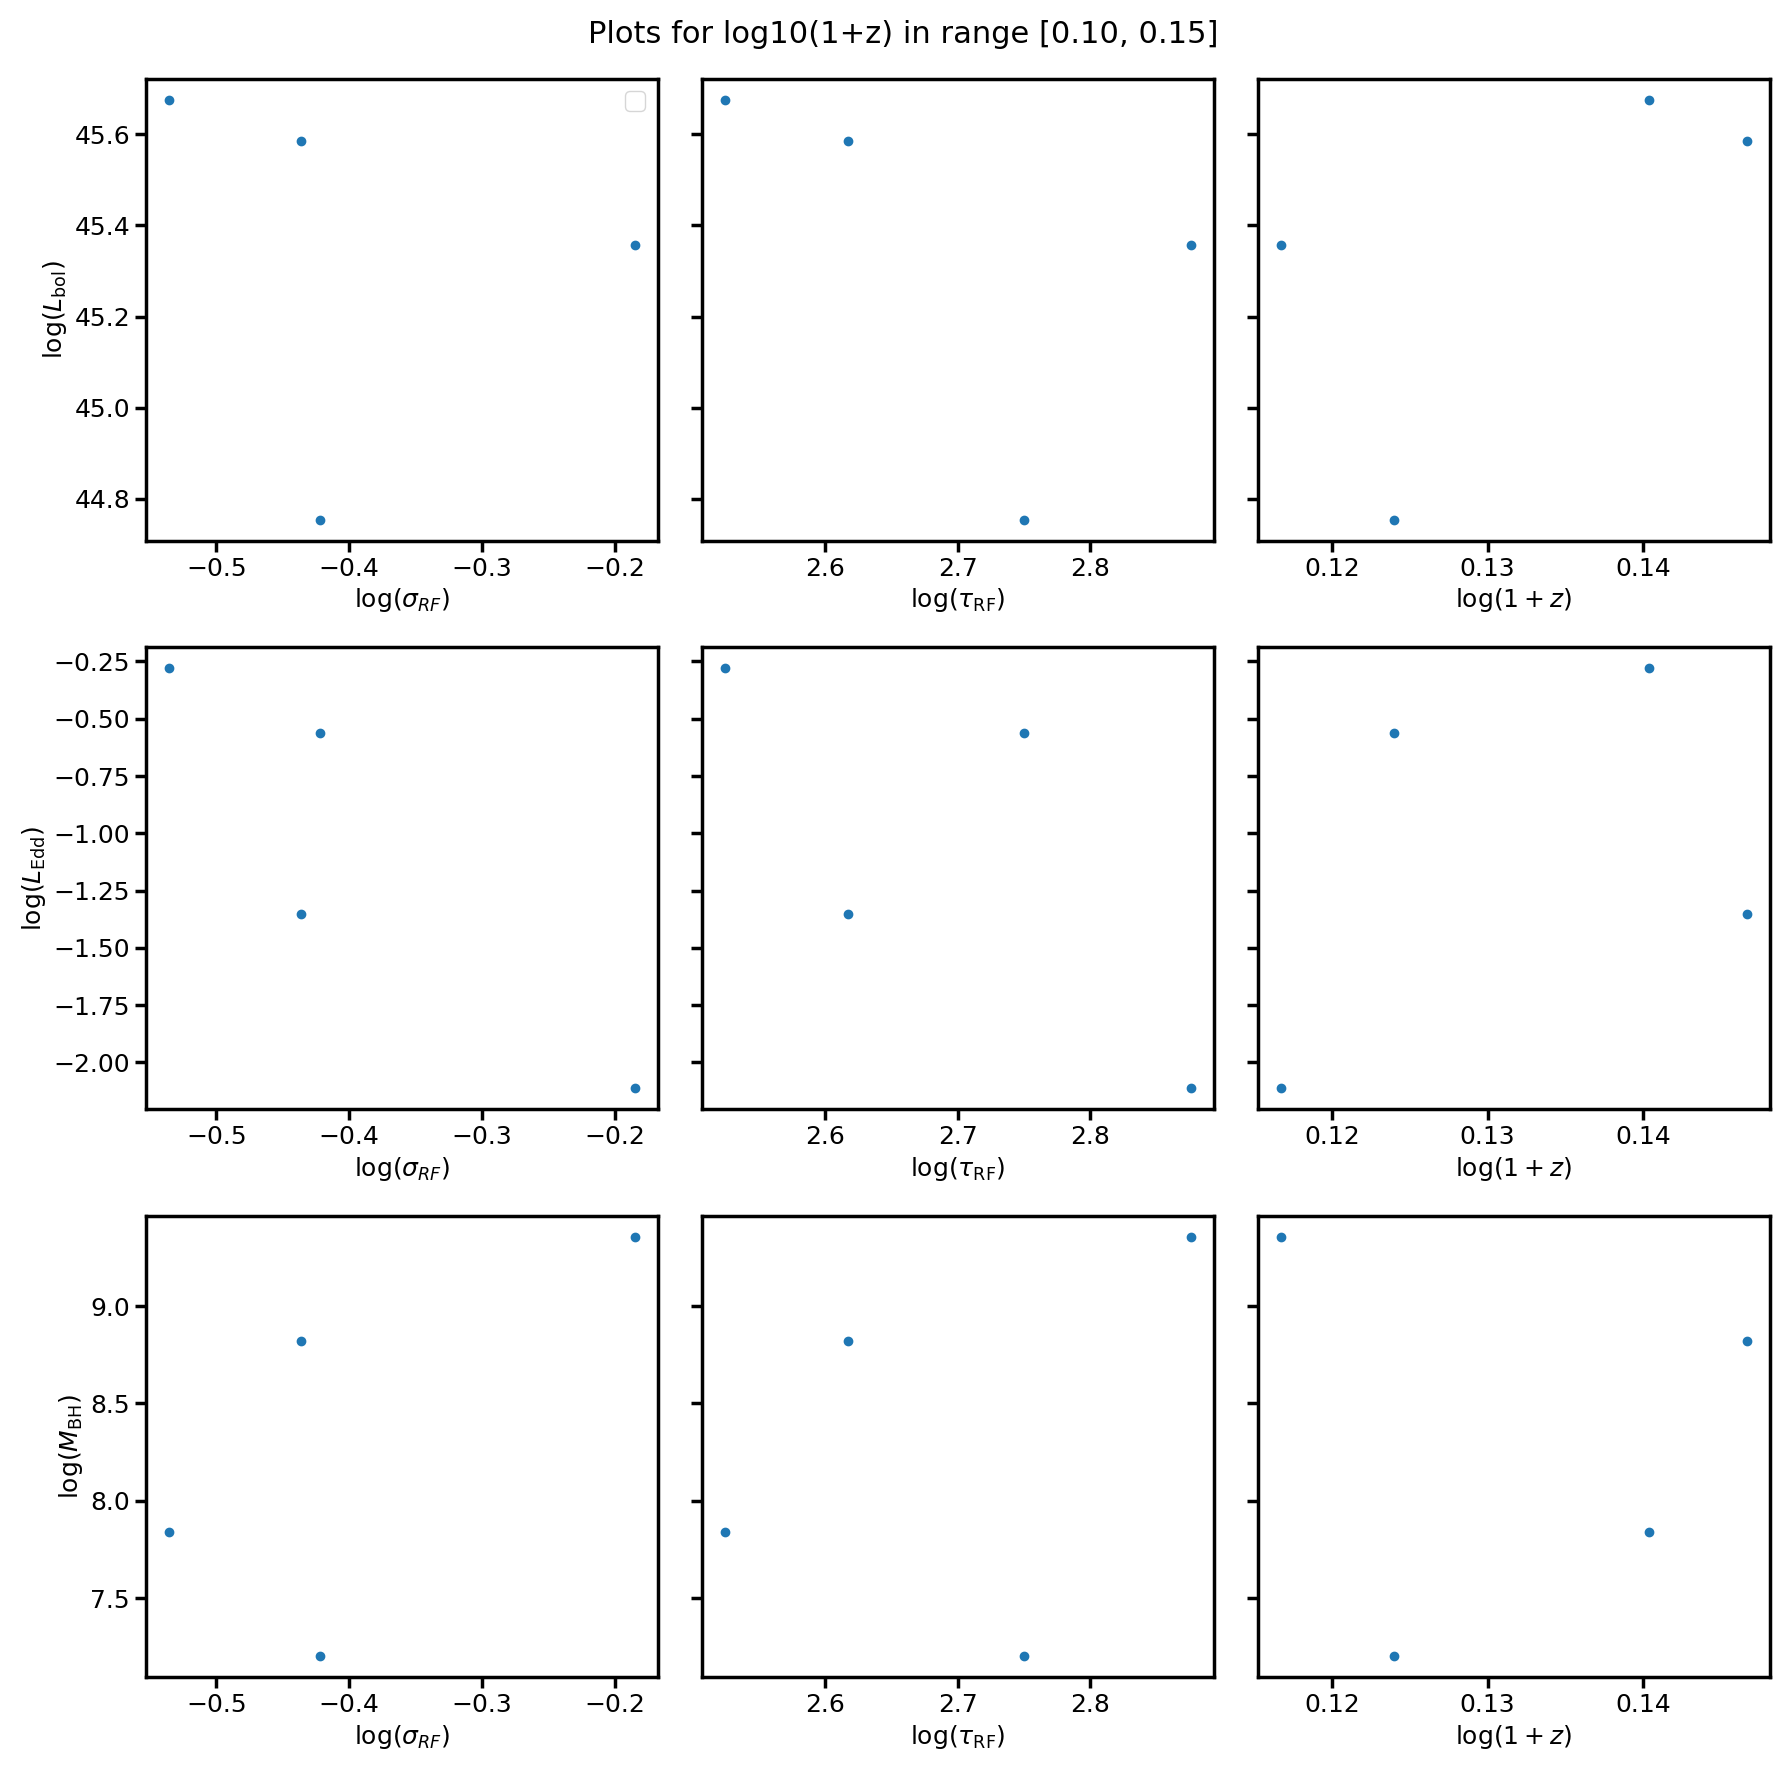

Plotting for range: 0.15 to 0.20


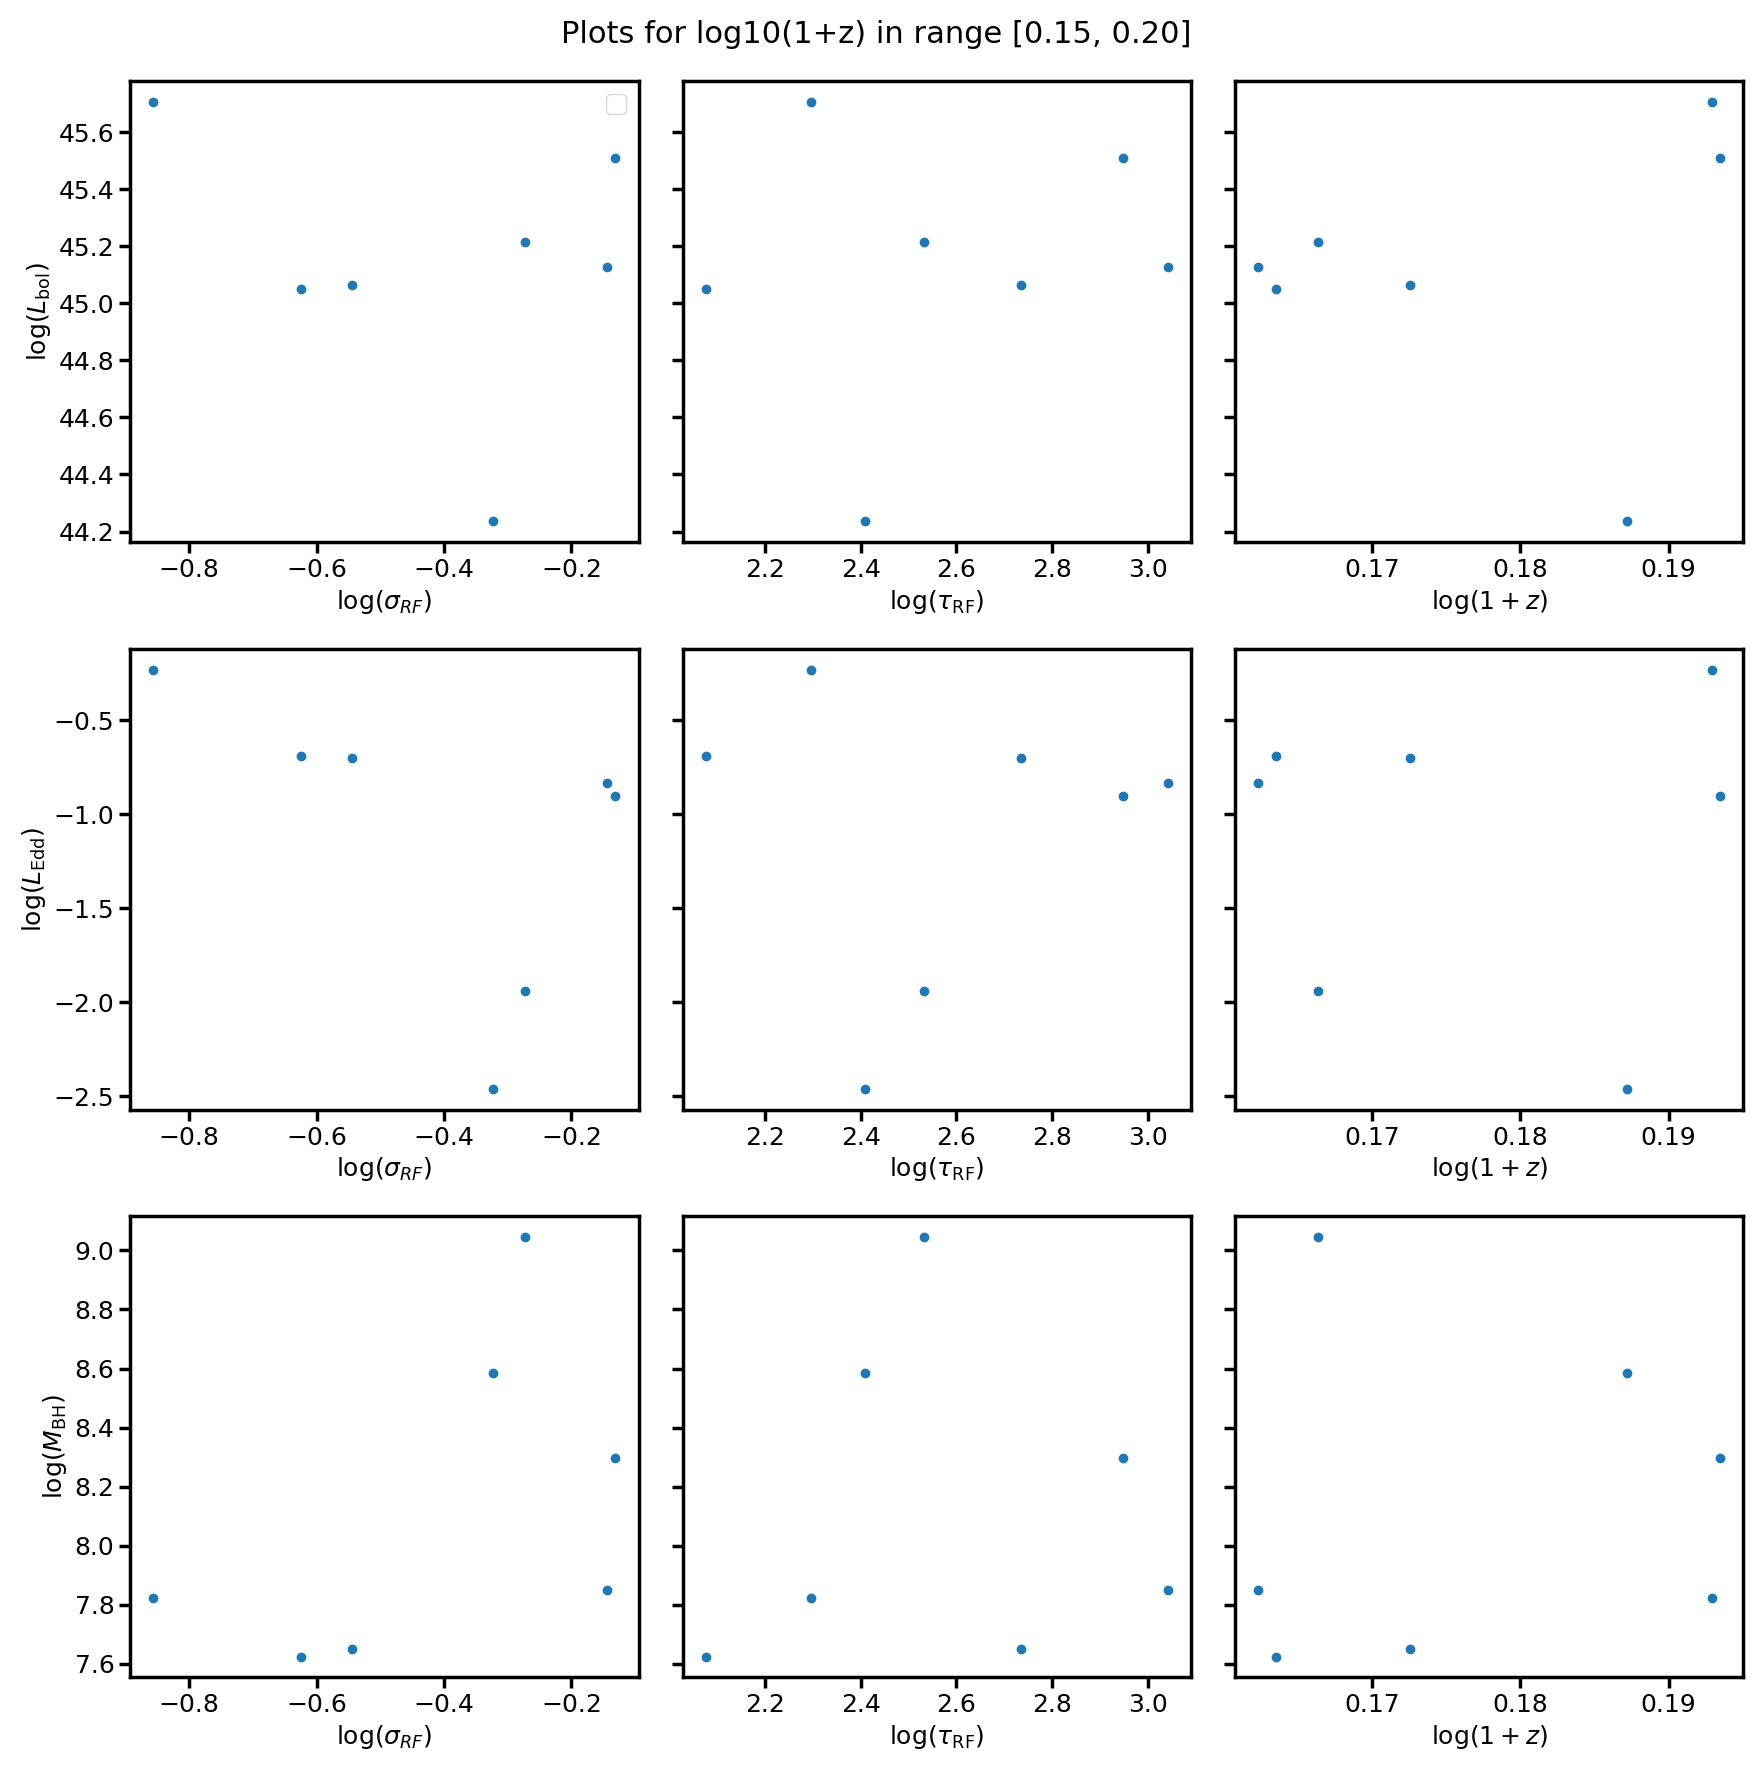

Plotting for range: 0.20 to 0.25


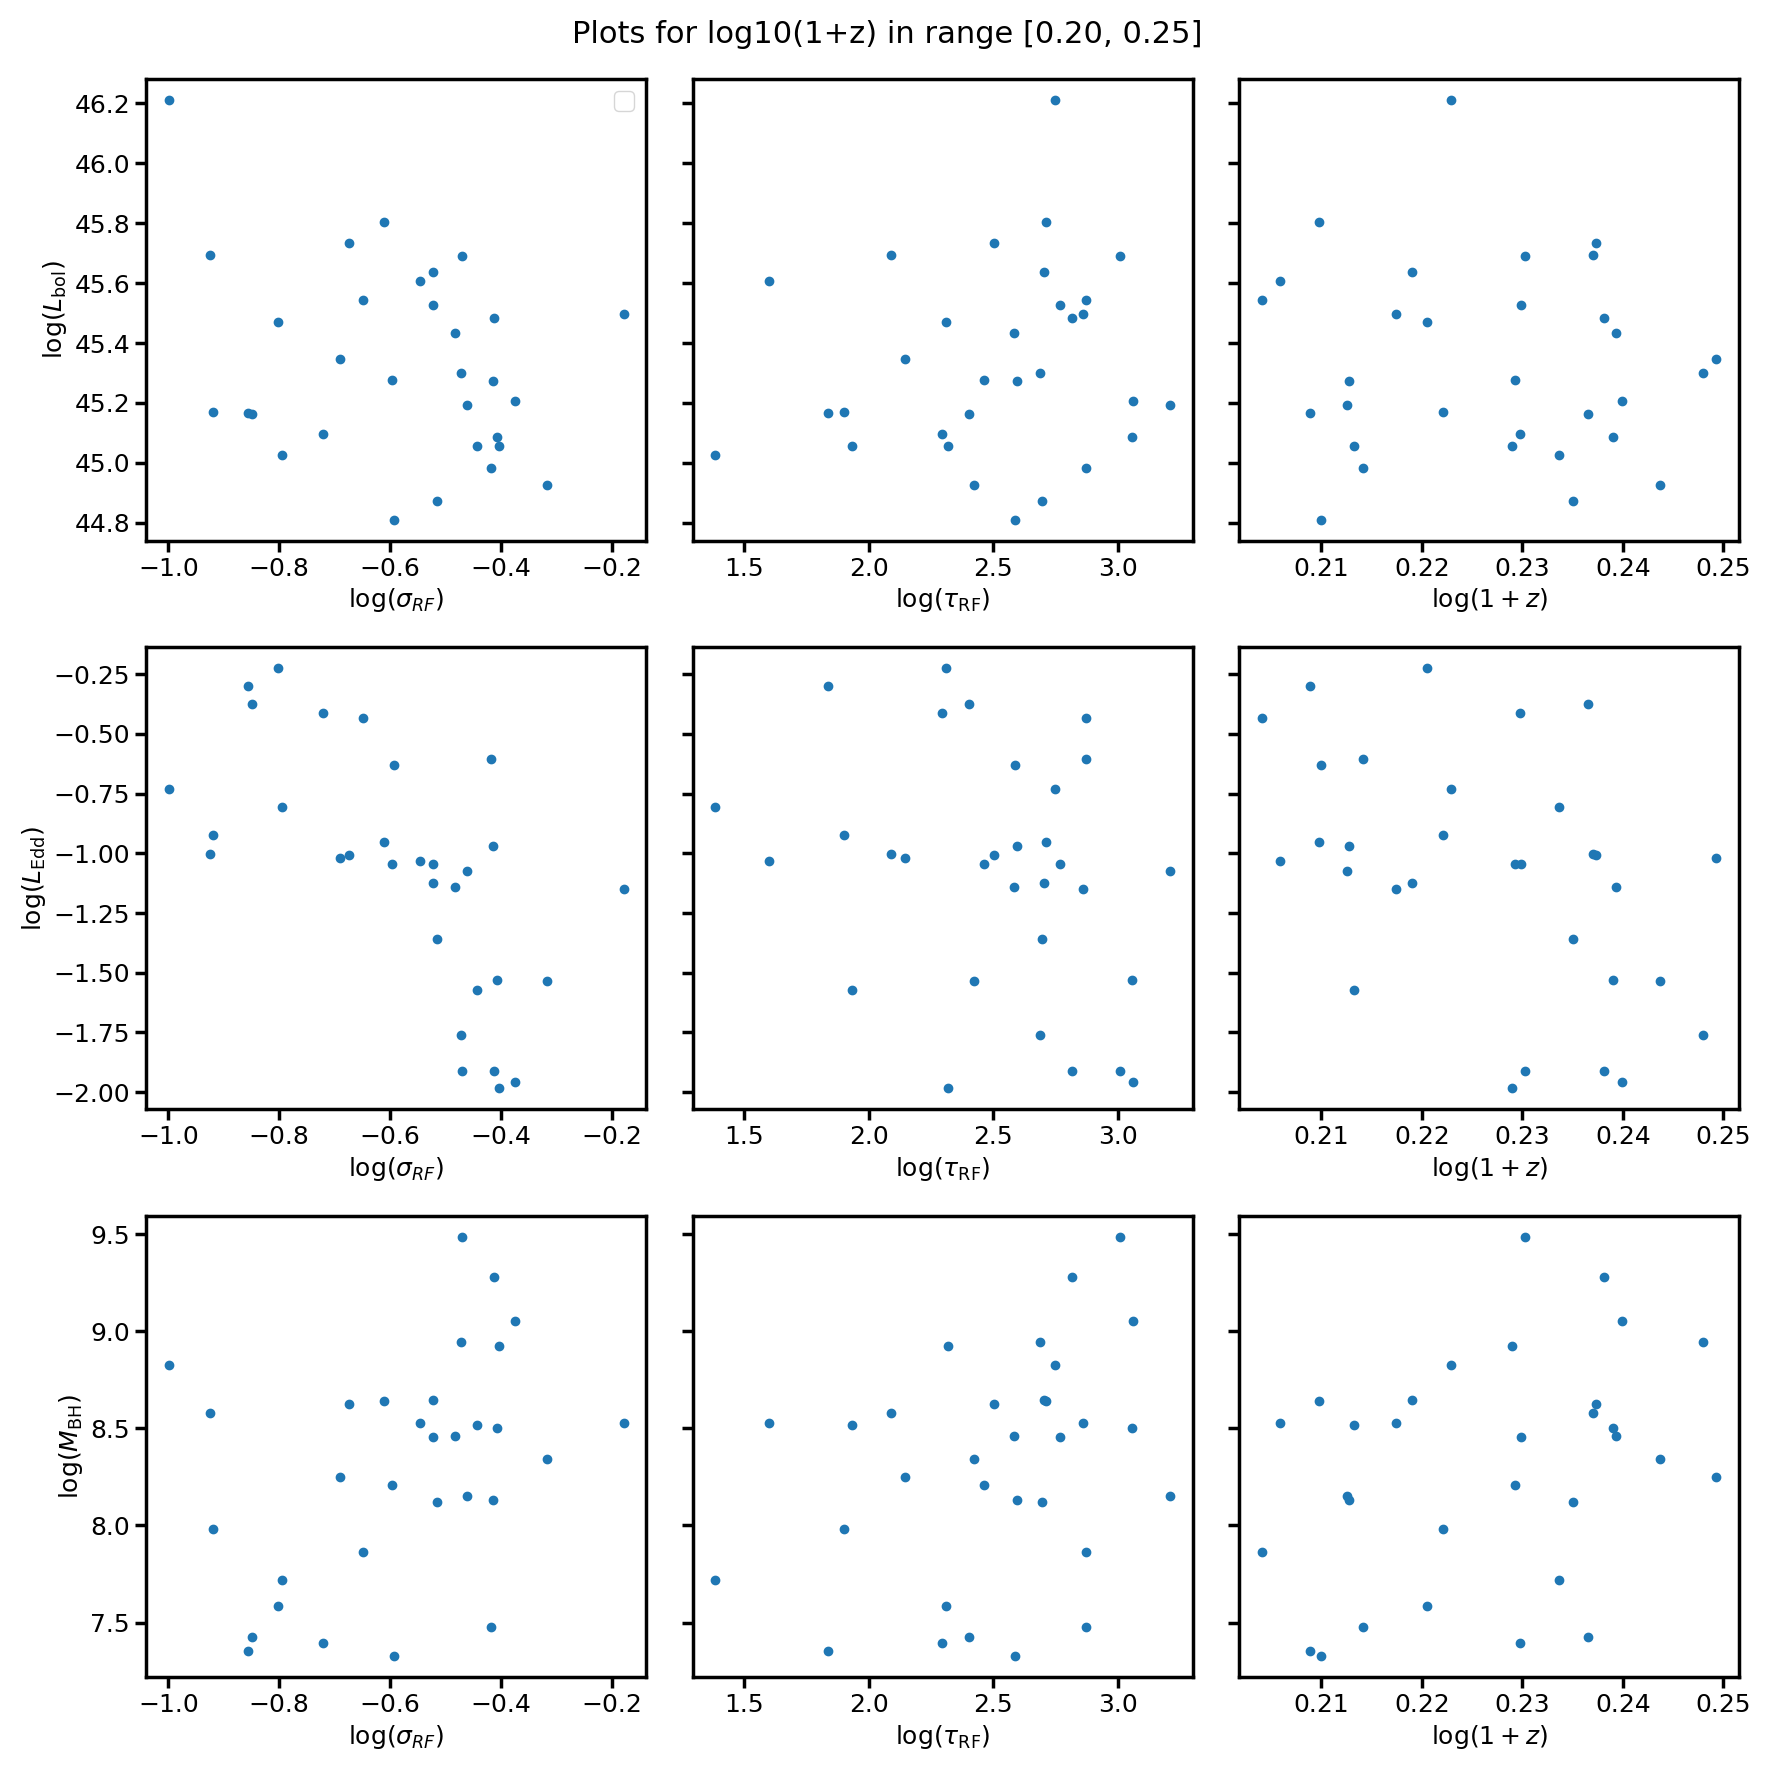

Plotting for range: 0.25 to 0.30


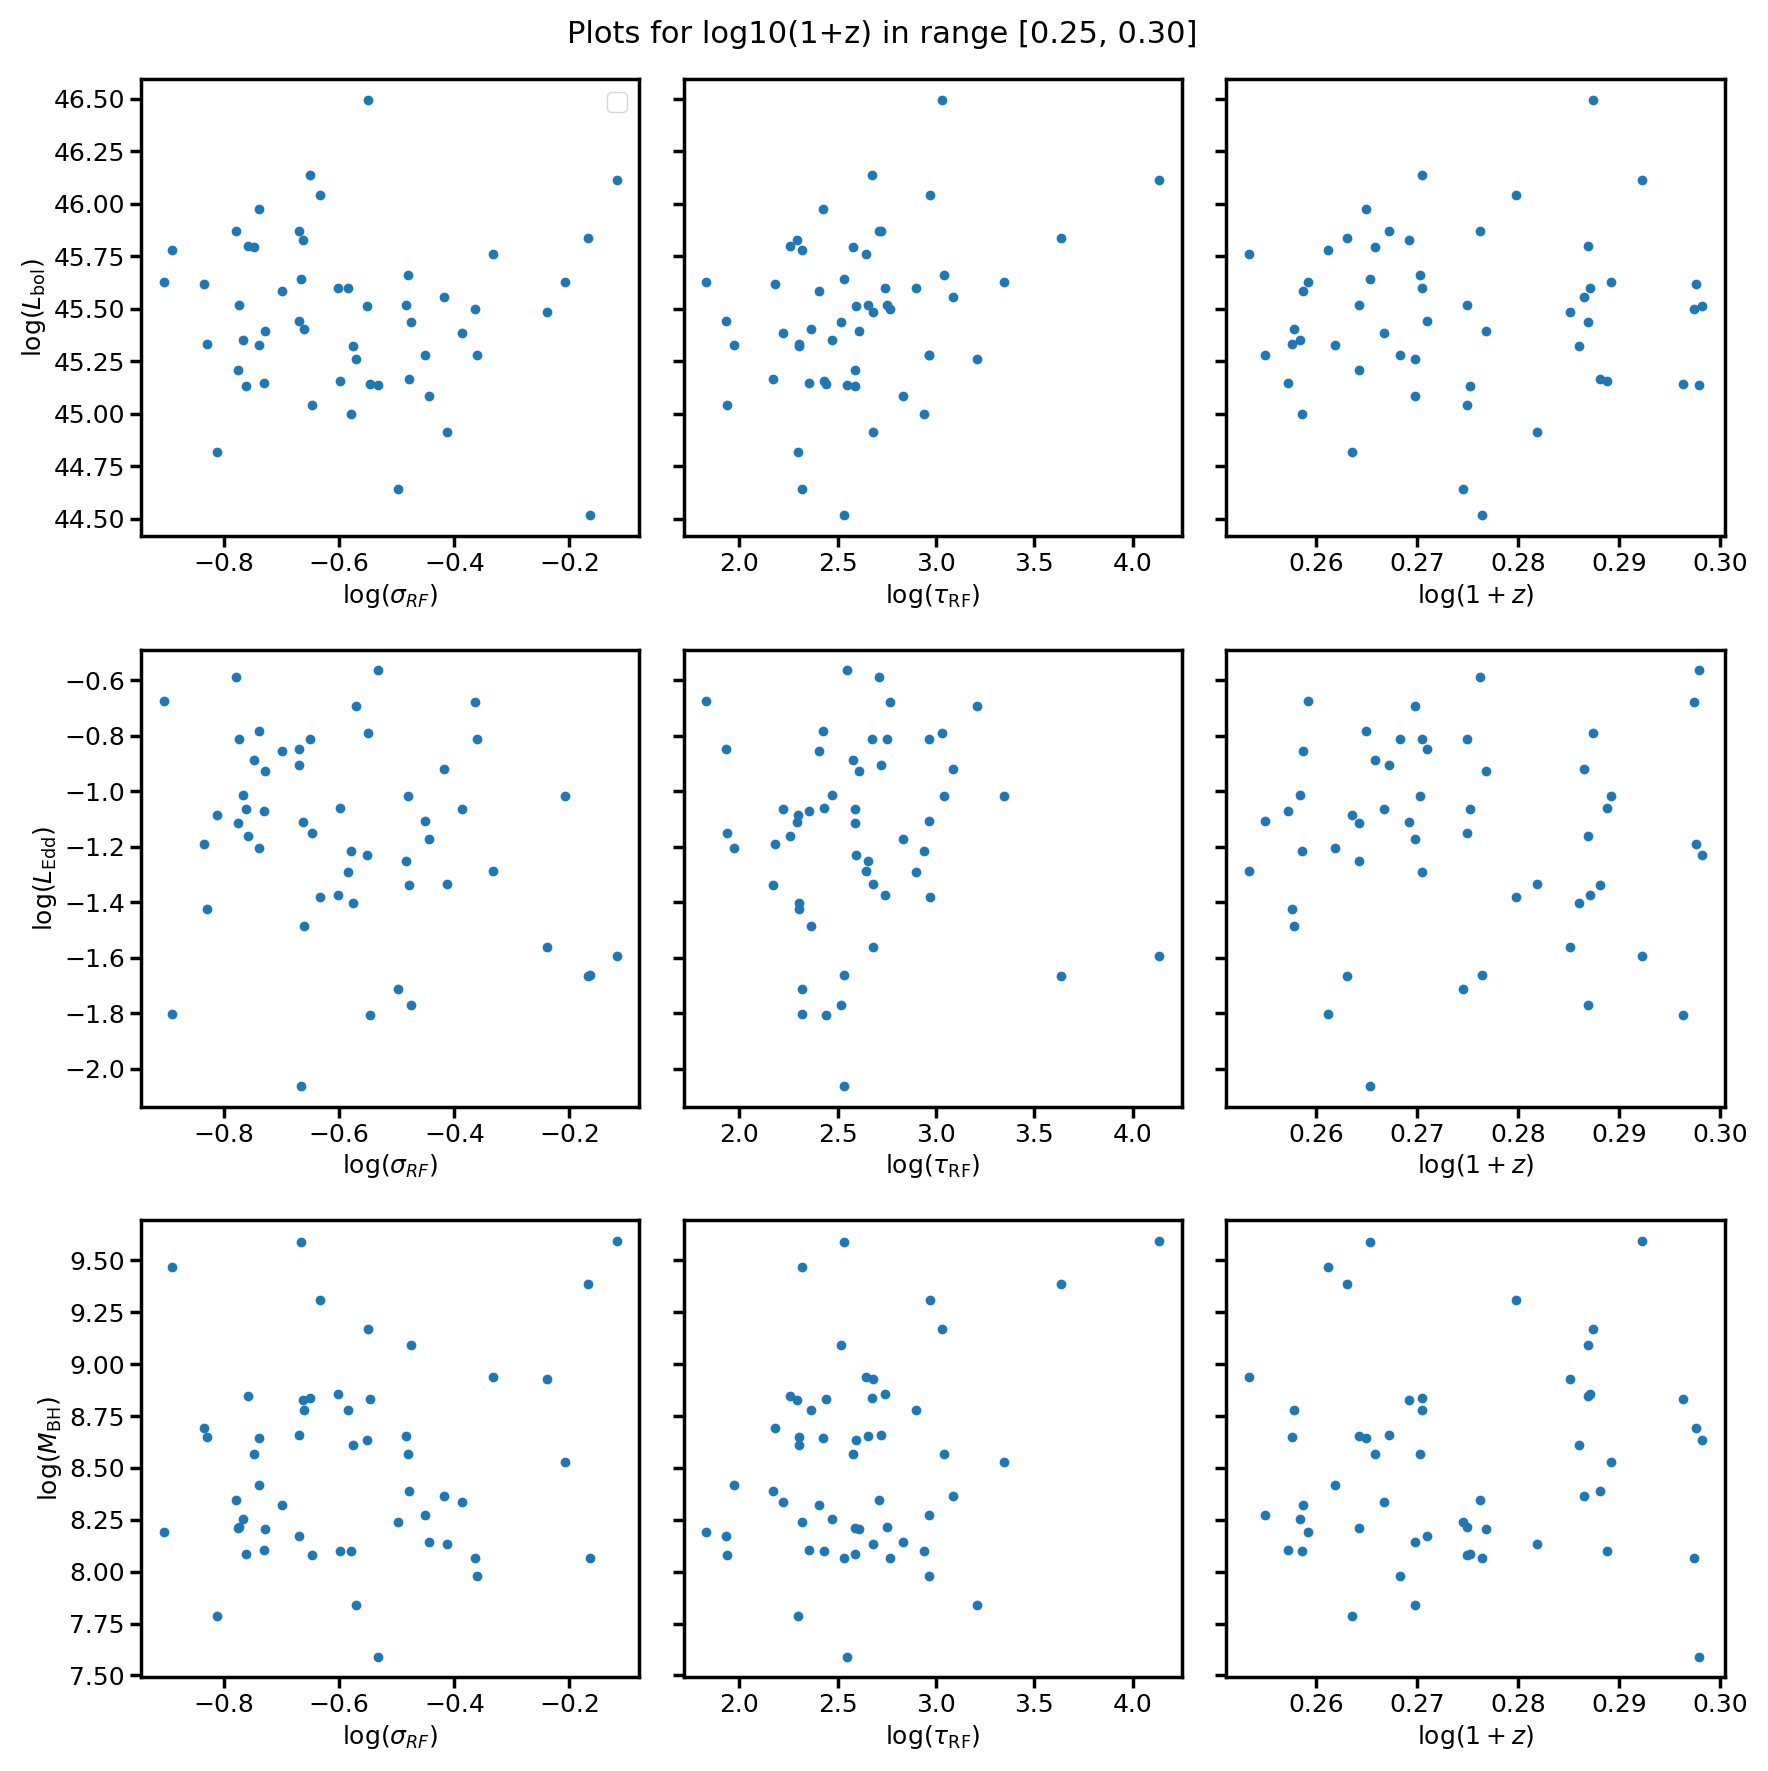

Plotting for range: 0.30 to 0.35


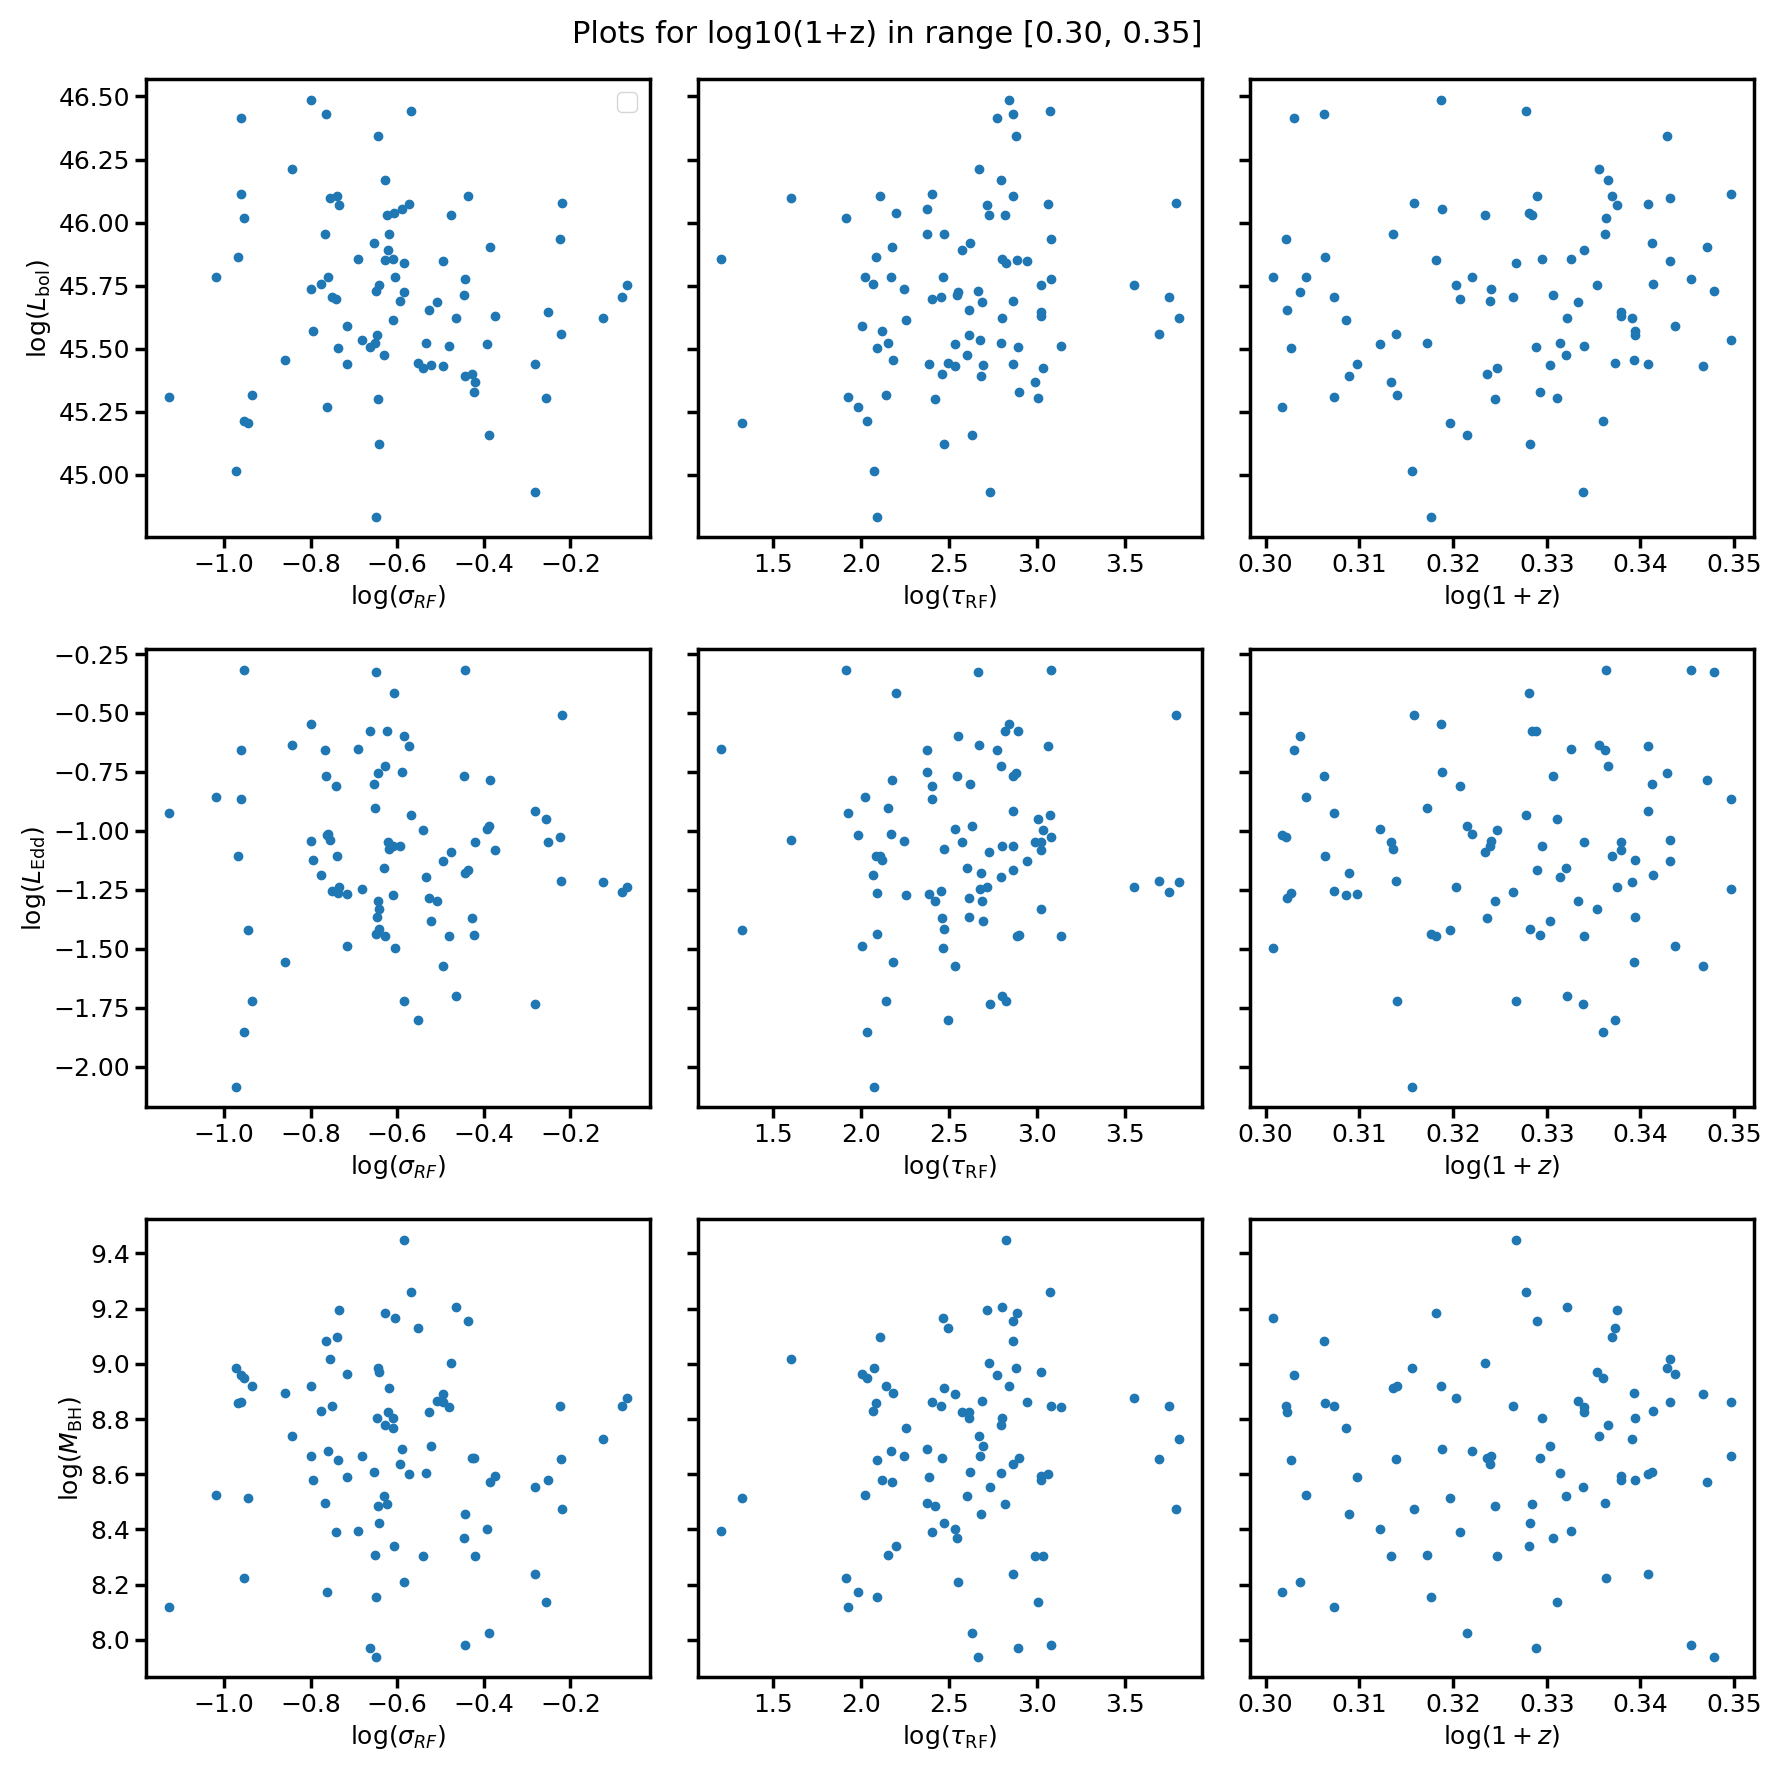

Plotting for range: 0.35 to 0.40


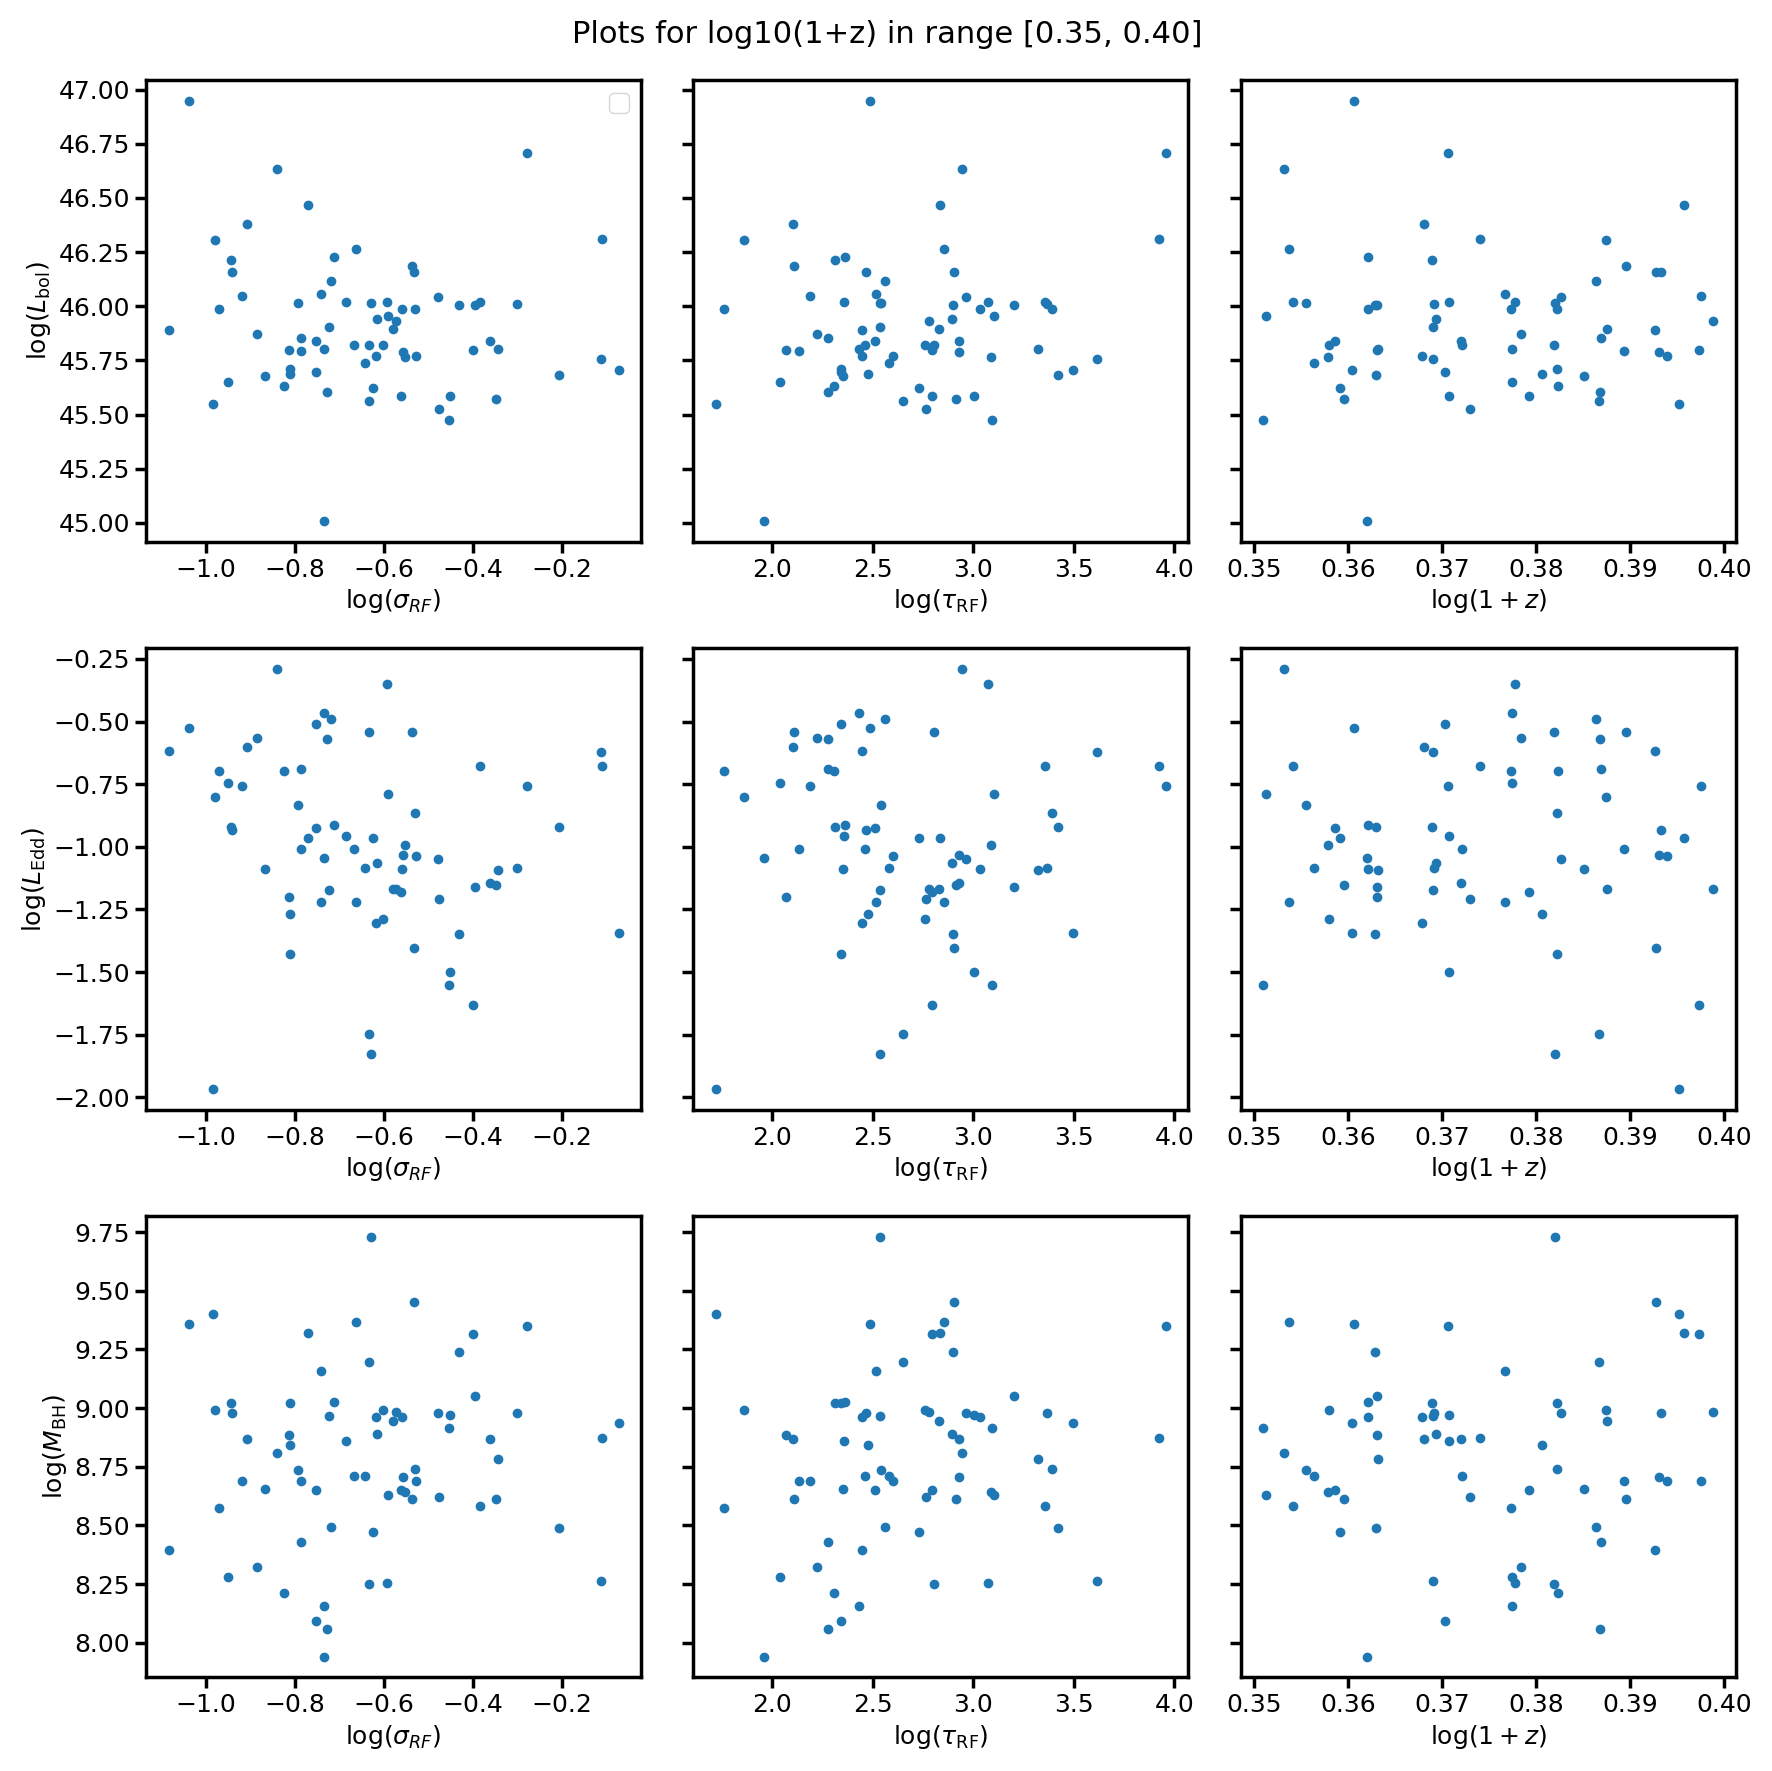

Plotting for range: 0.40 to 0.45


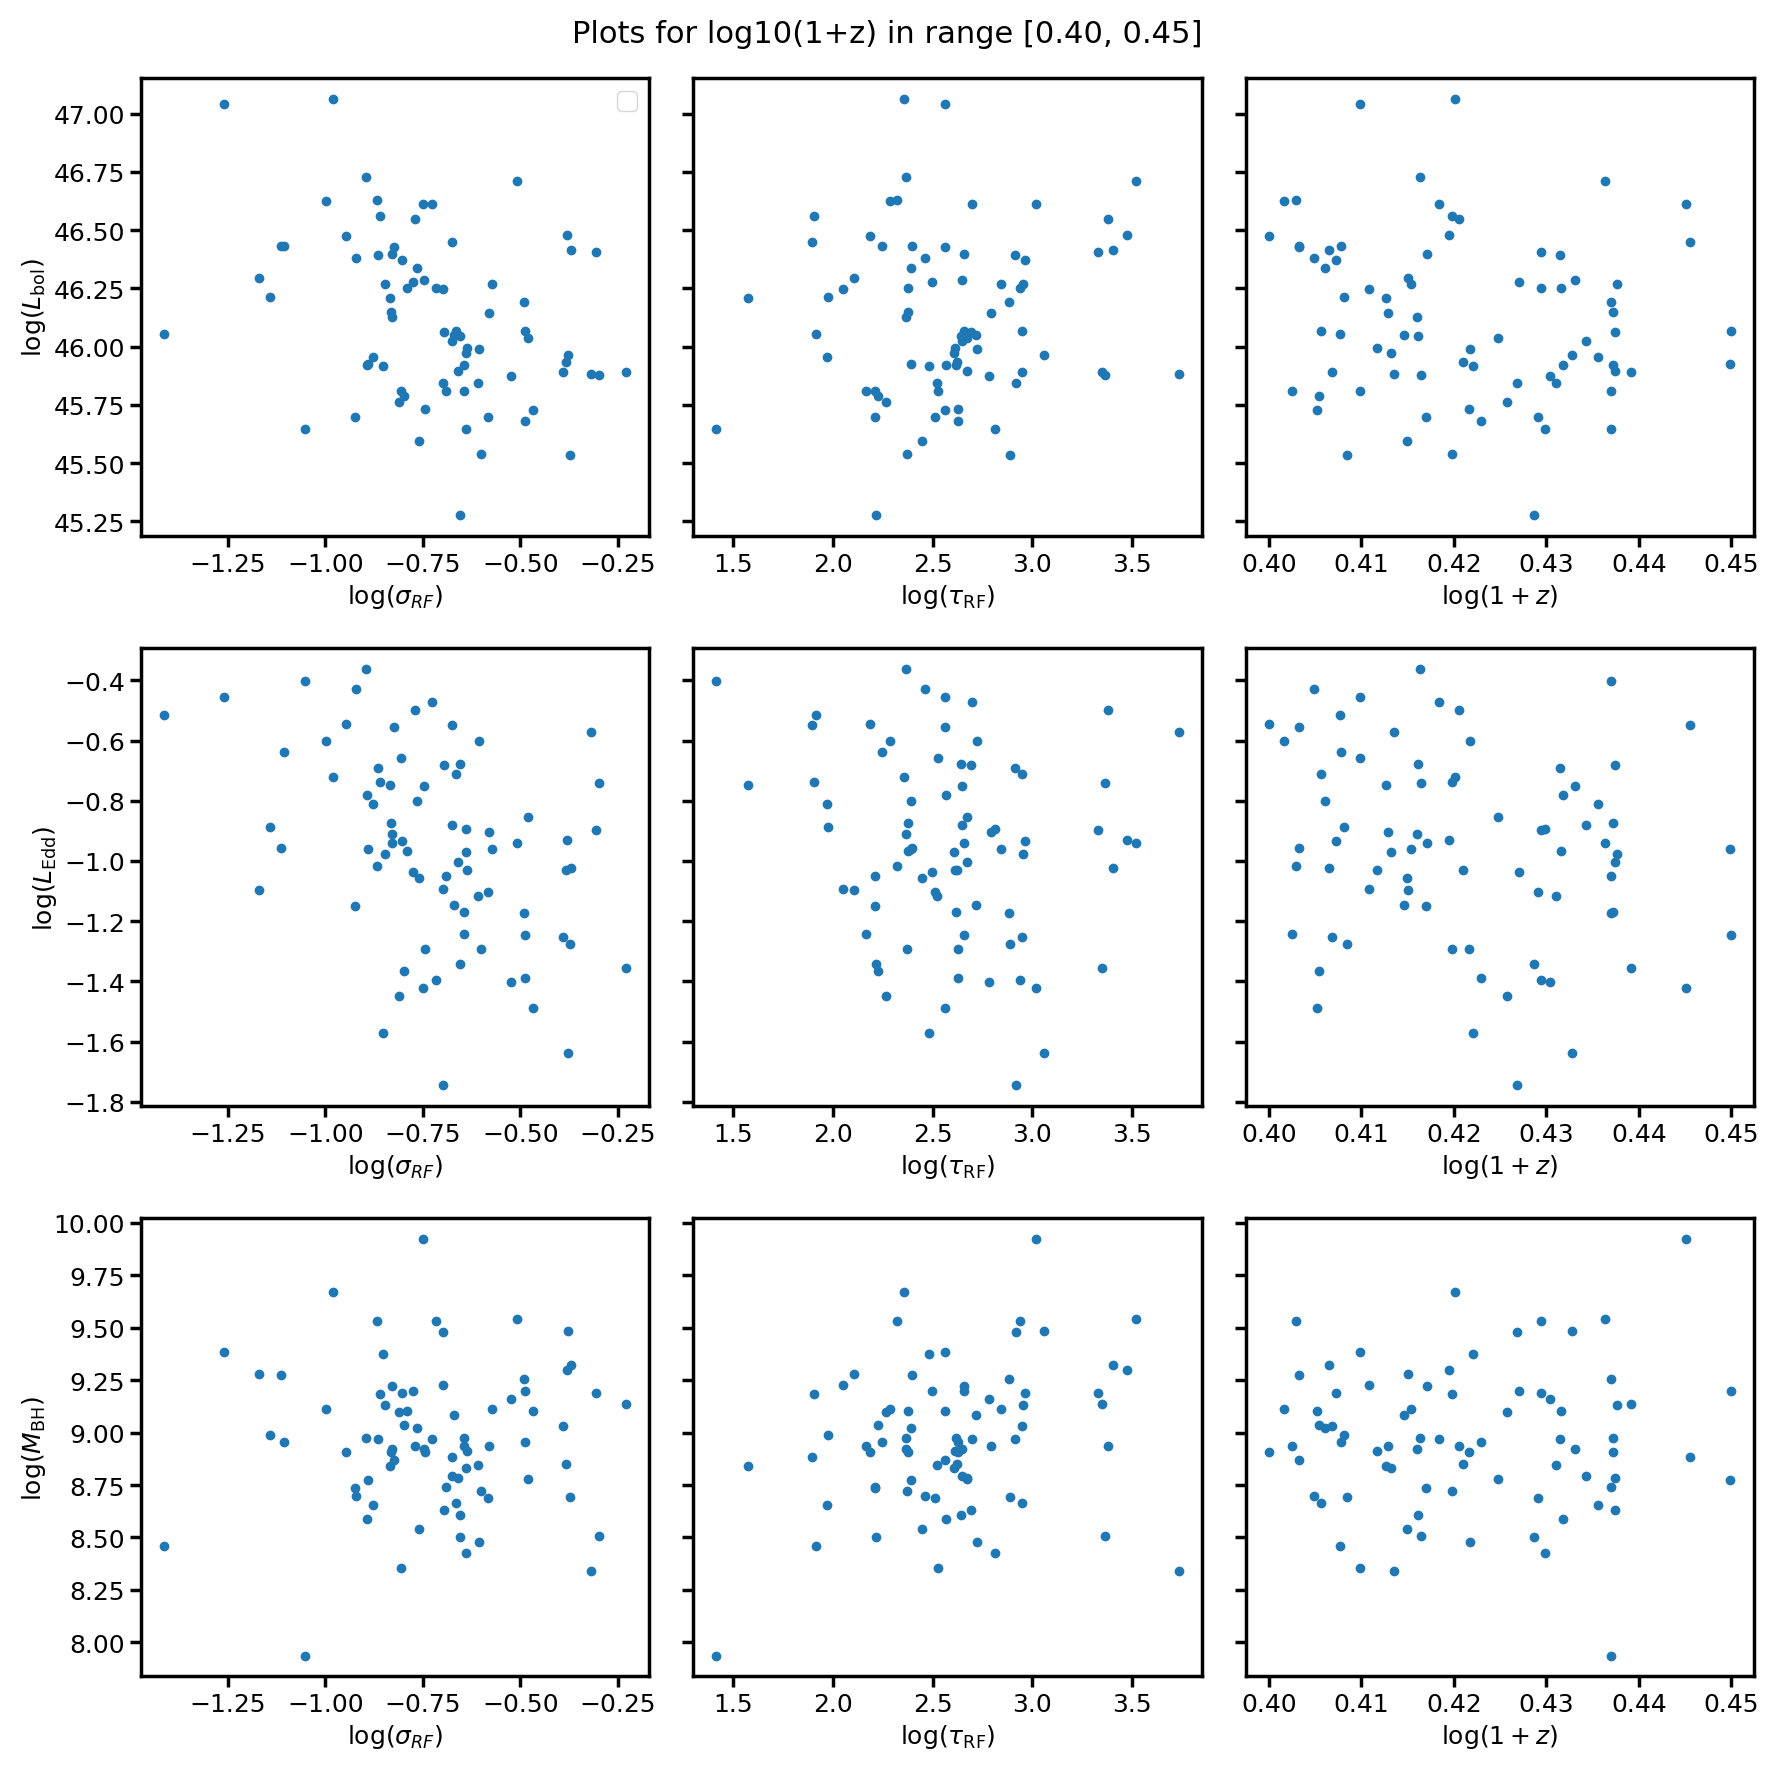

Plotting for range: 0.45 to 0.50


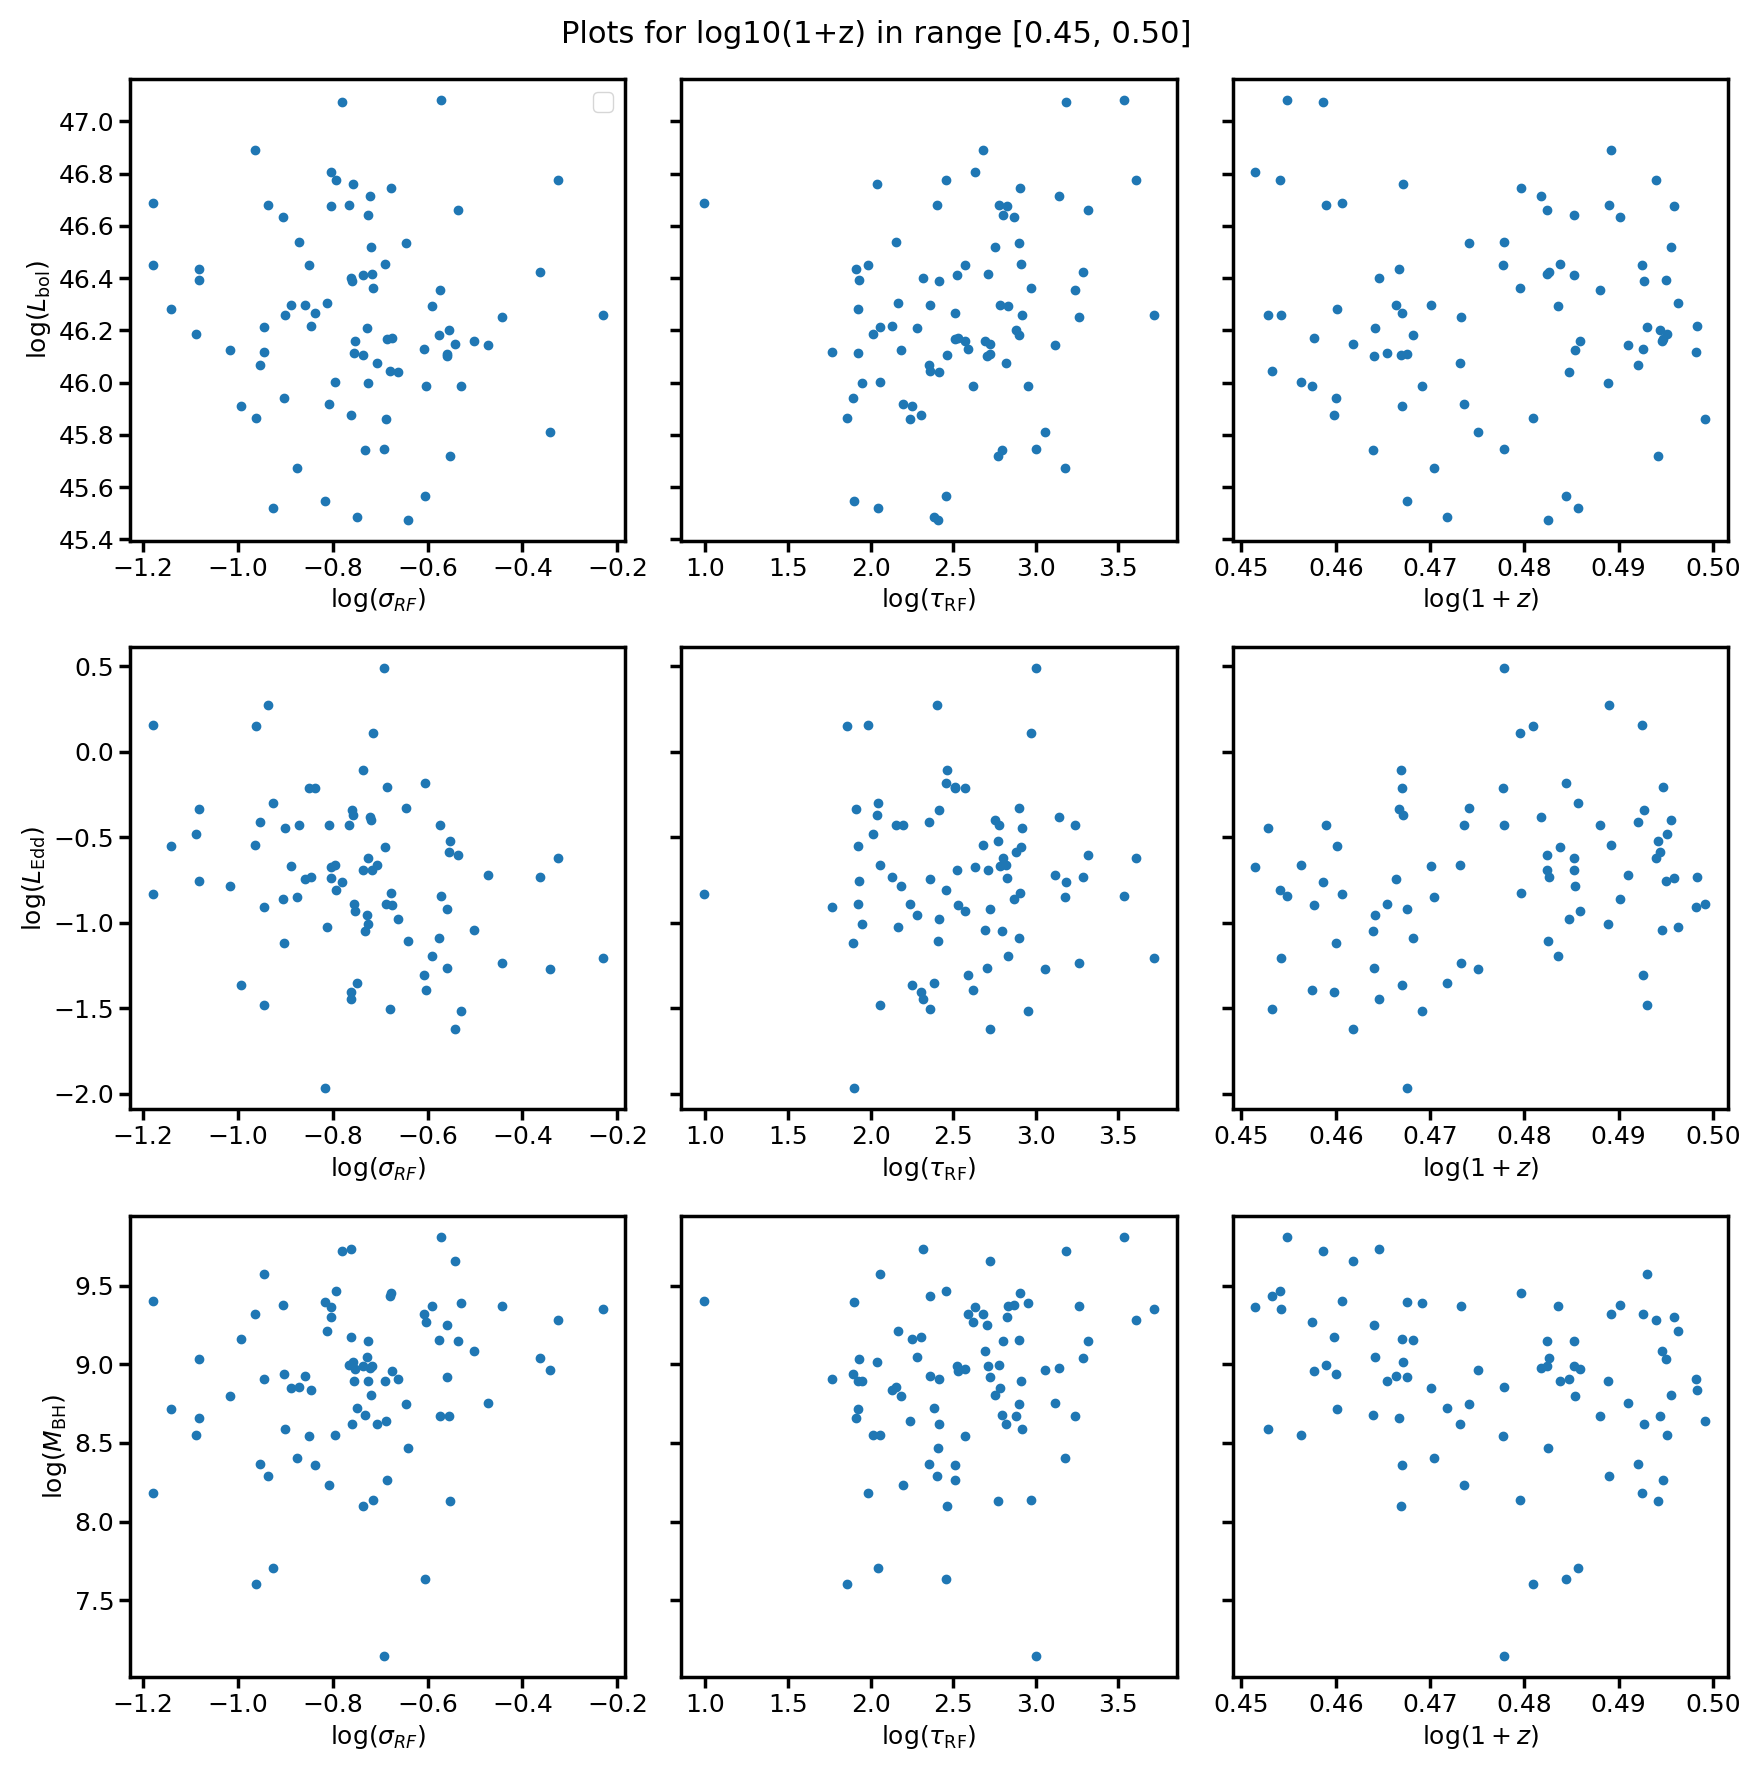

Plotting for range: 0.50 to 0.55


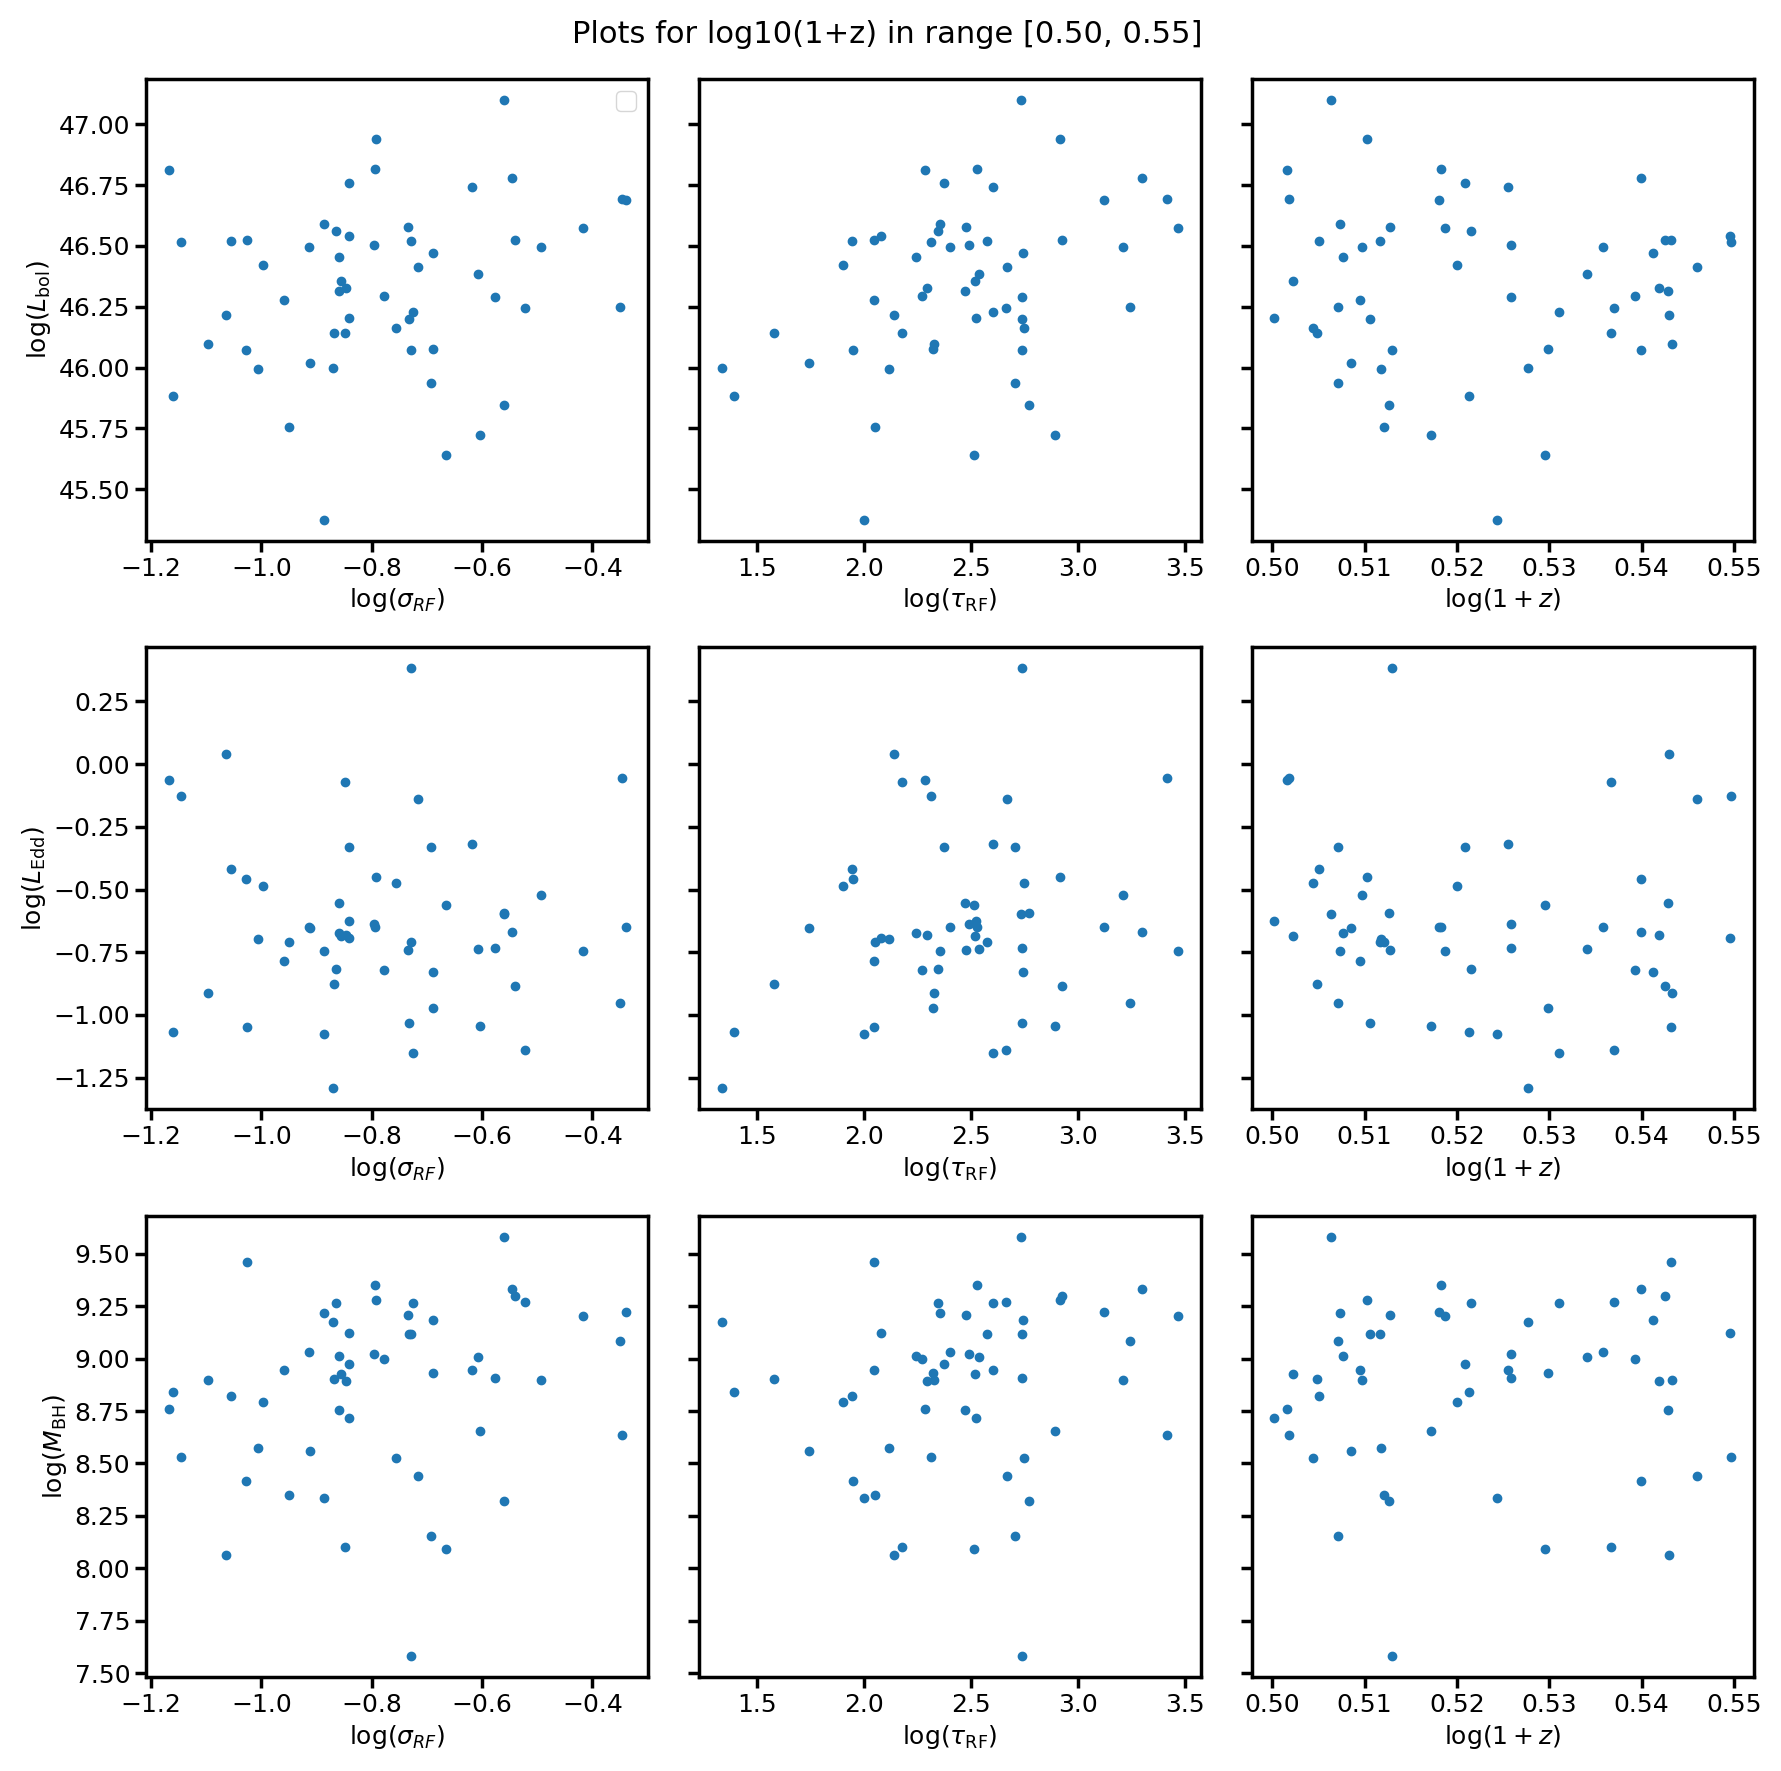

In [ ]:
def plot_selected_range(log10_z_range):
    # Filter the dataframe based on the provided range of np.log10(1+z)
    filtered_df = df[(np.log10(1 + df['z']) >= log10_z_range[0]) & (np.log10(1 + df['z']) <= log10_z_range[1])]
    
    fig, axs = plt.subplots(3, 3, figsize=(3*6, 3*6), sharey='row')
    # Add the bin range to the title
    fig.suptitle(f"Plots for log10(1+z) in range [{log10_z_range[0]:.2f}, {log10_z_range[1]:.2f}]")
    # First row
    ax = axs[0, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
    ax.legend()

    ax = axs[0, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[0, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(1+z)$")

    # Second row
    ax = axs[1, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(L_\mathrm{Edd})$")

    ax = axs[1, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[1, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(1+z)$")

    # Third row
    ax = axs[2, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(M_\mathrm{BH})$")

    ax = axs[2, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[2, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(1+z)$")

    plt.tight_layout()
    plt.show()
    plt.close()

# Define bins for np.log10(1+z)
bins = np.arange(0, np.log10(1 + df['z'].max()), 0.05)


# Call plot_selected_range for each bin
for i in range(len(bins) - 1):
    print(f"Plotting for range: {bins[i]:.2f} to {bins[i+1]:.2f}")
    plot_selected_range((bins[i], bins[i+1]))